# Assignment 3: Retrieval-Augmented Generation for Kubernetes Security Hardening

## Abstract

This notebook investigates whether a small, source-grounded Retrieval-Augmented Generation (RAG) pipeline can provide reliable **Kubernetes security hardening** guidance. A fixed local knowledge base was created by collecting and snapshotting trusted Kubernetes and cybersecurity web sources, then cleaning, chunking, and embedding them into a corpus of **2,093 chunks**. That corpus was used to evaluate **five systems** across **100 practitioner-style benchmark questions** using semantic similarity metrics, **proxy-based RAGAS evaluation**, a manual audit, and a structured failure taxonomy.

The strongest systems were close on the automated metrics, so the final ranking could not be justified by semantic similarity alone. `V2` and `V1` were nearly tied on the **core composite** (**0.6724** for `V2` versus **0.6727** for `V1`), while `V2` achieved the strongest context relevance overall. However, the decisive evidence came from the trustworthiness-focused evaluation. In the audited **100-output manual sample** (`20` cases per system), `V2` achieved a **manual quality score of 3.75**, an **unsupported-claim rate of 0.00**, and the highest **no-failure rate of 60%**. BERTScore was also closely matched between `V2` and `V1` (both about **0.6124**), reinforcing the conclusion that the strongest systems were tightly clustered and that the final choice needed to be made on broader evidence. Taken together, these results indicate that `V2` with `Gemma-2-2B-IT` was the most balanced final configuration, combining competitive automated performance with stronger practical reliability.




## 1. Introduction

This notebook presents the design, implementation, and evaluation of a domain-specific Retrieval-Augmented Generation (RAG) system for **Kubernetes security hardening**. The project addresses a practical cybersecurity question: can retrieval improvements help a compact open-source language model produce more useful, better grounded, and more trustworthy security guidance for practitioner-style operational questions? The motivation is consistent with recent RAG work showing that external retrieval is useful when models need current or specialised knowledge, but that grounding quality and evaluation design remain critical [1], [2]. In cybersecurity settings, this issue is even more important because plausible but weakly grounded answers can turn into unsafe operational advice [3], [4].

The notebook is organised as a compact research workflow rather than a code dump. **Phase 1** constructs the retrieval corpus by collecting and snapshotting trusted Kubernetes and cybersecurity sources, cleaning and chunking their contents, generating embeddings, and storing the resulting vectors in Chroma. **Phase 2** benchmarks multiple dense-family retrieval strategies and generator settings, then evaluates them through automated semantic metrics, proxy-based RAGAS evaluation, manual scoring, failure taxonomy, and qualitative deep-dive analysis. This structure keeps the system reproducible while avoiding the instability that can come with query-time live web retrieval [1].

**Study scope**
- Corpus: trusted Kubernetes and cybersecurity guidance sources
- Corpus scale: `2,093` embedded chunks
- Queries: `100` practitioner-style benchmark questions
- Main systems: `V1`, `V2`, `V3` with `Gemma-2-2B-IT`
- Model comparison: `QW_V1`, `QW_V3` with `Qwen2.5-3B-Instruct`
- Evaluation layers: BERTScore, proxy-based RAGAS evaluation, manual scoring, failure taxonomy, and deep dives




## 2. Literature Review

This notebook sits between general RAG work and more security-specific RAG systems. The four papers below are useful because each one helps explain a different part of my design: source collection, evaluation, validation, and robustness.

**Web-grounded RAG from scraped sources.** Kanataria et al. [1] build a general RAG assistant using web scraping, preprocessing, FAISS retrieval, and LLM generation. They test Mistral, Gemini-Pro, and Llama 3.1 with RAGAS-style metrics and report Llama 3.1 as the best model with `86.67%` overall accuracy [1]. This paper is useful because it shows how scraped web content can support question answering. At the same time, it also shows a pattern that appears in my notebook: strong context-related scores do not always mean strong answer correctness. I use [1] mainly to justify collecting trusted web sources, but I choose to freeze the corpus into a local snapshot because reproducibility matters more here than live updates.

**RAG evaluation and metric design.** Es et al. [2] introduce RAGAS as a reference-free evaluation framework that separates **faithfulness**, **answer relevance**, and **context relevance**. That separation is very important for this notebook. A system can retrieve relevant text but still give a weak answer, and an answer can sound strong while still being poorly grounded. Their paper also reports that faithfulness and answer relevance are closer to human judgment than several baselines, while context relevance is harder to evaluate [2]. Another useful idea from [2] is that structured JSON outputs make repeated judge runs more consistent. I follow the same evaluation logic here, but I use **proxy-based RAGAS evaluation** for the large comparison because the API-based judge workflow was not stable enough to be the final result layer.

**Cybersecurity education with explicit grounding and validation.** Zhao et al. [3] propose CyberBOT, a cybersecurity education assistant that combines an intent interpreter, top-3 FAISS retrieval, Llama-based generation, and an ontology verifier. Their backend uses `512`-token chunks, BAAI `bge-large-1.5` embeddings, and a domain-specific ontology to reject weak or unsafe answers [3]. This paper is important for two reasons. First, it treats trustworthiness as part of the system design, not only as something checked at the end. Second, it goes beyond offline metrics by deploying the system to more than `100` students and running a quasi-experiment with `77` graduate students. In their lab evaluation, CyberBOT reports an average `0.933` BERTScore and `0.994` context recall [3]. My notebook is much simpler than CyberBOT, but it is trying to answer the same basic question: how do we keep a domain RAG assistant useful **and** trustworthy?

**Agentic and specialist-oriented cybersecurity RAG.** Blefari et al. [4] present CyberRAG, an agentic pipeline for cyber-attack classification and reporting. Their design is more complex than mine because it uses specialized attack-family classifiers, an LLM controller, and iterative retrieval-and-reason passes rather than a single retrieval step. This setup lifts final classification accuracy from `84.75%` without RAG to `94.92%` with RAG, while generated explanations reach `0.94` BERTScore and `4.9/5` GPT-4 judge scores [4]. These results are not directly comparable to my notebook because the task is attack classification and reporting rather than open-ended hardening QA. Even so, the paper is very relevant because it shows what extra performance can come from adding modular validation, robustness testing, and multi-stage reasoning in a high-risk domain.

Taken together, these papers give me a clear design space. From [1], I take the idea of building a useful assistant from collected web sources, but I keep the corpus fixed and auditable. From [2], I take the idea that retrieval focus and answer quality should be evaluated separately. From [3], I take the lesson that validation layers and user-facing evaluation matter. From [4], I take the lesson that extra retrieval or specialist reasoning can be worth the added complexity in cybersecurity settings. My notebook stays on the simpler end of this space, which is why the final decision depends so much on manual trustworthiness analysis.


## 3. Research Questions and Study Design

**RQ1. Retrieval effectiveness.** Does improved dense retrieval with diversification (`V2`) outperform the plain dense top-3 baseline (`V1`)?  
Working hypothesis: `V2` should improve retrieval focus and context diversity without weakening answer quality.

**RQ2. Intent-aware retrieval.** Does intent-enriched retrieval (`V3`) help harder or more multi-step practitioner questions more than standard dense retrieval?  
Working hypothesis: `V3` may improve some advanced questions, but may also trade off specificity or stability.

**RQ3. Model sensitivity.** How sensitive are the main conclusions to the choice of generator when retrieval is held constant?  
Working hypothesis: replacing Gemma with Qwen on matched retrieval variants (`QW_V1`, `QW_V3`) will reveal whether observed performance differences are driven more by retrieval strategy or by model choice.

**RQ4. Trustworthiness.** What trustworthiness trade-offs appear across retrieval complexity and model choice?  
Working hypothesis: some systems may appear strong on semantic similarity metrics while still producing unsupported, weakly grounded, or less actionable guidance.

**Systems compared in the final notebook**
- `V1`: baseline dense top-3 retrieval
- `V2`: dense retrieval with diversification / improved reranking
- `V3`: intent-enriched dense retrieval
- `QW_V1`: Qwen comparison using `V1` retrieval
- `QW_V3`: Qwen comparison using `V3` retrieval

**Literature and evaluation mapping**
- **RAGAS** motivates the core evaluation dimensions: context relevance, answer relevance, and faithfulness.
- **CyberBOT** motivates curated cybersecurity corpora and trustworthiness-oriented analysis.
- **CyberRAG** motivates retrieval-strategy comparison and cybersecurity-focused RAG evaluation.
- Because API-judge RAGAS was operationally unstable in this environment, the final notebook uses a clearly labelled **proxy-based RAGAS evaluation** for broad automated comparison, then triangulates those results with manual scoring and failure analysis.



## 4. Setup and Pipeline Overview

This section explains how the notebook is prepared before the main experiments are run. It has two purposes. First, it gives a visual summary of the overall RAG workflow. Second, it shows how the Colab environment and project helper modules are used so the notebook can run in a controlled and reproducible way.

At a high level, the notebook follows a simple pattern: the environment is pinned, Google Drive is mounted, project paths are initialised, and then reusable helper modules from `src/` are called instead of rewriting the full pipeline logic inside notebook cells. This keeps the notebook readable while still making the experimental steps explicit.




### 4.1 End-to-End Pipeline Figure

*Figure 1 summarises the complete RAG workflow. Trusted source documents are ingested into a reusable vector knowledge base, while benchmark queries feed the retrieval and generation stages used for system comparison. The benchmark questions conceptually belong to the evaluation pipeline rather than to corpus ingestion.*




### 3.1 End-to-End Pipeline Figure

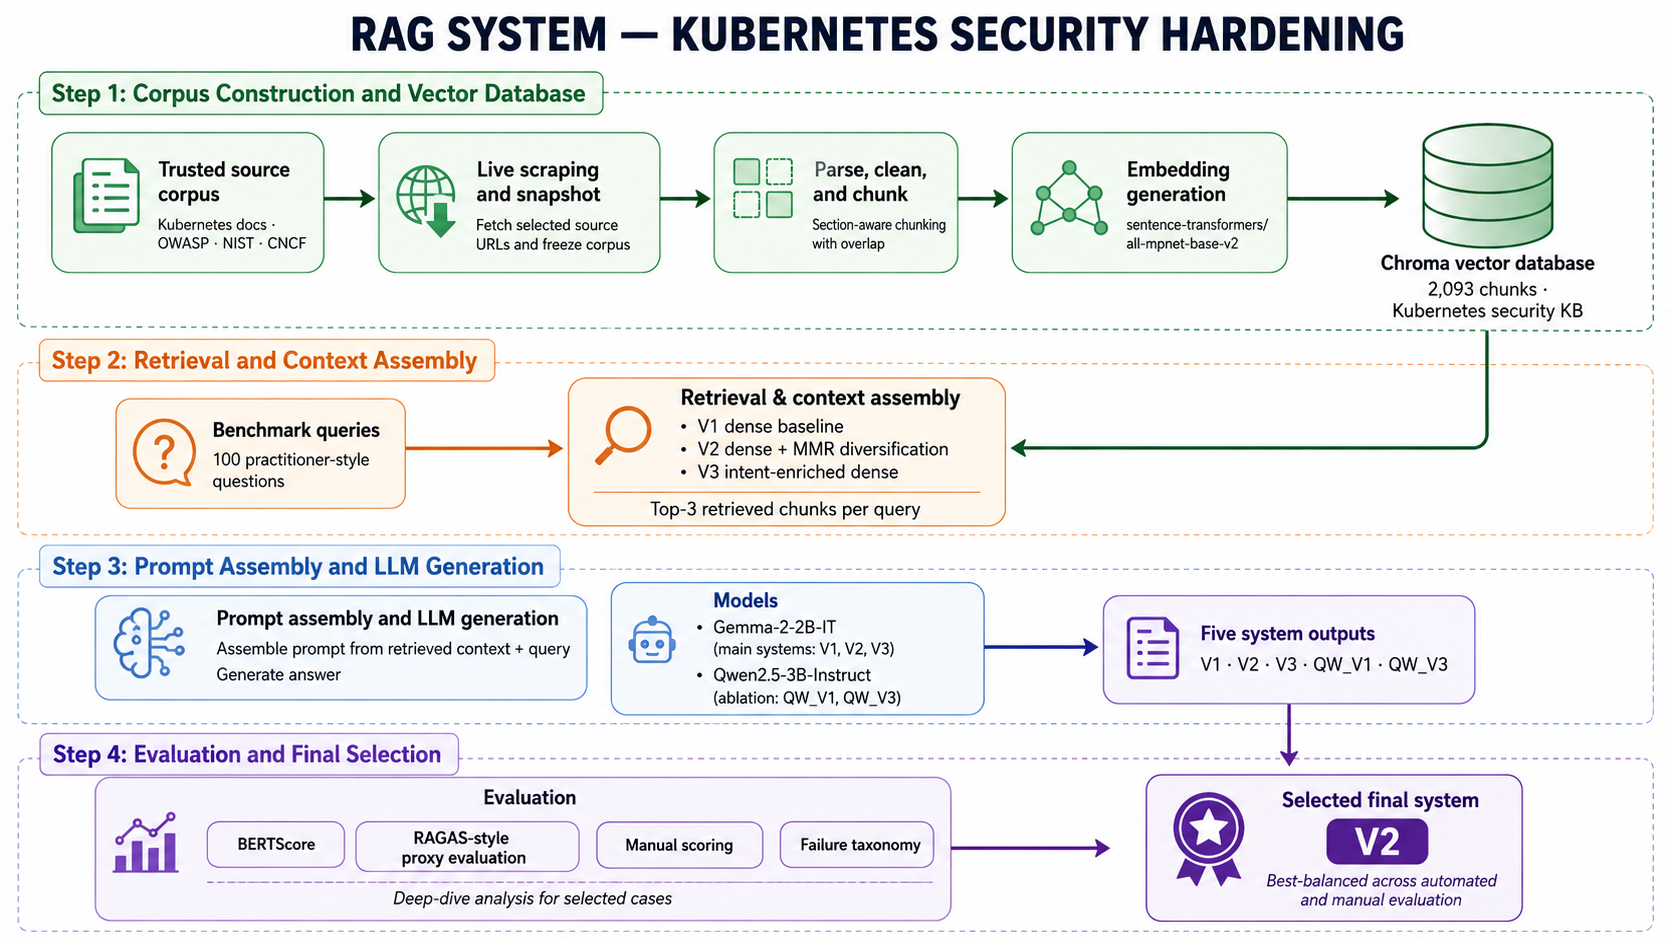

In [21]:
from pathlib import Path
import os
import sys
from IPython.display import Image, display

pipeline_candidates = []
env_root = os.environ.get('A3_PROJECT_ROOT')
if env_root:
    pipeline_candidates.append(Path(env_root).expanduser() / 'output' / 'figures' / 'rag_pipeline_final.png')

base_candidates = [Path.cwd(), Path.cwd().parent]
for base in base_candidates:
    pipeline_candidates.extend([
        base / 'output' / 'figures' / 'rag_pipeline_final.png',
        base / 'a1974524_a3' / 'output' / 'figures' / 'rag_pipeline_final.png',
        base / 'a1974524_a3 2' / 'output' / 'figures' / 'rag_pipeline_final.png',
        base / 'Advance-AI-Assign-3' / 'a1974524_a3' / 'output' / 'figures' / 'rag_pipeline_final.png',
    ])

if 'google.colab' in sys.modules:
    drive_parent = Path('/content/drive/MyDrive/Advance-AI-Assign-3')
    for name in ['a1974524_a3', 'a1974524_a3 2']:
        pipeline_candidates.append(drive_parent / name / 'output' / 'figures' / 'rag_pipeline_final.png')

seen = set()
unique_candidates = []
for path in pipeline_candidates:
    key = str(path)
    if key not in seen:
        seen.add(key)
        unique_candidates.append(path)

pipeline_img = next((path for path in unique_candidates if path.exists()), None)
if pipeline_img is None:
    raise FileNotFoundError('Could not find rag_pipeline_final.png in the expected output/figures locations.')

display(Image(filename=str(pipeline_img), width=1400))


*Interpretation.* This figure gives me the full workflow in one place. I use it as the reference map for the rest of the notebook: first I build a fixed knowledge base, then I compare retrieval and generation variants on the same benchmark, and finally I decide between systems using both automated and trustworthiness-focused evidence.



### 4.2 Runtime Setup

Before the main pipeline is executed, the notebook standardises the runtime environment. The setup cells pin the main packages used for scraping, parsing, embedding, retrieval, evaluation, and visualisation so that reruns in Colab are less likely to break because of version drift. The notebook also mounts Google Drive when needed, reads any available API tokens from Colab secrets, and resolves the project root used by the later cells.

The important reproducibility point is that later cells do **not** need fresh hard-coded path edits. The setup logic first checks the `A3_PROJECT_ROOT` environment variable, then nearby local folders, and finally the default Colab Drive location. In simple terms, the notebook should run from either a synced Drive copy or a local folder without rewriting every later path block.

This setup is intentionally separated from the experiment logic. In other words, these cells do not perform retrieval or generation themselves; they prepare a stable environment so that the later phases can call the project code in a reproducible way.


In [1]:
import importlib.metadata as importlib_metadata
import subprocess
import sys
from packaging.version import Version

PINNED_PACKAGES = [
    'numpy==1.26.4',
    'scipy==1.13.1',
    'pandas==2.2.2',
    'requests==2.32.3',
    'beautifulsoup4==4.12.3',
    'lxml==5.2.2',
    'matplotlib==3.9.0',
    'pypdf==4.2.0',
    'sentence-transformers==3.0.1',
    'transformers==4.46.3',
    'tokenizers==0.20.3',
    'huggingface-hub==0.36.2',
    'chromadb==0.5.23',
    'accelerate==1.13.0',
    'bert-score==0.3.13',
    'ragas==0.4.3',
    'sentencepiece',
]

EXPECTED_PREFIX = {
    'numpy': '1.26.4',
    'scipy': '1.13.',
    'pandas': '2.2.2',
    'requests': '2.32.',
    'beautifulsoup4': '4.12.',
    'lxml': '5.2.',
    'matplotlib': '3.9.',
    'pypdf': '4.2.',
    'sentence-transformers': '3.0.',
    'transformers': '4.46.',
    'tokenizers': '0.20.',
    'huggingface-hub': '0.36.',
    'chromadb': '0.5.',
    'accelerate': '1.13.',
    'bert-score': '0.3.13',
    'ragas': '0.4.',
}

MINIMUM_VERSION = {
    'openai': '1.0.0',
    'datasets': '4.0.0',
}

def get_installed_version(package_name: str):
    try:
        return importlib_metadata.version(package_name)
    except importlib_metadata.PackageNotFoundError:
        return None

current_versions = {name: get_installed_version(name) for name in EXPECTED_PREFIX}
minimum_versions = {name: get_installed_version(name) for name in MINIMUM_VERSION}

needs_install = any(
    current_versions[name] is None or not str(current_versions[name]).startswith(EXPECTED_PREFIX[name])
    for name in EXPECTED_PREFIX
) or any(
    minimum_versions[name] is None or Version(str(minimum_versions[name])) < Version(MINIMUM_VERSION[name])
    for name in MINIMUM_VERSION
)

print('Current package versions:')
for name in EXPECTED_PREFIX:
    print(f'- {name}: installed={current_versions[name]} expected_prefix={EXPECTED_PREFIX[name]}')
for name in MINIMUM_VERSION:
    print(f'- {name}: installed={minimum_versions[name]} minimum={MINIMUM_VERSION[name]}')

if needs_install:
    print('\nInstalling pinned Colab packages...')
    subprocess.check_call([
        sys.executable,
        '-m',
        'pip',
        'install',
        '--upgrade',
        '--force-reinstall',
        '--no-cache-dir',
        *PINNED_PACKAGES,
        'openai>=1.0.0',
        'datasets>=4.0.0',
    ])
    subprocess.call([
        sys.executable,
        '-m',
        'pip',
        'uninstall',
        '-y',
        'torchvision',
        'tensorflow',
        'tensorflow-cpu',
        'tf-keras',
        'keras',
        'bitsandbytes',
    ])
    raise SystemExit('Pinned packages installed. Restart the runtime, then run the notebook again from the top.')
else:
    print('\nPinned package versions are already active.')
    try:
        subprocess.call([
            sys.executable,
            '-m',
            'pip',
            'uninstall',
            '-y',
            'torchvision',
            'tensorflow',
            'tensorflow-cpu',
            'tf-keras',
            'keras',
            'bitsandbytes',
        ])
    except Exception:
        pass

Current package versions:
- numpy: installed=1.26.4 expected_prefix=1.26.4
- scipy: installed=1.13.1 expected_prefix=1.13.
- pandas: installed=2.2.2 expected_prefix=2.2.2
- requests: installed=2.32.3 expected_prefix=2.32.
- beautifulsoup4: installed=4.12.3 expected_prefix=4.12.
- lxml: installed=5.2.2 expected_prefix=5.2.
- matplotlib: installed=3.9.0 expected_prefix=3.9.
- pypdf: installed=4.2.0 expected_prefix=4.2.
- sentence-transformers: installed=3.0.1 expected_prefix=3.0.
- transformers: installed=4.46.3 expected_prefix=4.46.
- tokenizers: installed=0.20.3 expected_prefix=0.20.
- huggingface-hub: installed=0.36.2 expected_prefix=0.36.
- chromadb: installed=0.5.23 expected_prefix=0.5.
- accelerate: installed=1.13.0 expected_prefix=1.13.
- bert-score: installed=0.3.13 expected_prefix=0.3.13
- ragas: installed=0.4.3 expected_prefix=0.4.
- openai: installed=2.38.0 minimum=1.0.0
- datasets: installed=4.8.5 minimum=4.0.0

Pinned package versions are already active.


In [2]:
import json
import os
import sys
from pathlib import Path

os.environ.setdefault('USE_TF', '0')
os.environ.setdefault('TRANSFORMERS_NO_TF', '1')
os.environ.setdefault('USE_FLAX', '0')
os.environ.setdefault('TRANSFORMERS_NO_FLAX', '1')
os.environ.setdefault('HF_HUB_DISABLE_TELEMETRY', '1')
os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')

IN_COLAB = 'google.colab' in sys.modules
HF_TOKEN_PRESENT = False
OPENAI_KEY_PRESENT = False

if IN_COLAB:
    from google.colab import drive, userdata

    drive.mount('/content/drive')
    try:
        hf_token = userdata.get('HF_TOKEN')
    except Exception:
        hf_token = None
    if hf_token:
        os.environ['HF_TOKEN'] = hf_token
        HF_TOKEN_PRESENT = True
        try:
            from huggingface_hub import login
            login(token=hf_token, add_to_git_credential=False)
        except Exception as exc:
            print('HF login warning:', exc)

    try:
        openai_api_key = userdata.get('OPENAI_API_KEY')
    except Exception:
        openai_api_key = None
    if openai_api_key:
        os.environ['OPENAI_API_KEY'] = openai_api_key
        OPENAI_KEY_PRESENT = True
else:
    HF_TOKEN_PRESENT = bool(os.environ.get('HF_TOKEN'))
    OPENAI_KEY_PRESENT = bool(os.environ.get('OPENAI_API_KEY'))

bootstrap_candidates = []
env_root = os.environ.get('A3_PROJECT_ROOT')
if env_root:
    bootstrap_candidates.append(Path(env_root).expanduser())

base_candidates = [Path.cwd(), Path.cwd().parent]
for base in base_candidates:
    bootstrap_candidates.extend([
        base,
        base / 'a1974524_a3',
        base / 'a1974524_a3 2',
        base / 'Advance-AI-Assign-3' / 'a1974524_a3',
    ])

if IN_COLAB:
    drive_parent = Path('/content/drive/MyDrive/Advance-AI-Assign-3')
    for name in ['a1974524_a3', 'a1974524_a3 2']:
        bootstrap_candidates.append(drive_parent / name)

seen = set()
for candidate in bootstrap_candidates:
    key = str(candidate)
    if key in seen:
        continue
    seen.add(key)
    if (candidate / 'src').exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

from src.project_paths import PROJECT_ROOT_ENV, build_notebook_paths, resolve_project_root

PROJECT_ROOT = resolve_project_root()
os.environ.setdefault(PROJECT_ROOT_ENV, str(PROJECT_ROOT))
NOTEBOOK_PATHS = build_notebook_paths(PROJECT_ROOT)
OUTPUT_ROOT = NOTEBOOK_PATHS.output_root
PHASE2_OUTPUT_DIR = NOTEBOOK_PATHS.phase2_dir
PHASE2_TABLES_DIR = NOTEBOOK_PATHS.phase2_tables_dir

for folder_name in ['data', 'output', 'report', 'video']:
    (PROJECT_ROOT / folder_name).mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('IN_COLAB =', IN_COLAB)
print('PROJECT_ROOT =', PROJECT_ROOT)
print('src exists =', (PROJECT_ROOT / 'src').exists())
print('HF_TOKEN present =', HF_TOKEN_PRESENT)
print('OPENAI_API_KEY present =', OPENAI_KEY_PRESENT)
print('A3_PROJECT_ROOT =', os.environ.get(PROJECT_ROOT_ENV))


Mounted at /content/drive


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


IN_COLAB = True
PROJECT_ROOT = /content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3
src exists = True
HF_TOKEN present = True
OPENAI_API_KEY present = True


### 4.3 Helper Modules Used in the Notebook

Rather than placing the entire implementation inside notebook cells, the notebook calls small helper modules from `src/`. This makes the report easier to read and also keeps the implementation reusable outside the notebook.

**Main helper files**
- `src/project_paths.py`: project-root resolution and shared output-path helpers for local and Colab runs.
- `src/phase1_pipeline.py`: path management, directory creation, source ingestion, chunking, embedding, and environment reporting for Phase 1.
- `src/phase2/artifacts.py`: loading and saving intermediate phase outputs in a consistent format.
- `src/phase2/benchmark_content.py`: reviewed benchmark construction and topic/difficulty metadata.
- `src/phase2/queries.py`: benchmark query preparation and query-set handling.
- `src/phase2/retrieval.py`: retrieval execution for the different system variants such as `V1`, `V2`, and `V3`.
- `src/phase2/generation.py`: prompt construction, retrieved-context formatting, answer generation, and citation handling.
- `src/phase2/evaluation.py`: automated evaluation utilities such as BERTScore and other main scoring functions.
- `src/phase2/analysis.py`: aggregation and comparison helpers for system-level analysis.
- `src/phase2/extended_evaluation.py`: additional evaluation routines, including later-stage proxy and audit processing.

In simple terms, the notebook is the report layer, while the helper files provide the reusable implementation layer. The code cells below mainly import these modules and then call them in sequence during the later phases.


In [3]:
import json
import logging
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src import phase1_pipeline as p1
from src.phase2 import artifacts as p2_artifacts
from src.phase2 import benchmark_content as p2_benchmark
from src.phase2 import queries as p2_queries
from src.phase2 import retrieval as p2_retrieval
from src.phase2 import generation as p2_generation
from src.phase2 import evaluation as p2_eval
from src.phase2 import analysis as p2_analysis
from src.phase2 import extended_evaluation as p2_ext_eval

warnings.filterwarnings(
    'ignore',
    message='.*HF_TOKEN.*does not exist in your Colab secrets.*',
    category=UserWarning,
)
logging.getLogger('chromadb.telemetry.product.posthog').setLevel(logging.CRITICAL)
print('Project imports succeeded.')


/usr/local/lib/python3.12/dist-packages/pypdf/_crypt_providers/_cryptography.py:32: CryptographyDeprecationWarning: ARC4 has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.ARC4 and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  from cryptography.hazmat.primitives.ciphers.algorithms import AES, ARC4


Project imports succeeded.


## 5. Phase 1: Knowledge Base Construction

Phase 1 builds the knowledge base used by the RAG system. The goal is not just to collect text, but to create a **traceable, citation-friendly retrieval corpus** suitable for cybersecurity guidance generation. The corpus is assembled from trusted Kubernetes documentation, white papers, cheat sheets, standards-oriented material, and practitioner resources.

Source acquisition is based on **download-and-snapshot ingestion** rather than live web retrieval during answering. In practice, the helper pipeline fetches the selected source pages and files, stores local copies, and then processes those snapshots into chunks and embeddings. This means the answering stage always retrieves from a frozen local corpus rather than from changing web content at query time.

The update mechanism is therefore simple but explicit: if the trusted sources change, the ingestion pipeline can be rerun to refresh the local snapshots, rebuild the chunks, and regenerate the vector store. This design improves reproducibility for the experiments, but it also creates a maintenance requirement because the corpus only stays current when the source-ingestion step is repeated.

This phase performs four steps:
1. fetch and snapshot the selected source set;
2. parse the raw material into structured documents;
3. chunk the documents with overlap for retrieval;
4. embed the chunks and build a Chroma vector store.

The chunking configuration is intentionally conservative: the pipeline uses a target chunk size of about **160 words**, a minimum size of **40 words**, and an overlap of **40 words** between neighbouring chunks. I keep this overlap because security guidance often spans sentence boundaries. Without overlap, a definition, caveat, or mitigation step can be split across two chunks and become harder to retrieve as a complete idea. The overlap therefore trades a small amount of redundancy for better semantic continuity during retrieval.

The outputs of Phase 1 provide the fixed evidence base for all later comparisons. This is important for internal validity: retrieval and generation variants should be compared against the same frozen corpus rather than against moving source content.




In [ ]:
paths = p1.build_paths(PROJECT_ROOT)
p1.ensure_directories(paths)

output_root = PROJECT_ROOT / 'output'
figures_dir = output_root / 'figures'
tables_dir = output_root / 'tables'
for directory in [output_root, figures_dir, tables_dir]:
    directory.mkdir(parents=True, exist_ok=True)

PACKAGE_REPORT = [
    'requests',
    'beautifulsoup4',
    'lxml',
    'matplotlib',
    'pypdf',
    'pandas',
    'numpy',
    'sentence-transformers',
    'transformers',
    'tokenizers',
    'huggingface-hub',
    'chromadb',
    'accelerate',
    'bert-score',
    'ragas',
    'openai',
    'datasets',
]

environment_report = p1.collect_environment_report(PACKAGE_REPORT)
environment_report['in_colab'] = IN_COLAB
environment_report['project_root'] = str(PROJECT_ROOT)

topic_name = 'kubernetes_security_hardening'
chunk_method = 'section_aware_sentence_filtering_v3'
chunk_config = {
    'max_words': 160,
    'overlap_words': 40,
    'min_words': 40,
}
embedding_model_name = 'all-MiniLM-L6-v2'
embedding_batch_size = 32

print('Output root:', output_root)
print(json.dumps(environment_report, indent=2))


Output root: /content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/output
{
  "python_version": "3.12.13",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
  "packages": {
    "requests": "2.32.3",
    "beautifulsoup4": "4.12.3",
    "lxml": "5.2.2",
    "matplotlib": "3.9.0",
    "pypdf": "4.2.0",
    "pandas": "2.2.2",
    "numpy": "1.26.4",
    "sentence-transformers": "3.0.1",
    "transformers": "4.46.3",
    "tokenizers": "0.20.3",
    "huggingface-hub": "0.36.2",
    "chromadb": "0.5.23",
    "accelerate": "1.13.0",
    "bert-score": "0.3.13",
    "ragas": "0.4.3",
    "openai": "2.38.0",
    "datasets": "4.8.5"
  },
  "in_colab": true,
  "project_root": "/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3"
}


In [ ]:
selected_sources = p1.SOURCE_REGISTRY
selected_source_ids = [item['source_id'] for item in selected_sources]
source_overview_df = pd.DataFrame(
    [
        {
            'source_id': source['source_id'],
            'type': source['type'],
            'trust_level': source['trust_level'],
            'num_seed_urls': len(source['seed_urls']),
            'allowed_domains': ', '.join(source.get('allowed_domains', [])),
            'topic_tags': ', '.join(source.get('topic_tags', [])),
        }
        for source in selected_sources
    ]
).sort_values('source_id')
source_overview_df.to_csv(tables_dir / 'source_registry_overview.csv', index=False)
display(source_overview_df)


,source_id,type,trust_level,num_seed_urls,allowed_domains,topic_tags
7,aalto_k8s_security_thesis,pdf,trusted,1,aaltodoc.aalto.fi,"kubernetes, academic, security, thesis, hardening"
14,aks_security_docs,html,official,4,learn.microsoft.com,"kubernetes, aks, managed-kubernetes, security,..."
12,aws_eks_security_docs,html,official,5,docs.aws.amazon.com,"kubernetes, eks, managed-kubernetes, security,..."
6,cncf_cloud_native_security_whitepaper,pdf,trusted,1,tag-security.cncf.io,"kubernetes, cncf, cloud-native, whitepaper"
16,gatekeeper_policy_docs,html,trusted,3,open-policy-agent.github.io,"kubernetes, opa, gatekeeper, policy-as-code, a..."
13,gke_security_docs,html,official,3,"cloud.google.com, docs.cloud.google.com","kubernetes, gke, managed-kubernetes, security,..."
1,k8s_access_control_docs,html,official,8,kubernetes.io,"kubernetes, authentication, authorization, adm..."
3,k8s_cve_feed,json_feed,official,1,kubernetes.io,"kubernetes, cve, vulnerabilities"
2,k8s_operational_security_docs,html,official,4,kubernetes.io,"kubernetes, network-policy, encryption, auditi..."
0,k8s_security_docs,html,official,15,kubernetes.io,"kubernetes, hardening, cluster-security, workl..."


*Interpretation.* This source registry shows that the corpus is broad but still controlled. I am using **17 sources** in total, split across **8 official sources** and **9 trusted sources**. That balance is useful because most of the grounding still comes from official Kubernetes and cloud-provider material, while the trusted set widens coverage for hardening, policy, observability, and supporting practitioner guidance.


In [ ]:
snapshot_id = p1.make_snapshot_id()
raw_metadata_list = []
fetch_records = []
fetch_failures = []

for source in selected_sources:
    for url in source['seed_urls']:
        item_id = p1.url_to_slug(url)
        try:
            fetch_result = p1.fetch_url(
                url=url,
                allowed_domains=source['allowed_domains'],
                timeout=30,
            )
            raw_metadata = p1.save_raw_snapshot(
                raw_root=paths['raw'],
                source_id=source['source_id'],
                snapshot_id=snapshot_id,
                fetch_result=fetch_result,
                item_id=item_id,
            )
            raw_metadata_list.append(raw_metadata)
            fetch_records.append(
                {
                    'snapshot_id': snapshot_id,
                    'source_id': source['source_id'],
                    'source_type': source['type'],
                    'trust_level': source['trust_level'],
                    'item_id': raw_metadata['item_id'],
                    'requested_url': fetch_result['requested_url'],
                    'final_url': fetch_result['final_url'],
                    'status_code': fetch_result['status_code'],
                    'content_type': fetch_result['content_type'],
                    'byte_size': raw_metadata['byte_size'],
                    'sha256': raw_metadata['sha256'],
                    'local_body_path': raw_metadata['local_body_path'],
                    'metadata_path': raw_metadata['metadata_path'],
                }
            )
        except Exception as exc:
            fetch_failures.append(
                {
                    'snapshot_id': snapshot_id,
                    'source_id': source['source_id'],
                    'source_type': source['type'],
                    'requested_url': url,
                    'error_type': type(exc).__name__,
                    'error_message': str(exc),
                }
            )

fetch_summary_df = pd.DataFrame(fetch_records)
fetch_failures_df = pd.DataFrame(fetch_failures)
fetch_group_summary_df = (
    fetch_summary_df.groupby(['source_id', 'source_type', 'trust_level'], as_index=False)
    .agg(num_items=('item_id', 'count'), total_bytes=('byte_size', 'sum'))
    .sort_values(['source_id'])
)
fetch_group_summary_df.to_csv(tables_dir / 'fetch_summary_by_source.csv', index=False)
fetch_summary_df.to_csv(tables_dir / 'fetch_items_detailed.csv', index=False)
if not fetch_failures_df.empty:
    fetch_failures_df.to_csv(tables_dir / 'fetch_failures.csv', index=False)

print('Snapshot ID:', snapshot_id)
print('Fetched items:', len(fetch_summary_df))
print('Fetch failures:', len(fetch_failures_df))
display(fetch_group_summary_df)


Snapshot ID: 2026-05-27T192816Z
Fetched items: 56
Fetch failures: 0


,source_id,source_type,trust_level,num_items,total_bytes
0,aalto_k8s_security_thesis,pdf,trusted,1,1037935
1,aks_security_docs,html,official,4,259574
2,aws_eks_security_docs,html,official,5,229151
3,cncf_cloud_native_security_whitepaper,pdf,trusted,1,1545334
4,gatekeeper_policy_docs,html,trusted,3,100997
5,gke_security_docs,html,official,3,489527
6,k8s_access_control_docs,html,official,8,4427888
7,k8s_cve_feed,json_feed,official,1,271429
8,k8s_operational_security_docs,html,official,4,2136209
9,k8s_security_docs,html,official,15,7453347


*Interpretation.* The fetch summary is my first reproducibility checkpoint. In this run, the pipeline downloaded and snapshotted **56 source items** before any parsing or chunking happened. That matters because the later retrieval results come from a fixed local copy of the corpus rather than from changing web pages.

In [ ]:
documents = []
normalized_paths = {}
item_parse_rows = []

for source in selected_sources:
    source_raw_items = [item for item in raw_metadata_list if item['source_id'] == source['source_id']]
    source_documents = []

    for raw_metadata in source_raw_items:
        body_path = p1.Path(raw_metadata['local_body_path'])
        body_bytes = body_path.read_bytes()

        if source['type'] == 'html':
            encoding = raw_metadata.get('encoding') or 'utf-8'
            html_text = body_bytes.decode(encoding, errors='replace')
            parsed_documents = p1.parse_html_sections(
                html_text=html_text,
                source_id=source['source_id'],
                source_url=raw_metadata['url'],
                trust_level=source['trust_level'],
                topic_tags=source['topic_tags'],
                document_key=raw_metadata['item_id'],
            )
        elif source['type'] == 'pdf':
            parsed_documents = p1.parse_pdf_pages(
                pdf_bytes=body_bytes,
                source_id=source['source_id'],
                source_url=raw_metadata['url'],
                trust_level=source['trust_level'],
                topic_tags=source['topic_tags'],
                document_key=raw_metadata['item_id'],
            )
        elif source['type'] == 'json_feed':
            parsed_documents = p1.parse_kubernetes_cve_feed(
                feed_bytes=body_bytes,
                source_id=source['source_id'],
                source_url=raw_metadata['url'],
                trust_level=source['trust_level'],
                topic_tags=source['topic_tags'],
                document_key=raw_metadata['item_id'],
            )
        else:
            raise ValueError(f"Unsupported source type: {source['type']}")

        for document in parsed_documents:
            document['snapshot_id'] = snapshot_id

        item_parse_rows.append(
            {
                'source_id': source['source_id'],
                'item_id': raw_metadata['item_id'],
                'source_type': source['type'],
                'num_docs': len(parsed_documents),
                'local_body_path': raw_metadata['local_body_path'],
            }
        )
        source_documents.extend(parsed_documents)

    normalized_path = p1.save_normalized_documents(
        normalized_root=paths['normalized'],
        snapshot_id=snapshot_id,
        source_id=source['source_id'],
        documents=source_documents,
    )
    normalized_paths[source['source_id']] = str(normalized_path)
    documents.extend(source_documents)

item_parse_summary_df = pd.DataFrame(item_parse_rows)
docs_df = pd.DataFrame(documents)
if not docs_df.empty:
    docs_df['page_number_display'] = docs_df['page_number'].fillna('').astype(str).replace('nan', '')
    docs_df['section_path_text'] = docs_df['section_path'].apply(lambda parts: ' > '.join(parts) if isinstance(parts, list) else '')
    docs_df['char_count'] = docs_df['text'].str.len()

docs_summary_df = (
    docs_df.groupby(['source_id', 'doc_kind', 'trust_level'], as_index=False)
    .agg(num_docs=('doc_id', 'count'), median_chars=('char_count', 'median'))
    .sort_values(['num_docs', 'source_id'], ascending=[False, True])
)
docs_summary_df.to_csv(tables_dir / 'normalized_docs_by_source.csv', index=False)
item_parse_summary_df.to_csv(tables_dir / 'normalized_items_by_file.csv', index=False)

print('Normalized documents:', len(documents))
display(docs_summary_df.head(20))


Normalized documents: 1321


,source_id,doc_kind,trust_level,num_docs,median_chars
6,k8s_access_control_docs,guide_section,official,193,700.0
9,k8s_security_docs,guide_section,official,190,583.0
10,k8s_security_observability_book,pdf_page,trusted,177,2227.0
8,k8s_operational_security_docs,guide_section,official,96,594.0
2,aws_eks_security_docs,guide_section,official,92,627.5
7,k8s_cve_feed,cve_feed_item,official,90,2299.5
5,gke_security_docs,guide_section,official,79,531.0
13,owasp_k8s_cheatsheet,guide_section,trusted,68,647.5
1,aks_security_docs,guide_section,official,66,709.0
0,aalto_k8s_security_thesis,pdf_page,trusted,65,2109.0


*Interpretation.* After parsing, the raw files are converted into a shared document format. In practice, that produces **1,321 normalised documents** from a mixed source set that includes HTML pages, PDFs, and a JSON feed. I use this step to make sure later chunking and embedding are working over one consistent representation instead of source-specific formats.

In [ ]:
chunks = p1.build_chunks_from_documents(
    documents=documents,
    max_words=chunk_config['max_words'],
    overlap_words=chunk_config['overlap_words'],
    min_words=chunk_config['min_words'],
)
for chunk in chunks:
    chunk['snapshot_id'] = snapshot_id

chunks_path = p1.save_chunk_records(paths['chunks'], snapshot_id, chunks)
chunks_df = pd.DataFrame(chunks)
if not chunks_df.empty:
    chunks_df['page_number_display'] = chunks_df['page_number'].fillna('').astype(str).replace('nan', '')

chunk_summary_df = (
    chunks_df.groupby(['source_id', 'trust_level'], as_index=False)
    .agg(num_chunks=('chunk_id', 'count'), median_words=('word_count', 'median'))
    .sort_values(['num_chunks', 'source_id'], ascending=[False, True])
)
chunk_summary_df.to_csv(tables_dir / 'chunk_summary_by_source.csv', index=False)
chunks_df[['source_id', 'page_number_display', 'chunk_id', 'chunk_index', 'sentence_count', 'word_count', 'text']].head(100).to_csv(
    tables_dir / 'chunk_preview.csv',
    index=False,
)

print('Chunk file saved to:', chunks_path)
print('Chunks created:', len(chunks_df))
display(chunk_summary_df.head(20))


Chunk file saved to: /content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/data/chunks/2026-05-27T192816Z/chunks.jsonl
Chunks created: 2093


,source_id,trust_level,num_chunks,median_words
10,k8s_security_observability_book,trusted,417,141.0
6,k8s_access_control_docs,official,250,101.0
9,k8s_security_docs,official,228,91.0
12,nist_sp_800_190,official,146,143.0
8,k8s_operational_security_docs,official,133,94.0
2,aws_eks_security_docs,official,129,107.0
3,cncf_cloud_native_security_whitepaper,trusted,129,143.0
7,k8s_cve_feed,official,107,141.0
0,aalto_k8s_security_thesis,trusted,103,141.0
5,gke_security_docs,official,96,79.5


*Interpretation.* Chunking is where the retrieval corpus becomes usable for RAG. In this run, the pipeline expands the **1,321 normalised documents** into **2,093 chunks**, which is large enough to give the retriever variety without becoming too fine-grained. The biggest chunk contributors are the observability book (**417 chunks**), Kubernetes access-control docs (**250**), and core Kubernetes security docs (**228**), so a large share of the corpus is concentrated in directly relevant hardening material.

In [ ]:
embedding_records = p1.build_embedding_records(chunks)
embedding_vectors, embedding_summary = p1.generate_embeddings(
    embedding_records,
    model_name=embedding_model_name,
    batch_size=embedding_batch_size,
)
embedding_artifacts = p1.save_embedding_artifacts(
    paths['embeddings'],
    snapshot_id,
    embedding_records,
    embedding_vectors,
    embedding_summary,
)
chroma_collection_name = p1.build_collection_name(topic_name, snapshot_id)
chroma_summary = p1.build_chroma_store(
    paths['chroma'],
    snapshot_id,
    embedding_records,
    embedding_vectors,
    chroma_collection_name,
)

print(json.dumps(embedding_summary, indent=2))
print(json.dumps(chroma_summary, indent=2))


{
  "model_name": "all-MiniLM-L6-v2",
  "batch_size": 32,
  "num_vectors": 2093,
  "vector_dim": 384
}
{
  "chroma_dir": "/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/data/vector_store/chroma/2026-05-27T192816Z",
  "collection_name": "kubernetes_security_hardening__2026_05_27t192816z",
  "num_items": 2093
}


In [ ]:
normalized_plot_df = docs_summary_df.sort_values('num_docs', ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(normalized_plot_df['source_id'], normalized_plot_df['num_docs'], color='#2c7fb8')
ax.set_title('Normalized documents per source')
ax.set_xlabel('Document count')
ax.set_ylabel('Source')
fig.tight_layout()
fig.savefig(figures_dir / 'normalized_docs_per_source.png', dpi=200, bbox_inches='tight')
plt.close(fig)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(chunks_df['word_count'], bins=30, color='#41ab5d', edgecolor='white')
ax.axvline(chunks_df['word_count'].median(), color='#08519c', linestyle='--', linewidth=2, label='Median')
ax.set_title('Chunk word-count distribution')
ax.set_xlabel('Words per chunk')
ax.set_ylabel('Number of chunks')
ax.legend()
fig.tight_layout()
fig.savefig(figures_dir / 'chunk_word_distribution.png', dpi=200, bbox_inches='tight')
plt.close(fig)

plot_df = chunk_summary_df.sort_values('num_chunks', ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_df['source_id'], plot_df['num_chunks'], color='#756bb1')
ax.set_title('Chunks per source')
ax.set_xlabel('Chunk count')
ax.set_ylabel('Source')
fig.tight_layout()
fig.savefig(figures_dir / 'chunks_per_source.png', dpi=200, bbox_inches='tight')
plt.close(fig)

(output_root / 'all_chunks.txt').write_text(
    '\n\n'.join(chunks_df['text'].fillna('').astype(str).tolist()),
    encoding='utf-8',
)

run_summary = {
    'snapshot_id': snapshot_id,
    'selected_source_ids': selected_source_ids,
    'num_sources': len(selected_sources),
    'num_fetched_items': int(len(fetch_summary_df)),
    'num_fetch_failures': int(len(fetch_failures_df)),
    'num_docs': int(len(docs_df)),
    'num_chunks': int(len(chunks_df)),
    'num_embedding_records': int(len(embedding_records)),
    'normalized_paths': normalized_paths,
    'chunks_path': str(chunks_path),
    'chunk_method': chunk_method,
    'chunk_config': chunk_config,
    'embedding_model_name': embedding_model_name,
    'embedding_batch_size': embedding_batch_size,
    'embedding_vector_dim': int(embedding_summary['vector_dim']),
    'embeddings_dir': embedding_artifacts['embeddings_dir'],
    'embeddings_vectors_path': embedding_artifacts['vectors_path'],
    'embeddings_metadata_path': embedding_artifacts['metadata_path'],
    'embeddings_summary_path': embedding_artifacts['summary_path'],
    'chroma_dir': chroma_summary['chroma_dir'],
    'chroma_collection_name': chroma_summary['collection_name'],
}

snapshots_manifest_path = paths['manifests'] / 'snapshots.jsonl'
latest_manifest_path = paths['manifests'] / 'latest.json'
p1.write_jsonl(snapshots_manifest_path, [run_summary], mode='a')
latest_manifest_path.write_text(
    json.dumps(
        {
            'topic': topic_name,
            'latest_snapshot_id': snapshot_id,
            'latest_run_summary_path': str(output_root / 'phase1_run_summary.json'),
        },
        indent=2,
    ),
    encoding='utf-8',
)

(output_root / 'phase1_run_summary.json').write_text(json.dumps(run_summary, indent=2), encoding='utf-8')
(output_root / 'environment_report.json').write_text(json.dumps(environment_report, indent=2), encoding='utf-8')
(output_root / 'embedding_summary.json').write_text(json.dumps(embedding_summary, indent=2), encoding='utf-8')
(output_root / 'chroma_summary.json').write_text(json.dumps(chroma_summary, indent=2), encoding='utf-8')

phase1_summary = {
    'snapshot_id': snapshot_id,
    'num_sources': len(selected_sources),
    'num_fetched_items': int(len(fetch_summary_df)),
    'num_docs': int(len(docs_df)),
    'num_chunks': int(len(chunks_df)),
    'embedding_vectors': int(embedding_summary['num_vectors']),
    'embedding_dimension': int(embedding_summary['vector_dim']),
    'chroma_collection_name': chroma_summary['collection_name'],
    'figures_dir': str(figures_dir),
    'tables_dir': str(tables_dir),
    'all_chunks_path': str(output_root / 'all_chunks.txt'),
}
(output_root / 'phase1_summary.json').write_text(json.dumps(phase1_summary, indent=2), encoding='utf-8')
(output_root / 'phase1_summary.md').write_text(
    '\n'.join(
        [
            '# Phase 1 summary',
            '',
            f"- {phase1_summary['num_sources']} trusted sources",
            f"- {phase1_summary['num_fetched_items']} fetched items",
            f"- {phase1_summary['num_docs']} normalized documents",
            f"- {phase1_summary['num_chunks']} chunks",
            f"- {phase1_summary['embedding_vectors']} embedding vectors",
            f"- {phase1_summary['embedding_dimension']}-dimensional embeddings",
            f"- Chroma collection: {phase1_summary['chroma_collection_name']}",
        ]
    ) + '\n',
    encoding='utf-8',
)

print(json.dumps(phase1_summary, indent=2))
display(pd.DataFrame([phase1_summary]))


{
  "snapshot_id": "2026-05-27T192816Z",
  "num_sources": 17,
  "num_fetched_items": 56,
  "num_docs": 1321,
  "num_chunks": 2093,
  "embedding_vectors": 2093,
  "embedding_dimension": 384,
  "chroma_collection_name": "kubernetes_security_hardening__2026_05_27t192816z",
  "figures_dir": "/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/output/figures",
  "tables_dir": "/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/output/tables",
  "all_chunks_path": "/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/output/all_chunks.txt"
}


,snapshot_id,num_sources,num_fetched_items,num_docs,num_chunks,embedding_vectors,embedding_dimension,chroma_collection_name,figures_dir,tables_dir,all_chunks_path
0,2026-05-27T192816Z,17,56,1321,2093,2093,384,kubernetes_security_hardening__2026_05_27t192816z,/content/drive/MyDrive/Advance-AI-Assign-3/a19...,/content/drive/MyDrive/Advance-AI-Assign-3/a19...,/content/drive/MyDrive/Advance-AI-Assign-3/a19...


*Interpretation.* These Phase 1 plots work as quality checks, but they also show the main shape of the corpus. The chunk distribution is not uniform: a few large security-focused sources contribute the most retrieval evidence, while the chunk-length plot stays centred around the intended medium-length range rather than collapsing into either tiny fragments or overly long pages. For me, that is the right trade-off for top-3 semantic retrieval.

## 6. Phase 2: Retrieval and Generation

Phase 2 compares multiple retrieval and generation configurations over the same benchmark. The evaluation strategy is intentionally layered so that no single metric dominates the interpretation.

Retrieval is performed in a shared embedding space. The corpus chunks produced in Phase 1 are already embedded and stored in Chroma, and each benchmark query is also encoded at retrieval time using the retrieval encoder. The system then ranks stored chunks by semantic similarity to the query embedding. `V1` uses this dense ranking directly, `V2` adds diversification on top of the similarity-based candidate set, and `V3` applies the same dense retrieval logic after intent-oriented query enrichment.

**Phase 2 workflow**
1. run retrieval for `V1`, `V2`, and `V3`;
2. generate answers with `Gemma-2-2B-IT`;
3. run a matched `Qwen2.5-3B-Instruct` generator comparison on `V1` and `V3`;
4. compare all systems using BERTScore and proxy-based RAGAS evaluation;
5. audit a balanced subset using manual scoring and failure taxonomy;
6. inspect selected deep-dive cases to explain success and failure modes.

The final interpretation focuses on **which system is best balanced**, not simply which system maximises one score. That is why the notebook combines semantic overlap metrics, retrieval-sensitive proxy metrics, and trustworthiness-oriented human analysis.



In [ ]:
ACTIVE_VARIANTS = ['V1', 'V2', 'V3']
RESUME_IF_EXISTS = True
RUN_GENERATION = True
RUN_BERTSCORE = True
RUN_RAGAS = False
FORCE_RERUN_RETRIEVAL = False
FORCE_REGENERATE_GENERATION = True
FORCE_REGENERATE_EVALUATION_CASES = True
FORCE_REGENERATE_BERTSCORE = True
FORCE_REGENERATE_RAGAS = False
GENERATION_CASE_LIMIT = None
GENERATION_MAX_NEW_TOKENS = 180
USE_4BIT_IF_CUDA = False
BERTSCORE_MODEL_TYPE = 'microsoft/deberta-xlarge-mnli'
BERTSCORE_BATCH_SIZE = 8
RAGAS_JUDGE_MODEL = 'gpt-4.1-mini'
RAGAS_EMBEDDING_MODEL = 'text-embedding-3-small'
MANUAL_AUDIT_SAMPLE_SIZE = 100
FAILURE_ANALYSIS_SIZE = 12
BIAS_AUDIT_SAMPLE_SIZE = 20

phase2_output_dir = output_root / 'phase2'
phase2_tables_dir = phase2_output_dir / 'tables'
phase2_figures_dir = phase2_output_dir / 'figures'
for directory in [phase2_output_dir, phase2_tables_dir, phase2_figures_dir]:
    directory.mkdir(parents=True, exist_ok=True)

In [ ]:
phase1_snapshot = p2_artifacts.build_phase1_snapshot(PROJECT_ROOT)
phase1_freeze_summary = p2_artifacts.summarize_phase1_snapshot(phase1_snapshot)
phase1_freeze_df = pd.DataFrame([phase1_freeze_summary])
phase1_freeze_df.to_csv(phase2_tables_dir / 'phase1_freeze_summary.csv', index=False)

evaluation_queries_df = p2_benchmark.build_reviewed_benchmark()
query_blueprint_df = p2_queries.build_query_blueprint()
topic_distribution_df, difficulty_distribution_df = p2_queries.build_query_distribution_tables(evaluation_queries_df)

query_blueprint_df.to_csv(phase2_tables_dir / 'evaluation_queries_blueprint.csv', index=False)
evaluation_queries_df.to_csv(phase2_tables_dir / 'evaluation_queries.csv', index=False)
evaluation_queries_df.to_csv(phase2_tables_dir / 'evaluation_queries_reviewed.csv', index=False)
topic_distribution_df.to_csv(phase2_tables_dir / 'evaluation_query_topic_distribution.csv', index=False)
difficulty_distribution_df.to_csv(phase2_tables_dir / 'evaluation_query_difficulty_distribution.csv', index=False)

print(json.dumps(phase1_freeze_summary, indent=2))
display(phase1_freeze_df)
display(evaluation_queries_df.head(12))


{
  "snapshot_id": "2026-05-27T192816Z",
  "topic_name": "kubernetes_security_hardening",
  "num_sources": 17,
  "num_fetched_items": 56,
  "num_docs": 1321,
  "num_chunks": 2093,
  "embedding_vectors": 2093,
  "embedding_dimension": 384,
  "chroma_collection_name": "kubernetes_security_hardening__2026_05_27t192816z",
  "chunks_path": "/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/data/chunks/2026-05-27T192816Z/chunks.jsonl",
  "embeddings_dir": "/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/data/embeddings/2026-05-27T192816Z",
  "chroma_dir": "/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/data/vector_store/chroma/2026-05-27T192816Z"
}


,snapshot_id,topic_name,num_sources,num_fetched_items,num_docs,num_chunks,embedding_vectors,embedding_dimension,chroma_collection_name,chunks_path,embeddings_dir,chroma_dir
0,2026-05-27T192816Z,kubernetes_security_hardening,17,56,1321,2093,2093,384,kubernetes_security_hardening__2026_05_27t192816z,/content/drive/MyDrive/Advance-AI-Assign-3/a19...,/content/drive/MyDrive/Advance-AI-Assign-3/a19...,/content/drive/MyDrive/Advance-AI-Assign-3/a19...


,query_id,topic,difficulty,topic_slot,query_text,reference_answer,review_status,draft_source,notes
0,Q001,authentication_and_identity,basic,authentication_and_identity__01,What is the safest way for human administrator...,The safest default is to use a federated ident...,reviewed_seed,structured_seed_then_manual_refinement,
1,Q002,authentication_and_identity,basic,authentication_and_identity__02,Why should all Kubernetes API traffic use TLS?,"TLS protects tokens, certificates, and cluster...",reviewed_seed,structured_seed_then_manual_refinement,
2,Q003,authentication_and_identity,basic,authentication_and_identity__03,When should I prefer short-lived tokens over l...,Short-lived credentials are usually safer beca...,reviewed_seed,structured_seed_then_manual_refinement,
3,Q004,authentication_and_identity,intermediate,authentication_and_identity__04,How should I reduce risk from copied kubeconfi...,"Use central identity, MFA, least-privilege RBA...",reviewed_seed,structured_seed_then_manual_refinement,
4,Q005,authentication_and_identity,intermediate,authentication_and_identity__05,How should an external automation service auth...,Use a dedicated non-human identity such as wor...,reviewed_seed,structured_seed_then_manual_refinement,
5,Q006,authentication_and_identity,intermediate,authentication_and_identity__06,What controls make bootstrap authentication sa...,"Bootstrap tokens should be short-lived, narrow...",reviewed_seed,structured_seed_then_manual_refinement,
6,Q007,authentication_and_identity,intermediate,authentication_and_identity__07,How should I rotate certificates and authentic...,Rotate them in a planned staged workflow with ...,reviewed_seed,structured_seed_then_manual_refinement,
7,Q008,authentication_and_identity,intermediate,authentication_and_identity__08,How do I prevent unintended or anonymous acces...,Disable anonymous authentication if it is not ...,reviewed_seed,structured_seed_then_manual_refinement,
8,Q009,authentication_and_identity,advanced,authentication_and_identity__09,"How should I separate identities for humans, w...",Use different identity mechanisms and differen...,reviewed_seed,structured_seed_then_manual_refinement,
9,Q010,authentication_and_identity,advanced,authentication_and_identity__10,What is the safest way for an external service...,Use the TokenReview API or validate through OI...,reviewed_seed,structured_seed_then_manual_refinement,


*Interpretation.* This table freezes the exact evidence base used for all later comparisons. The Phase 1 snapshot records **17 sources**, **56 fetched items**, **1,321 documents**, **2,093 chunks**, and **2,093 embedding vectors** at **384 dimensions**, while the benchmark preview confirms that every system is tested on the same reviewed **100-question** set. That is the point where the notebook becomes a controlled experiment rather than an open-ended demo.

In [ ]:
phase2_chunks_df = p2_artifacts.load_chunks_df(phase1_snapshot)
phase2_embeddings_metadata_df = p2_artifacts.load_embeddings_metadata_df(phase1_snapshot)
variant_df = p2_retrieval.build_variant_table()
variant_df = variant_df[variant_df['variant'].isin(ACTIVE_VARIANTS)].copy().reset_index(drop=True)
metric_placeholder_df = p2_eval.build_metric_placeholder_frame(evaluation_queries_df, variant_df)
metric_placeholder_df.to_csv(phase2_tables_dir / 'metric_results_placeholder.csv', index=False)
variant_df.to_csv(phase2_tables_dir / 'variant_definitions.csv', index=False)

retrieval_results_path = phase2_tables_dir / 'retrieval_results.csv'
if RESUME_IF_EXISTS and retrieval_results_path.exists() and not FORCE_RERUN_RETRIEVAL:
    retrieval_results_df = pd.read_csv(retrieval_results_path)
    retrieval_results_df = retrieval_results_df[retrieval_results_df['variant'].isin(ACTIVE_VARIANTS)].copy()
    print('Loaded existing retrieval_results.csv and filtered to ACTIVE_VARIANTS')
else:
    phase2_embeddings_array = p2_artifacts.load_embeddings_array(phase1_snapshot)
    phase2_collection = p2_artifacts.open_chroma_collection(phase1_snapshot)
    phase2_retrieval_runtime = p2_retrieval.build_retrieval_runtime(
        collection=phase2_collection,
        embeddings_array=phase2_embeddings_array,
        chunks_df=phase2_chunks_df,
        embeddings_metadata_df=phase2_embeddings_metadata_df,
        query_encoder_name=p2_retrieval.RETRIEVAL_ENCODER_NAME,
    )
    retrieval_results_df = p2_retrieval.run_retrieval_variants(
        runtime=phase2_retrieval_runtime,
        evaluation_queries_df=evaluation_queries_df,
        variant_df=variant_df,
        query_encoder_name=p2_retrieval.RETRIEVAL_ENCODER_NAME,
        batch_size=32,
    )
    retrieval_results_df.to_csv(retrieval_results_path, index=False)

per_variant_retrieval_summary_df, retrieval_source_concentration_df = p2_retrieval.summarize_retrieval_results(retrieval_results_df)
per_variant_retrieval_summary_df.to_csv(phase2_tables_dir / 'retrieval_summary_by_variant.csv', index=False)
retrieval_source_concentration_df.to_csv(phase2_tables_dir / 'retrieval_source_concentration.csv', index=False)
display(per_variant_retrieval_summary_df)
display(retrieval_results_df.head(12))

Loaded existing retrieval_results.csv and filtered to ACTIVE_VARIANTS


,variant,retrieval_mode,num_rows,num_queries,avg_similarity,avg_rerank,unique_sources
0,V1,baseline_dense_top3,300,100,0.631160,0.631160,12
1,V2,improved_dense_mmr_top3,300,100,0.628900,0.628900,12
2,V3,intent_enriched_dense_mmr_top3,300,100,0.783226,0.803292,7


,query_id,query_text,topic,difficulty,variant,retrieval_mode,rank,chunk_id,source_id,similarity_score,rerank_score,chunk_text,section_path_text,source_url,word_count
0,Q001,What is the safest way for human administrator...,authentication_and_identity,basic,V1,baseline_dense_top3,1,k8s_security_observability_book__wp_content_up...,k8s_security_observability_book,0.765174,0.765174,We also looked at securing CI/CD pipelines and...,Kubernetes Security and Observability > Page 71,https://ioannisgk.com/wp-content/uploads/2023/...,51
1,Q001,What is the safest way for human administrator...,authentication_and_identity,basic,V1,baseline_dense_top3,2,k8s_security_docs__docs_concepts_security_hard...,k8s_security_docs,0.750538,0.750538,Selecting the appropriate authentication mecha...,Hardening Guide - Authentication Mechanisms,https://kubernetes.io/docs/concepts/security/h...,163
2,Q001,What is the safest way for human administrator...,authentication_and_identity,basic,V1,baseline_dense_top3,3,k8s_security_observability_book__wp_content_up...,k8s_security_observability_book,0.738313,0.738313,Administrators can approve or deny the CSR. On...,Kubernetes Security and Observability > Page 67,https://ioannisgk.com/wp-content/uploads/2023/...,159
3,Q001,What is the safest way for human administrator...,authentication_and_identity,basic,V2,improved_dense_mmr_top3,1,k8s_security_observability_book__wp_content_up...,k8s_security_observability_book,0.765174,0.765174,We also looked at securing CI/CD pipelines and...,Kubernetes Security and Observability > Page 71,https://ioannisgk.com/wp-content/uploads/2023/...,51
4,Q001,What is the safest way for human administrator...,authentication_and_identity,basic,V2,improved_dense_mmr_top3,2,k8s_security_docs__docs_concepts_security_hard...,k8s_security_docs,0.750538,0.750538,Selecting the appropriate authentication mecha...,Hardening Guide - Authentication Mechanisms,https://kubernetes.io/docs/concepts/security/h...,163
5,Q001,What is the safest way for human administrator...,authentication_and_identity,basic,V2,improved_dense_mmr_top3,3,k8s_security_observability_book__wp_content_up...,k8s_security_observability_book,0.738313,0.738313,Administrators can approve or deny the CSR. On...,Kubernetes Security and Observability > Page 67,https://ioannisgk.com/wp-content/uploads/2023/...,159
6,Q001,What is the safest way for human administrator...,authentication_and_identity,basic,V3,intent_enriched_dense_mmr_top3,1,k8s_security_observability_book__wp_content_up...,k8s_security_observability_book,0.824155,0.854155,"(Though, of course, these in turn effectively ...",Kubernetes Security and Observability > Page 66,https://ioannisgk.com/wp-content/uploads/2023/...,149
7,Q001,What is the safest way for human administrator...,authentication_and_identity,basic,V3,intent_enriched_dense_mmr_top3,2,k8s_security_docs__docs_tasks_administer_clust...,k8s_security_docs,0.796415,0.826415,Choose an authentication mechanism for the API...,Securing a Cluster > Controlling access to the...,https://kubernetes.io/docs/tasks/administer-cl...,116
8,Q001,What is the safest way for human administrator...,authentication_and_identity,basic,V3,intent_enriched_dense_mmr_top3,3,k8s_security_docs__docs_concepts_security_hard...,k8s_security_docs,0.789287,0.819287,Kubernetes supports integrating external authe...,Hardening Guide - Authentication Mechanisms > ...,https://kubernetes.io/docs/concepts/security/h...,103
18,Q002,Why should all Kubernetes API traffic use TLS?,authentication_and_identity,basic,V1,baseline_dense_top3,1,k8s_security_docs__docs_tasks_administer_clust...,k8s_security_docs,0.747139,0.747139,Kubernetes expects that all API communication ...,Securing a Cluster > Controlling access to the...,https://kubernetes.io/docs/tasks/administer-cl...,64


*Interpretation.* This is the first place where the retrieval variants become concrete. `V1` is the plain dense top-3 baseline, `V2` keeps a **top-10** candidate pool and applies MMR with a repeated-source limit of **2**, and `V3` rewrites the query, searches a **top-12** pool, and adds a topic bonus before selecting the final **top-3**. A useful early warning sign already appears in the retrieval summary: `V3` has the highest average similarity score, but it draws from only **7 unique sources** compared with **12** for `V1` and `V2`, which suggests that the rewrite is concentrating retrieval rather than broadening it.

### 6.1 Retrieval Execution and Variant Logging

This block executes the retrieval variants over the 100-query benchmark and stores the ranked top-3 context for each query–variant pair. The purpose is to isolate retrieval behaviour before generation begins, so that later differences in answer quality can be linked back to specific retrieval strategies.



In [ ]:
import os
import json
import pandas as pd
from IPython.display import display

ACTIVE_VARIANTS = ['V1', 'V2', 'V3']
MAX_NEW_TOKENS = 180
USE_4BIT_IF_CUDA = False
OUTPUT_NAME = 'generation_results.csv'

os.environ["USE_TF"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["USE_FLAX"] = "0"
os.environ["TRANSFORMERS_NO_FLAX"] = "1"

variant_df = p2_retrieval.build_variant_table()
variant_df = variant_df[variant_df['variant'].isin(ACTIVE_VARIANTS)].copy().reset_index(drop=True)

retrieval_results_df = pd.read_csv(phase2_tables_dir / 'retrieval_results.csv')
retrieval_results_df = retrieval_results_df[retrieval_results_df['variant'].isin(ACTIVE_VARIANTS)].copy()

generation_cases_df = p2_generation.build_generation_cases(retrieval_results_df, variant_df)
generation_cases_df.to_csv(phase2_tables_dir / 'generation_cases.csv', index=False)

print('Active variants:', ACTIVE_VARIANTS)
print('Generation cases:', len(generation_cases_df))
print('Models:', generation_cases_df['model_name'].drop_duplicates().tolist())

rows = []
output_path = phase2_tables_dir / OUTPUT_NAME

for model_name in generation_cases_df["model_name"].drop_duplicates().tolist():
    print(f'\nLoading model: {model_name}')
    tokenizer, model, device = p2_generation.load_generation_components(
        model_name=model_name,
        prefer_local_files=True,
        use_4bit_if_cuda=USE_4BIT_IF_CUDA,
    )
    print(f'Model loaded on device: {device}')

    model_cases_df = generation_cases_df[generation_cases_df["model_name"] == model_name].copy()
    total_cases = len(model_cases_df)

    for case_idx, case in enumerate(model_cases_df.to_dict(orient="records"), start=1):
        if case_idx % 10 == 1 or case_idx == total_cases:
            print(f'Generating case {case_idx}/{total_cases}: {case["query_id"]} {case["variant"]}')

        answer_text, answer_text_plain, citations = p2_generation.generate_single_answer(
            tokenizer=tokenizer,
            model=model,
            device=device,
            prompt_text=case["prompt_text"],
            max_new_tokens=MAX_NEW_TOKENS,
        )

        allowed_chunk_ids = json.loads(case["chunk_ids"]) if isinstance(case["chunk_ids"], str) else list(case["chunk_ids"])
        final_answer_text, final_answer_text_plain, final_citations = p2_generation.enforce_case_citations(
            answer_text=answer_text,
            allowed_chunk_ids=allowed_chunk_ids,
        )

        rows.append(
            {
                "query_id": case["query_id"],
                "variant": case["variant"],
                "model_name": case["model_name"],
                "answer_text": final_answer_text,
                "answer_text_plain": final_answer_text_plain,
                "citations": json.dumps(final_citations),
            }
        )

        if len(rows) % 10 == 0:
            pd.DataFrame(rows).to_csv(output_path, index=False)
            print(f'Saved {len(rows)} rows -> {output_path.name}')

generation_results_df = pd.DataFrame(rows)
generation_results_df.to_csv(output_path, index=False)

phase2_generation_run_summary = {
    'run_generation': True,
    'active_variants': ACTIVE_VARIANTS,
    'num_rows': int(len(generation_results_df)),
    'num_cases': int(generation_results_df[['query_id', 'variant']].drop_duplicates().shape[0]) if not generation_results_df.empty else 0,
    'num_models_used': int(generation_results_df['model_name'].nunique()) if not generation_results_df.empty else 0,
    'case_limit': None,
    'max_new_tokens': MAX_NEW_TOKENS,
    'use_4bit_if_cuda': USE_4BIT_IF_CUDA,
}
(phase2_output_dir / 'phase2_generation_run_summary.json').write_text(
    json.dumps(phase2_generation_run_summary, indent=2),
    encoding='utf-8',
)

display(generation_results_df.head(8))
print(json.dumps(phase2_generation_run_summary, indent=2))

Active variants: ['V1', 'V2', 'V3']
Generation cases: 300
Models: ['Gemma-2-2B-IT']

Loading model: Gemma-2-2B-IT


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model loaded on device: cuda
Generating case 1/300: Q001 V1
Saved 10 rows -> generation_results.csv
Generating case 11/300: Q004 V2
Saved 20 rows -> generation_results.csv
Generating case 21/300: Q007 V3
Saved 30 rows -> generation_results.csv
Generating case 31/300: Q011 V1
Saved 40 rows -> generation_results.csv
Generating case 41/300: Q014 V2
Saved 50 rows -> generation_results.csv
Generating case 51/300: Q017 V3
Saved 60 rows -> generation_results.csv
Generating case 61/300: Q021 V1
Saved 70 rows -> generation_results.csv
Generating case 71/300: Q024 V2
Saved 80 rows -> generation_results.csv
Generating case 81/300: Q027 V3
Saved 90 rows -> generation_results.csv
Generating case 91/300: Q031 V1
Saved 100 rows -> generation_results.csv
Generating case 101/300: Q034 V2
Saved 110 rows -> generation_results.csv
Generating case 111/300: Q037 V3
Saved 120 rows -> generation_results.csv
Generating case 121/300: Q041 V1
Saved 130 rows -> generation_results.csv
Generating case 131/300: Q044

,query_id,variant,model_name,answer_text,answer_text_plain,citations
0,Q001,V1,Gemma-2-2B-IT,For production Kubernetes clusters with multip...,For production Kubernetes clusters with multip...,"[""k8s_security_observability_book__wp_content_..."
1,Q001,V2,Gemma-2-2B-IT,For production Kubernetes clusters with multip...,For production Kubernetes clusters with multip...,"[""k8s_security_observability_book__wp_content_..."
2,Q001,V3,Gemma-2-2B-IT,"For production Kubernetes clusters, the safest...","For production Kubernetes clusters, the safest...","[""k8s_security_observability_book__wp_content_..."
3,Q002,V1,Gemma-2-2B-IT,All API traffic in a Kubernetes cluster should...,All API traffic in a Kubernetes cluster should...,"[""k8s_security_docs__docs_tasks_administer_clu..."
4,Q002,V2,Gemma-2-2B-IT,All API traffic in a Kubernetes cluster should...,All API traffic in a Kubernetes cluster should...,"[""k8s_security_docs__docs_tasks_administer_clu..."
5,Q002,V3,Gemma-2-2B-IT,Kubernetes expects all API communication to be...,Kubernetes expects all API communication to be...,"[""k8s_security_observability_book__wp_content_..."
6,Q003,V1,Gemma-2-2B-IT,Short-lived tokens are preferable to long-live...,Short-lived tokens are preferable to long-live...,"[""k8s_security_observability_book__wp_content_..."
7,Q003,V2,Gemma-2-2B-IT,Short-lived tokens are preferable to long-live...,Short-lived tokens are preferable to long-live...,"[""k8s_security_observability_book__wp_content_..."


{
  "run_generation": true,
  "active_variants": [
    "V1",
    "V2",
    "V3"
  ],
  "num_rows": 300,
  "num_cases": 300,
  "num_models_used": 1,
  "case_limit": null,
  "max_new_tokens": 180,
  "use_4bit_if_cuda": false
}


*Interpretation.* Here the retrieval outputs are turned into actual generation cases for Gemma. The main check for me is scale and alignment: the notebook is now preparing **300 retrieval rows** for the three Gemma variants, which corresponds to the full **100-query benchmark** with top-3 context per query. At this stage I mainly want to confirm that retrieval and generation are aligned before judging answer quality.

### 6.2 Gemma Generation for the Main Retrieval Variants

This block generates the main answer set for `V1`, `V2`, and `V3` using `Gemma-2-2B-IT`. Each generated answer is citation-constrained to the retrieved chunk set so that later analysis can inspect grounding and source use directly.



In [ ]:
import json
import pandas as pd
from IPython.display import display

BERTSCORE_MODEL_TYPE = 'microsoft/deberta-xlarge-mnli'
BERTSCORE_BATCH_SIZE = 8

generation_candidates = [
    phase2_output_dir / 'table' / 'generation_results.csv',
    phase2_output_dir / 'tables' / 'generation_results.csv',
]
generation_results_path = next((p for p in generation_candidates if p.exists()), None)
if generation_results_path is None:
    raise FileNotFoundError(f'Could not find generation_results.csv in: {generation_candidates}')

generation_results_df = pd.read_csv(generation_results_path)
ACTIVE_VARIANTS = sorted(generation_results_df['variant'].dropna().unique().tolist())

evaluation_queries_df = p2_benchmark.build_reviewed_benchmark()

variant_df = p2_retrieval.build_variant_table()
variant_df = variant_df[variant_df['variant'].isin(ACTIVE_VARIANTS)].copy().reset_index(drop=True)

retrieval_results_df = pd.read_csv(phase2_tables_dir / 'retrieval_results.csv')
retrieval_results_df = retrieval_results_df[retrieval_results_df['variant'].isin(ACTIVE_VARIANTS)].copy()

evaluation_cases_df = p2_eval.build_evaluation_cases(
    generation_results_df=generation_results_df,
    evaluation_queries_df=evaluation_queries_df,
    retrieval_results_df=retrieval_results_df,
)
evaluation_cases_df.to_csv(phase2_tables_dir / 'evaluation_cases.csv', index=False)

metric_placeholder_df = p2_eval.build_metric_placeholder_frame(evaluation_queries_df, variant_df)

bertscore_results_df = p2_eval.compute_bertscore_metrics(
    evaluation_cases_df=evaluation_cases_df,
    model_type=BERTSCORE_MODEL_TYPE,
    batch_size=BERTSCORE_BATCH_SIZE,
)
bertscore_results_df.to_csv(phase2_tables_dir / 'bertscore_results.csv', index=False)

citation_validity_df = p2_ext_eval.compute_citation_validity_frame(evaluation_cases_df)
citation_validity_df.to_csv(phase2_tables_dir / 'citation_validity_results.csv', index=False)

metric_results_df = p2_eval.merge_metric_frames(
    metric_placeholder_df=metric_placeholder_df,
    metric_frames=[bertscore_results_df, citation_validity_df],
)
metric_results_df = metric_results_df[metric_results_df['variant'].isin(ACTIVE_VARIANTS)].copy()

meta_df = evaluation_cases_df[['query_id', 'variant', 'topic', 'difficulty', 'model_name']].drop_duplicates()
metric_results_df = metric_results_df.merge(meta_df, on=['query_id', 'variant'], how='left')
metric_results_df.to_csv(phase2_tables_dir / 'metric_results.csv', index=False)

metric_summary_variant_df = p2_analysis.summarize_metric_results(metric_results_df, 'variant')
metric_summary_topic_df = p2_analysis.summarize_metric_results(metric_results_df, 'topic')
metric_summary_difficulty_df = p2_analysis.summarize_metric_results(metric_results_df, 'difficulty')

metric_summary_variant_df.to_csv(phase2_tables_dir / 'metric_summary_by_variant.csv', index=False)
metric_summary_topic_df.to_csv(phase2_tables_dir / 'metric_summary_by_topic.csv', index=False)
metric_summary_difficulty_df.to_csv(phase2_tables_dir / 'metric_summary_by_difficulty.csv', index=False)

display(metric_summary_variant_df)
print('BERTScore rows:', len(bertscore_results_df))

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/792 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/3.04G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.04G [00:00<?, ?B/s]

/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/src/phase2/evaluation.py:190: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  merged[base_column] = merged[column].combine_first(merged[base_column])
/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/src/phase2/evaluation.py:190: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  merged[base_column] = merged[column].combine_first(merged[base_column])
/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/src/phase2/evaluation.py:190: FutureWarning: The behavior of array concatenation with empty entries

,variant,num_cases,bertscore_p,bertscore_r,bertscore_f1
0,V1,100,0.605127,0.621189,0.612395
1,V2,100,0.604474,0.621779,0.612398
2,V3,100,0.602952,0.616170,0.608797


BERTScore rows: 300


*What this tells me.* The first Gemma-only BERTScore check shows that retrieval changes are not producing a dramatic semantic jump. `V1` and `V2` are effectively tied, so at this stage I learn that any real advantage from `V2` is likely to be subtle and will need to show up through grounding or trustworthiness rather than through raw answer similarity.

### 6.3 Initial Evaluation of the Main Gemma Systems

This block builds evaluation cases for the Gemma systems and computes the first broad semantic metrics. BERTScore is used here as a scalable automated signal for overall answer similarity to the benchmark references.



In [ ]:
import os
import sys
import json

import pandas as pd

# ---------- CONFIG ----------
from pathlib import Path

if 'PROJECT_ROOT' not in globals():
    raise RuntimeError('Run Section 4.2 Runtime Setup before this cell.')

from src.project_paths import build_notebook_paths
NOTEBOOK_PATHS = build_notebook_paths(PROJECT_ROOT)
PHASE2_OUTPUT_DIR = NOTEBOOK_PATHS.phase2_dir
PHASE2_TABLES_DIR = NOTEBOOK_PATHS.phase2_tables_dir
OUTPUT_ROOT = NOTEBOOK_PATHS.output_root

BASE_VARIANTS = ['V1', 'V3']
VARIANT_RENAME = {
    'V1': 'QW_V1',
    'V3': 'QW_V3',
}

MODEL_DISPLAY_NAME = 'Qwen2.5-3B-Instruct'
HF_MODEL_ID = 'Qwen/Qwen2.5-3B-Instruct'

CASE_LIMIT = None
MAX_NEW_TOKENS = 180
USE_4BIT_IF_CUDA = False

GENERATION_CASES_OUT = PHASE2_TABLES_DIR / 'generation_cases_qwen_v1_v3.csv'
GENERATION_RESULTS_OUT = PHASE2_TABLES_DIR / 'generation_results_qwen_v1_v3.csv'
GENERATION_SUMMARY_OUT = PHASE2_OUTPUT_DIR / 'phase2_generation_run_summary_qwen_v1_v3.json'
# ---------------------------

os.environ.setdefault("USE_TF", "0")
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("USE_FLAX", "0")
os.environ.setdefault("TRANSFORMERS_NO_FLAX", "1")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.phase2 import generation as p2_generation

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# ---------- LOAD RETRIEVAL ----------
retrieval_results_df = pd.read_csv(PHASE2_TABLES_DIR / 'retrieval_results.csv')
retrieval_results_df = retrieval_results_df[retrieval_results_df['variant'].isin(BASE_VARIANTS)].copy()

print('Loaded retrieval rows:', len(retrieval_results_df))
print('Base variants:', BASE_VARIANTS)

# ---------- BUILD GENERATION CASES ----------
grouped = retrieval_results_df.sort_values(
    ['query_id', 'variant', 'rank']
).groupby(
    ['query_id', 'variant', 'query_text', 'topic', 'difficulty'],
    as_index=False,
)

cases = []
for (query_id, base_variant, query_text, topic, difficulty), group_df in grouped:
    retrieved_rows = group_df.sort_values('rank').to_dict(orient='records')
    cases.append({
        'query_id': query_id,
        'variant': VARIANT_RENAME[base_variant],
        'retrieval_variant': base_variant,
        'model_name': MODEL_DISPLAY_NAME,
        'topic': topic,
        'difficulty': difficulty,
        'query_text': query_text,
        'chunk_ids': json.dumps(group_df.sort_values('rank')['chunk_id'].tolist()),
        'source_ids': json.dumps(group_df.sort_values('rank')['source_id'].tolist()),
        'prompt_text': p2_generation.build_generation_prompt(query_text, retrieved_rows),
    })

generation_cases_df = pd.DataFrame(cases)
if CASE_LIMIT is not None:
    generation_cases_df = generation_cases_df.head(CASE_LIMIT).copy()

generation_cases_df.to_csv(GENERATION_CASES_OUT, index=False)

print('Generation cases:', len(generation_cases_df))
print('Output variants:', generation_cases_df['variant'].drop_duplicates().tolist())

# ---------- LOAD MODEL ----------
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(HF_MODEL_ID, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model_kwargs = {}
if device == "cuda":
    model_kwargs["device_map"] = "auto"
    if USE_4BIT_IF_CUDA:
        try:
            from transformers import BitsAndBytesConfig
            model_kwargs["quantization_config"] = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_quant_type="nf4",
                bnb_4bit_compute_dtype=torch.float16,
            )
        except Exception:
            model_kwargs["torch_dtype"] = torch.float16
    else:
        model_kwargs["torch_dtype"] = torch.float16
else:
    model_kwargs["torch_dtype"] = torch.float32

print('Loading model:', HF_MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    HF_MODEL_ID,
    trust_remote_code=True,
    **model_kwargs,
)
if device != "cuda":
    model.to(device)

print('Model loaded on device:', device)

# ---------- GENERATE ----------
rows = []
total_cases = len(generation_cases_df)

for case_idx, case in enumerate(generation_cases_df.to_dict(orient='records'), start=1):
    if case_idx % 10 == 1 or case_idx == total_cases:
        print(f'Generating case {case_idx}/{total_cases}: {case["query_id"]} {case["variant"]}')

    answer_text, answer_text_plain, citations = p2_generation.generate_single_answer(
        tokenizer=tokenizer,
        model=model,
        device=device,
        prompt_text=case["prompt_text"],
        max_new_tokens=MAX_NEW_TOKENS,
    )

    allowed_chunk_ids = json.loads(case["chunk_ids"])
    final_answer_text, final_answer_text_plain, final_citations = p2_generation.enforce_case_citations(
        answer_text=answer_text,
        allowed_chunk_ids=allowed_chunk_ids,
    )

    rows.append({
        "query_id": case["query_id"],
        "variant": case["variant"],
        "retrieval_variant": case["retrieval_variant"],
        "model_name": case["model_name"],
        "topic": case["topic"],
        "difficulty": case["difficulty"],
        "answer_text": final_answer_text,
        "answer_text_plain": final_answer_text_plain,
        "citations": json.dumps(final_citations),
    })

    if len(rows) % 10 == 0 or case_idx == total_cases:
        pd.DataFrame(rows).to_csv(GENERATION_RESULTS_OUT, index=False)
        print(f'Saved {len(rows)} rows -> {GENERATION_RESULTS_OUT.name}')

generation_results_df = pd.DataFrame(rows)
generation_results_df.to_csv(GENERATION_RESULTS_OUT, index=False)

generation_summary = {
    "run_generation": True,
    "base_variants": BASE_VARIANTS,
    "output_variants": list(VARIANT_RENAME.values()),
    "model_name": MODEL_DISPLAY_NAME,
    "hf_model_id": HF_MODEL_ID,
    "num_rows": int(len(generation_results_df)),
    "num_cases": int(generation_results_df[['query_id', 'variant']].drop_duplicates().shape[0]) if not generation_results_df.empty else 0,
    "case_limit": CASE_LIMIT,
    "max_new_tokens": MAX_NEW_TOKENS,
    "use_4bit_if_cuda": USE_4BIT_IF_CUDA,
    "generation_cases_file": str(GENERATION_CASES_OUT),
    "generation_results_file": str(GENERATION_RESULTS_OUT),
}
GENERATION_SUMMARY_OUT.write_text(json.dumps(generation_summary, indent=2), encoding='utf-8')

display(generation_results_df.head(8))
print(json.dumps(generation_summary, indent=2))

Loaded retrieval rows: 600
Base variants: ['V1', 'V3']
Generation cases: 200
Output variants: ['QW_V1', 'QW_V3']


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Model loaded on device: cuda
Generating case 1/200: Q001 QW_V1


/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:590: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:595: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:612: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


Saved 10 rows -> generation_results_qwen_v1_v3.csv
Generating case 11/200: Q006 QW_V1
Saved 20 rows -> generation_results_qwen_v1_v3.csv
Generating case 21/200: Q011 QW_V1
Saved 30 rows -> generation_results_qwen_v1_v3.csv
Generating case 31/200: Q016 QW_V1
Saved 40 rows -> generation_results_qwen_v1_v3.csv
Generating case 41/200: Q021 QW_V1
Saved 50 rows -> generation_results_qwen_v1_v3.csv
Generating case 51/200: Q026 QW_V1
Saved 60 rows -> generation_results_qwen_v1_v3.csv
Generating case 61/200: Q031 QW_V1
Saved 70 rows -> generation_results_qwen_v1_v3.csv
Generating case 71/200: Q036 QW_V1
Saved 80 rows -> generation_results_qwen_v1_v3.csv
Generating case 81/200: Q041 QW_V1
Saved 90 rows -> generation_results_qwen_v1_v3.csv
Generating case 91/200: Q046 QW_V1
Saved 100 rows -> generation_results_qwen_v1_v3.csv
Generating case 101/200: Q051 QW_V1
Saved 110 rows -> generation_results_qwen_v1_v3.csv
Generating case 111/200: Q056 QW_V1
Saved 120 rows -> generation_results_qwen_v1_v3.cs

,query_id,variant,retrieval_variant,model_name,topic,difficulty,answer_text,answer_text_plain,citations
0,Q001,QW_V1,V1,Qwen2.5-3B-Instruct,authentication_and_identity,basic,The safest way for human administrators to aut...,The safest way for human administrators to aut...,"[""k8s_security_observability_book__wp_content_..."
1,Q001,QW_V3,V3,Qwen2.5-3B-Instruct,authentication_and_identity,basic,The safest way for human administrators to aut...,The safest way for human administrators to aut...,"[""k8s_security_observability_book__wp_content_..."
2,Q002,QW_V1,V1,Qwen2.5-3B-Instruct,authentication_and_identity,basic,Kubernetes API traffic should use TLS because ...,Kubernetes API traffic should use TLS because ...,"[""k8s_security_docs__docs_tasks_administer_clu..."
3,Q002,QW_V3,V3,Qwen2.5-3B-Instruct,authentication_and_identity,basic,All Kubernetes API traffic should use TLS beca...,All Kubernetes API traffic should use TLS beca...,"[""k8s_security_observability_book__wp_content_..."
4,Q003,QW_V1,V1,Qwen2.5-3B-Instruct,authentication_and_identity,basic,"When considering access to the Kubernetes API,...","When considering access to the Kubernetes API,...","[""k8s_security_observability_book__wp_content_..."
5,Q003,QW_V3,V3,Qwen2.5-3B-Instruct,authentication_and_identity,basic,When considering access control for Kubernetes...,When considering access control for Kubernetes...,"[""k8s_security_docs__docs_concepts_security_ha..."
6,Q004,QW_V1,V1,Qwen2.5-3B-Instruct,authentication_and_identity,intermediate,To reduce risk from copied kubeconfig files on...,To reduce risk from copied kubeconfig files on...,"[""owasp_k8s_cheatsheet__cheatsheets_kubernetes..."
7,Q004,QW_V3,V3,Qwen2.5-3B-Instruct,authentication_and_identity,intermediate,To reduce risk from copied kubeconfig files on...,To reduce risk from copied kubeconfig files on...,"[""k8s_security_observability_book__wp_content_..."


{
  "run_generation": true,
  "base_variants": [
    "V1",
    "V3"
  ],
  "output_variants": [
    "QW_V1",
    "QW_V3"
  ],
  "model_name": "Qwen2.5-3B-Instruct",
  "hf_model_id": "Qwen/Qwen2.5-3B-Instruct",
  "num_rows": 200,
  "num_cases": 200,
  "case_limit": null,
  "max_new_tokens": 180,
  "use_4bit_if_cuda": false,
  "generation_cases_file": "/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/output/phase2/tables/generation_cases_qwen_v1_v3.csv",
  "generation_results_file": "/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/output/phase2/tables/generation_results_qwen_v1_v3.csv"
}


*Interpretation.* This generator comparison reuses the retrieval side and swaps only the model, which makes it easier to separate model effects from retrieval effects. The most useful pattern is that `QW_V1` and `QW_V3` stay in the same general performance band as their matched retrieval paths, but later trustworthiness checks show that fluent generation does not automatically mean safer grounded advice.

### 6.4 Qwen Generator Comparison on Matched Retrieval Variants

This block reruns generation on `V1` and `V3` with `Qwen2.5-3B-Instruct`. The retrieval context is held fixed, so any major difference can be interpreted primarily as a model effect rather than a retrieval effect.



In [ ]:
import sys
import pandas as pd

from pathlib import Path

if 'PROJECT_ROOT' not in globals():
    raise RuntimeError('Run Section 4.2 Runtime Setup before this cell.')

from src.project_paths import build_notebook_paths
NOTEBOOK_PATHS = build_notebook_paths(PROJECT_ROOT)
PHASE2_OUTPUT_DIR = NOTEBOOK_PATHS.phase2_dir
PHASE2_TABLES_DIR = NOTEBOOK_PATHS.phase2_tables_dir

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.phase2 import benchmark_content as p2_benchmark
from src.phase2 import evaluation as p2_eval

BERTSCORE_MODEL_TYPE = 'microsoft/deberta-xlarge-mnli'
BERTSCORE_BATCH_SIZE = 8

# Keep Gemma V1/V2/V3 and Qwen V1/V3
SYSTEMS_TO_KEEP = ['V1', 'V2', 'V3', 'QW_V1', 'QW_V3']

# Base generation file
base_candidates = [
    PHASE2_OUTPUT_DIR / 'table' / 'generation_results.csv',
    PHASE2_TABLES_DIR / 'generation_results.csv',
]
base_path = next((p for p in base_candidates if p.exists()), None)
if base_path is None:
    raise FileNotFoundError(f'Could not find base generation_results.csv in: {base_candidates}')

base_df = pd.read_csv(base_path)

# Qwen comparison file
qwen_candidates = [
    PHASE2_TABLES_DIR / 'generation_results_qwen_v1_v3.csv',
]
qwen_path = next((p for p in qwen_candidates if p.exists()), None)
if qwen_path is None:
    raise FileNotFoundError('Could not find generation_results_qwen_v1_v3.csv')

qwen_df = pd.read_csv(qwen_path)

generation_all_df = pd.concat([base_df, qwen_df], ignore_index=True)
generation_all_df = generation_all_df[generation_all_df['variant'].isin(SYSTEMS_TO_KEEP)].copy()
generation_all_df = generation_all_df.drop_duplicates(['query_id', 'variant'], keep='last').reset_index(drop=True)

evaluation_queries_df = p2_benchmark.build_reviewed_benchmark()
reference_df = evaluation_queries_df[['query_id', 'reference_answer']].drop_duplicates()

bertscore_input_df = generation_all_df.merge(reference_df, on='query_id', how='left')

eval_cases_df = pd.DataFrame({
    'query_id': bertscore_input_df['query_id'],
    'variant': bertscore_input_df['variant'],
    'answer_text_plain': bertscore_input_df['answer_text_plain'],
    'reference_answer': bertscore_input_df['reference_answer'],
})

bertscore_results_df = p2_eval.compute_bertscore_metrics(
    evaluation_cases_df=eval_cases_df,
    model_type=BERTSCORE_MODEL_TYPE,
    batch_size=BERTSCORE_BATCH_SIZE,
)

bertscore_results_df = bertscore_results_df.merge(
    generation_all_df[['query_id', 'variant', 'model_name']].drop_duplicates(),
    on=['query_id', 'variant'],
    how='left'
)

summary_df = (
    bertscore_results_df
    .groupby(['variant', 'model_name'], as_index=False)
    .agg(
        num_cases=('query_id', 'count'),
        bertscore_p=('bertscore_p', 'mean'),
        bertscore_r=('bertscore_r', 'mean'),
        bertscore_f1=('bertscore_f1', 'mean'),
    )
    .sort_values(['bertscore_f1', 'variant'], ascending=[False, True])
    .reset_index(drop=True)
)

detail_out = PHASE2_TABLES_DIR / 'bertscore_results_5_systems.csv'
summary_out = PHASE2_TABLES_DIR / 'bertscore_summary_5_systems.csv'

bertscore_results_df.to_csv(detail_out, index=False)
summary_df.to_csv(summary_out, index=False)

print('Saved:')
print(detail_out)
print(summary_out)

display(summary_df)

Saved:
/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/output/phase2/tables/bertscore_results_5_systems.csv
/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/output/phase2/tables/bertscore_summary_5_systems.csv


,variant,model_name,num_cases,bertscore_p,bertscore_r,bertscore_f1
0,V2,Gemma-2-2B-IT,100,0.604474,0.621779,0.612398
1,V1,Gemma-2-2B-IT,100,0.605127,0.621189,0.612395
2,V3,Gemma-2-2B-IT,100,0.602952,0.616170,0.608797
3,QW_V1,Qwen2.5-3B-Instruct,100,0.566873,0.629960,0.596336
4,QW_V3,Qwen2.5-3B-Instruct,100,0.566130,0.627361,0.594583


*What this tells me.* After adding Qwen, the overall semantic ranking still favours the Gemma systems. So the generator swap does matter, but it does not overturn the broader pattern set by retrieval. This tells me that the final system choice is still going to depend more on grounded behaviour than on surface fluency.

### 6.5 Five-System BERTScore Comparison

This block combines the Gemma and Qwen outputs into a unified five-system comparison. It answers the broad question of whether retrieval changes or generator changes contribute more to final semantic quality.



In [ ]:
import json
import sys
import pandas as pd

from pathlib import Path

if 'PROJECT_ROOT' not in globals():
    raise RuntimeError('Run Section 4.2 Runtime Setup before this cell.')

from src.project_paths import build_notebook_paths
NOTEBOOK_PATHS = build_notebook_paths(PROJECT_ROOT)
PHASE2_OUTPUT_DIR = NOTEBOOK_PATHS.phase2_dir
PHASE2_TABLES_DIR = NOTEBOOK_PATHS.phase2_tables_dir

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.phase2 import benchmark_content as p2_benchmark

SYSTEMS_TO_KEEP = ['V1', 'V3', 'QW_V1', 'QW_V3']

# You can edit these 10 query IDs if you want different cases,
# but freeze them once chosen.
RAGAS_SUBSET_IDS = [
    'Q001', 'Q004', 'Q012', 'Q021',   # routine / operational
    'Q033', 'Q042', 'Q056',           # prevention / hardening
    'Q068', 'Q079', 'Q094',           # ambiguous / multi-step
]

subset_json_path = PHASE2_OUTPUT_DIR / 'ragas_subset_ids.json'
subset_json_path.write_text(json.dumps(RAGAS_SUBSET_IDS, indent=2), encoding='utf-8')

# Load base + qwen generations
base_candidates = [
    PHASE2_OUTPUT_DIR / 'table' / 'generation_results.csv',
    PHASE2_TABLES_DIR / 'generation_results.csv',
]
base_path = next((p for p in base_candidates if p.exists()), None)
if base_path is None:
    raise FileNotFoundError(f'Could not find base generation_results.csv in: {base_candidates}')
base_df = pd.read_csv(base_path)

qwen_path = PHASE2_TABLES_DIR / 'generation_results_qwen_v1_v3.csv'
if not qwen_path.exists():
    raise FileNotFoundError(f'Missing {qwen_path}')
qwen_df = pd.read_csv(qwen_path)

generation_all_df = pd.concat([base_df, qwen_df], ignore_index=True)
generation_all_df = generation_all_df[generation_all_df['variant'].isin(SYSTEMS_TO_KEEP)].copy()
generation_all_df = generation_all_df[generation_all_df['query_id'].isin(RAGAS_SUBSET_IDS)].copy()
generation_all_df = generation_all_df.drop_duplicates(['query_id', 'variant'], keep='last').reset_index(drop=True)

retrieval_results_df = pd.read_csv(PHASE2_TABLES_DIR / 'retrieval_results.csv')

# Map Qwen variants back to their retrieval variants
retrieval_variant_map = {
    'V1': 'V1',
    'V3': 'V3',
    'QW_V1': 'V1',
    'QW_V3': 'V3',
}

evaluation_queries_df = p2_benchmark.build_reviewed_benchmark()
query_lookup = evaluation_queries_df.set_index('query_id').to_dict(orient='index')

rows = []
for row in generation_all_df.to_dict(orient='records'):
    qid = row['query_id']
    variant = row['variant']
    retrieval_variant = retrieval_variant_map[variant]

    retrieved_rows = (
        retrieval_results_df[
            (retrieval_results_df['query_id'] == qid) &
            (retrieval_results_df['variant'] == retrieval_variant)
        ]
        .sort_values('rank')
        .copy()
    )

    contexts = retrieved_rows['chunk_text'].astype(str).tolist()
    chunk_ids = retrieved_rows['chunk_id'].astype(str).tolist()
    source_ids = retrieved_rows['source_id'].astype(str).tolist()

    qmeta = query_lookup[qid]

    rows.append({
        'query_id': qid,
        'variant': variant,
        'retrieval_variant': retrieval_variant,
        'model_name': row['model_name'],
        'topic': qmeta['topic'],
        'difficulty': qmeta['difficulty'],
        'question': qmeta['query_text'],
        'ground_truth': qmeta['reference_answer'],
        'answer': row['answer_text_plain'],
        'answer_with_citations': row['answer_text'],
        'citations': row['citations'],
        'retrieved_chunk_ids': json.dumps(chunk_ids),
        'retrieved_source_ids': json.dumps(source_ids),
        'contexts': json.dumps(contexts),
    })

ragas_subset_cases_df = pd.DataFrame(rows).sort_values(['query_id', 'variant']).reset_index(drop=True)

subset_cases_path = PHASE2_TABLES_DIR / 'ragas_subset_cases.csv'
ragas_subset_cases_df.to_csv(subset_cases_path, index=False)

print('Saved:')
print(subset_json_path)
print(subset_cases_path)
print('Rows:', len(ragas_subset_cases_df))
display(ragas_subset_cases_df.head(12))

Saved:
/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/output/phase2/ragas_subset_ids.json
/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/output/phase2/tables/ragas_subset_cases.csv
Rows: 40


,query_id,variant,retrieval_variant,model_name,topic,difficulty,question,ground_truth,answer,answer_with_citations,citations,retrieved_chunk_ids,retrieved_source_ids,contexts
0,Q001,QW_V1,V1,Qwen2.5-3B-Instruct,authentication_and_identity,basic,What is the safest way for human administrator...,The safest default is to use a federated ident...,The safest way for human administrators to aut...,The safest way for human administrators to aut...,"[""k8s_security_observability_book__wp_content_...","[""k8s_security_observability_book__wp_content_...","[""k8s_security_observability_book"", ""k8s_secur...","[""We also looked at securing CI/CD pipelines a..."
1,Q001,QW_V3,V3,Qwen2.5-3B-Instruct,authentication_and_identity,basic,What is the safest way for human administrator...,The safest default is to use a federated ident...,The safest way for human administrators to aut...,The safest way for human administrators to aut...,"[""k8s_security_observability_book__wp_content_...","[""k8s_security_observability_book__wp_content_...","[""k8s_security_observability_book"", ""k8s_secur...","[""(Though, of course, these in turn effectivel..."
2,Q001,V1,V1,Gemma-2-2B-IT,authentication_and_identity,basic,What is the safest way for human administrator...,The safest default is to use a federated ident...,For production Kubernetes clusters with multip...,For production Kubernetes clusters with multip...,"[""k8s_security_observability_book__wp_content_...","[""k8s_security_observability_book__wp_content_...","[""k8s_security_observability_book"", ""k8s_secur...","[""We also looked at securing CI/CD pipelines a..."
3,Q001,V3,V3,Gemma-2-2B-IT,authentication_and_identity,basic,What is the safest way for human administrator...,The safest default is to use a federated ident...,"For production Kubernetes clusters, the safest...","For production Kubernetes clusters, the safest...","[""k8s_security_observability_book__wp_content_...","[""k8s_security_observability_book__wp_content_...","[""k8s_security_observability_book"", ""k8s_secur...","[""(Though, of course, these in turn effectivel..."
4,Q004,QW_V1,V1,Qwen2.5-3B-Instruct,authentication_and_identity,intermediate,How should I reduce risk from copied kubeconfi...,"Use central identity, MFA, least-privilege RBA...",To reduce risk from copied kubeconfig files on...,To reduce risk from copied kubeconfig files on...,"[""owasp_k8s_cheatsheet__cheatsheets_kubernetes...","[""owasp_k8s_cheatsheet__cheatsheets_kubernetes...","[""owasp_k8s_cheatsheet"", ""aalto_k8s_security_t...","[""As a best practice, Google and other tech gi..."
5,Q004,QW_V3,V3,Qwen2.5-3B-Instruct,authentication_and_identity,intermediate,How should I reduce risk from copied kubeconfi...,"Use central identity, MFA, least-privilege RBA...",To reduce risk from copied kubeconfig files on...,To reduce risk from copied kubeconfig files on...,"[""k8s_security_observability_book__wp_content_...","[""k8s_security_observability_book__wp_content_...","[""k8s_security_observability_book"", ""k8s_secur...","[""(Though, of course, these in turn effectivel..."
6,Q004,V1,V1,Gemma-2-2B-IT,authentication_and_identity,intermediate,How should I reduce risk from copied kubeconfi...,"Use central identity, MFA, least-privilege RBA...",Minimize the features in your Kubernetes image...,Minimize the features in your Kubernetes image...,"[""owasp_k8s_cheatsheet__cheatsheets_kubernetes...","[""owasp_k8s_cheatsheet__cheatsheets_kubernetes...","[""owasp_k8s_cheatsheet"", ""aalto_k8s_security_t...","[""As a best practice, Google and other tech gi..."
7,Q004,V3,V3,Gemma-2-2B-IT,authentication_and_identity,intermediate,How should I reduce risk from copied kubeconfi...,"Use central identity, MFA, least-privilege RBA...","To reduce risk from copied kubeconfig files, u...","To reduce risk from copied kubeconfig files, u...","[""k8s_security_observability_book__wp_content_...","[""k8s_security_observability_book__wp_content_...","[""k8s_security_observability_book"", ""k8s_secur...

*Interpretation.* This frozen subset is a practical bridge between full-benchmark evaluation and more expensive focused checks. It gives me one stable slice of cases that can be reused across systems instead of resampling each time, which helps keep later judge-based and manual inspections comparable.

## 7. Evaluation Design

This section defines the evidence base used to compare systems. Across the notebook, `5` systems are evaluated on `100` benchmark questions, which produces `500` generated answers. The evaluation stack then adds a `125`-row proxy sanity-check sample, a `500`-row full proxy run, a `40`-row frozen judge-attempt subset, `100` manually scored answers, `100` manually coded failure-taxonomy rows, and `3` deep-dive cases covering `15` answers and `45` retrieved chunks.

The evaluation logic is layered on purpose. The broad automated metrics help narrow the competitive group, while the manual scoring, failure taxonomy, and deep dives check whether fluent answers remain trustworthy enough to be treated as practical security guidance.

Bias is treated as a **qualitative evaluation concern** rather than as a demographic fairness benchmark, because this task is technical question answering rather than person-level prediction. In practice, I check bias in three ways: through the diversity and trust profile of the source registry, through the balanced audit sample across topics and difficulty levels, and through the later limitations discussion on enterprise-oriented assumptions and under-resourced deployment contexts. This does not produce a formal fairness score, but it makes the notebook explicit about where source and deployment bias can still enter the system.


### 7.1 Frozen Subset for Judge-Based / Focused Evaluation

A small fixed subset is exported here so that focused evaluation can be performed on the same query set across systems. In this notebook, that frozen slice contains `40` rows built from `10` benchmark questions across `4` systems. Freezing the subset avoids accidental cherry-picking later in the workflow.



In [ ]:
import json
import sys
import pandas as pd

from pathlib import Path

if 'PROJECT_ROOT' not in globals():
    raise RuntimeError('Run Section 4.2 Runtime Setup before this cell.')

from src.project_paths import build_notebook_paths
NOTEBOOK_PATHS = build_notebook_paths(PROJECT_ROOT)
PHASE2_OUTPUT_DIR = NOTEBOOK_PATHS.phase2_dir
PHASE2_TABLES_DIR = NOTEBOOK_PATHS.phase2_tables_dir

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.phase2 import benchmark_content as p2_benchmark

SYSTEMS_TO_KEEP = ['V1', 'V2', 'V3', 'QW_V1', 'QW_V3']
TARGET_PER_SYSTEM = 20
RANDOM_SEED = 42

base_candidates = [
    PHASE2_OUTPUT_DIR / 'table' / 'generation_results.csv',
    PHASE2_TABLES_DIR / 'generation_results.csv',
]
base_path = next((p for p in base_candidates if p.exists()), None)
if base_path is None:
    raise FileNotFoundError(f'Could not find base generation_results.csv in: {base_candidates}')

base_df = pd.read_csv(base_path)
qwen_path = PHASE2_TABLES_DIR / 'generation_results_qwen_v1_v3.csv'
if not qwen_path.exists():
    raise FileNotFoundError(f'Missing {qwen_path}')
qwen_df = pd.read_csv(qwen_path)

generation_all_df = pd.concat([base_df, qwen_df], ignore_index=True)
generation_all_df = generation_all_df[generation_all_df['variant'].isin(SYSTEMS_TO_KEEP)].copy()
generation_all_df = generation_all_df.drop_duplicates(['query_id', 'variant'], keep='last').reset_index(drop=True)

retrieval_results_df = pd.read_csv(PHASE2_TABLES_DIR / 'retrieval_results.csv')
evaluation_queries_df = p2_benchmark.build_reviewed_benchmark()
query_lookup = evaluation_queries_df.set_index('query_id').to_dict(orient='index')

retrieval_variant_map = {
    'V1': 'V1',
    'V2': 'V2',
    'V3': 'V3',
    'QW_V1': 'V1',
    'QW_V3': 'V3',
}

rows = []
for row in generation_all_df.to_dict(orient='records'):
    qid = row['query_id']
    variant = row['variant']
    retrieval_variant = retrieval_variant_map[variant]

    retrieved_rows = (
        retrieval_results_df[
            (retrieval_results_df['query_id'] == qid) &
            (retrieval_results_df['variant'] == retrieval_variant)
        ]
        .sort_values('rank')
        .copy()
    )

    qmeta = query_lookup[qid]
    rows.append({
        'query_id': qid,
        'variant': variant,
        'retrieval_variant': retrieval_variant,
        'model_name': row['model_name'],
        'topic': qmeta['topic'],
        'difficulty': qmeta['difficulty'],
        'question': qmeta['query_text'],
        'ground_truth': qmeta['reference_answer'],
        'answer': row['answer_text_plain'],
        'answer_with_citations': row['answer_text'],
        'citations': row['citations'],
        'retrieved_chunk_ids': json.dumps(retrieved_rows['chunk_id'].astype(str).tolist()),
        'retrieved_source_ids': json.dumps(retrieved_rows['source_id'].astype(str).tolist()),
        'contexts': json.dumps(retrieved_rows['chunk_text'].astype(str).tolist()),
    })

full_cases_df = pd.DataFrame(rows)

def stratified_take(df_variant, target_n, seed):
    working = df_variant.copy()
    working['stratum'] = working['topic'].astype(str) + '||' + working['difficulty'].astype(str)

    grouped = {}
    for i, (stratum, group_df) in enumerate(sorted(working.groupby('stratum'), key=lambda x: x[0])):
        grouped[stratum] = group_df.sample(frac=1, random_state=seed + i).to_dict(orient='records')

    picked = []
    keys = list(grouped.keys())

    while len(picked) < min(target_n, len(working)):
        progressed = False
        for key in keys:
            if grouped[key]:
                picked.append(grouped[key].pop(0))
                progressed = True
                if len(picked) >= min(target_n, len(working)):
                    break
        if not progressed:
            break

    return pd.DataFrame(picked)

sample_frames = []
for i, variant in enumerate(SYSTEMS_TO_KEEP):
    df_variant = full_cases_df[full_cases_df['variant'] == variant].copy()
    sampled_variant_df = stratified_take(df_variant, TARGET_PER_SYSTEM, RANDOM_SEED + i * 100)
    sample_frames.append(sampled_variant_df)

manual_sample_df = pd.concat(sample_frames, ignore_index=True)
manual_sample_df = manual_sample_df.sort_values(['variant', 'query_id']).reset_index(drop=True)

manual_scoring_df = manual_sample_df.copy()
manual_scoring_df['query_category'] = ''
manual_scoring_df['answered_or_refused'] = ''
manual_scoring_df['refusal_correct'] = ''
manual_scoring_df['actionability_score'] = ''
manual_scoring_df['usefulness_score'] = ''
manual_scoring_df['unsupported_claim_flag'] = ''
manual_scoring_df['redundancy_flag'] = ''
manual_scoring_df['notes'] = ''

failure_taxonomy_df = manual_sample_df.copy()
failure_taxonomy_df['failure_label'] = ''
failure_taxonomy_df['failure_secondary'] = ''
failure_taxonomy_df['no_failure'] = ''
failure_taxonomy_df['notes'] = ''

manual_out = PHASE2_TABLES_DIR / 'manual_scoring_100.csv'
failure_out = PHASE2_TABLES_DIR / 'failure_taxonomy_100.csv'
sample_out = PHASE2_TABLES_DIR / 'manual_sample_100_cases.csv'

manual_scoring_df.to_csv(manual_out, index=False)
failure_taxonomy_df.to_csv(failure_out, index=False)
manual_sample_df.to_csv(sample_out, index=False)

print('Saved:')
print(sample_out)
print(manual_out)
print(failure_out)
print('\nRows:', len(manual_sample_df))
print('\nVariant counts:')
print(manual_sample_df['variant'].value_counts())
print('\nTopic counts:')
print(manual_sample_df['topic'].value_counts())
print('\nDifficulty counts:')
print(manual_sample_df['difficulty'].value_counts())

display(manual_sample_df.head(12))

Saved:
/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/output/phase2/tables/manual_sample_100_cases.csv
/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/output/phase2/tables/manual_scoring_100.csv
/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/output/phase2/tables/failure_taxonomy_100.csv

Rows: 100

Variant counts:
variant
QW_V1    20
QW_V3    20
V1       20
V2       20
V3       20
Name: count, dtype: int64

Topic counts:
topic
authentication_and_identity             15
network_policy_and_traffic_isolation    15
etcd_and_data_protection                15
logging_auditing_and_detection          15
image_and_supply_chain_security         15
multi_tenancy_and_isolation             15
pod_security_and_admission_control      10
Name: count, dtype: int64

Difficulty counts:
difficulty
basic           35
advanced        35
intermediate    30
Name: count, dtype: int64


,query_id,variant,retrieval_variant,model_name,topic,difficulty,question,ground_truth,answer,answer_with_citations,citations,retrieved_chunk_ids,retrieved_source_ids,contexts,stratum
0,Q003,QW_V1,V1,Qwen2.5-3B-Instruct,authentication_and_identity,basic,When should I prefer short-lived tokens over l...,Short-lived credentials are usually safer beca...,"When considering access to the Kubernetes API,...","When considering access to the Kubernetes API,...","[""k8s_security_observability_book__wp_content_...","[""k8s_security_observability_book__wp_content_...","[""k8s_security_observability_book"", ""owasp_k8s...","[""Rotate Credentials Frequently Rotating crede...",authentication_and_identity||basic
1,Q008,QW_V1,V1,Qwen2.5-3B-Instruct,authentication_and_identity,intermediate,How do I prevent unintended or anonymous acces...,Disable anonymous authentication if it is not ...,To prevent unintended or anonymous access to t...,To prevent unintended or anonymous access to t...,"[""k8s_security_docs__docs_concepts_security_ap...","[""k8s_security_docs__docs_concepts_security_ap...","[""k8s_security_docs"", ""k8s_security_observabil...","[""Node Direct access to the kubelet API is not...",authentication_and_identity||intermediate
2,Q009,QW_V1,V1,Qwen2.5-3B-Instruct,authentication_and_identity,advanced,"How should I separate identities for humans, w...",Use different identity mechanisms and differen...,"To separate identities for humans, workloads, ...","To separate identities for humans, workloads, ...","[""k8s_access_control_docs__docs_reference_acce...","[""k8s_access_control_docs__docs_reference_acce...","[""k8s_access_control_docs"", ""k8s_access_contro...","[""Kubernetes uses client certificates, bearer ...",authentication_and_identity||advanced
3,Q023,QW_V1,V1,Qwen2.5-3B-Instruct,pod_security_and_admission_control,basic,Why are privileged containers dangerous in a h...,Privileged containers can access host-level ca...,Privileged containers are dangerous in a harde...,Privileged containers are dangerous in a harde...,"[""nist_sp_800_190__nistpubs_specialpublication...","[""nist_sp_800_190__nistpubs_specialpublication...","[""nist_sp_800_190"", ""nist_sp_800_190"", ""nist_s...","[""Organizations should ensure that orchestrati...",pod_security_and_admission_control||basic
4,Q030,QW_V1,V1,Qwen2.5-3B-Instruct,pod_security_and_admission_control,advanced,What is a safe way to harden legacy workloads ...,"Inventory the failing controls, fix the easies...",A safe way to harden legacy workloads that sti...,A safe way to harden legacy workloads that sti...,"[""cncf_cloud_native_security_whitepaper__commu...","[""cncf_cloud_native_security_whitepaper__commu...","[""cncf_cloud_native_security_whitepaper"", ""aal...","[""or prevent malware. Organizations need to en...",pod_security_and_admission_control||advanced
5,Q041,QW_V1,V1,Qwen2.5-3B-Instruct,network_policy_and_traffic_isolation,basic,What does a Kubernetes NetworkPolicy control?,A NetworkPolicy controls which pods or endpoin...,A Kubernetes NetworkPolicy controls which pods...,A Kubernetes NetworkPolicy controls which pods...,"[""k8s_security_observability_book__wp_content_...","[""k8s_security_observability_book__wp_content_...","[""k8s_security_observability_book"", ""k8s_secur...","[""Network Policy Implementations Kubernetes de...",network_policy_and_traffic_isolation||basic
6,Q045,QW_V1,V1,Qwen2.5-3B-Instruct,network_policy_and_traffic_isolation,intermediate,Why should I check CNI support before relying ...,Not every CNI enforces the same policy feature...,To ensure a comprehensive zero trust architect...,To ensure a comprehensive zero trust architect...,"[""cncf_cloud_native_security_whitepaper__commu...","[""cncf_cloud_native_security_whitepaper__commu...","[""cncf_cloud_native_security_whitepaper"", ""cnc...","[""Attestations are usually a chain as well. Ze...",network_policy_and_traffic_isolation||intermed...
7,Q050,QW_V1,V1,Qwen2.5-3B-Instruct,network_policy_and_traffic_isolatio

*What this tells me.* This frozen subset is mainly about **consistency**, not ranking. Because it contains the same `10` questions and `40` system outputs each time, I can reuse it for judge-based or focused checks without changing the cases underneath the comparison. It is too small and incomplete to decide the final winner, but it is useful for keeping later evaluation steps controlled.


### 7.2 Balanced Manual Audit Sample

This block builds a balanced manual sample of `100` rows, with `20` cases for each of the `5` systems. In simple terms, I am not reviewing cases from only one model or one part of the benchmark. I am spreading the audit across the full evaluation set so the later trustworthiness conclusions are based on a broader mix of questions.

The failure taxonomy is also **manual**, not automated. The notebook prepares the audit file and taxonomy template, but the labels such as `unsupported_claim`, `chunk_fragmentation`, `over_generalisation`, and `retrieval_miss` were assigned by me during manual review. This is the right choice here because these labels are interpretive: they depend on judging how the retrieved evidence and the final answer failed in context.


In [ ]:
import json
import sys
import pandas as pd

from pathlib import Path

if 'PROJECT_ROOT' not in globals():
    raise RuntimeError('Run Section 4.2 Runtime Setup before this cell.')

from src.project_paths import build_notebook_paths
NOTEBOOK_PATHS = build_notebook_paths(PROJECT_ROOT)
PHASE2_OUTPUT_DIR = NOTEBOOK_PATHS.phase2_dir
PHASE2_TABLES_DIR = NOTEBOOK_PATHS.phase2_tables_dir

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.phase2 import benchmark_content as p2_benchmark

SYSTEMS_TO_KEEP = ['V1', 'V2', 'V3', 'QW_V1', 'QW_V3']
TARGET_PER_SYSTEM = 20
RANDOM_SEED = 42

base_candidates = [
    PHASE2_OUTPUT_DIR / 'table' / 'generation_results.csv',
    PHASE2_TABLES_DIR / 'generation_results.csv',
]
base_path = next((p for p in base_candidates if p.exists()), None)
if base_path is None:
    raise FileNotFoundError(f'Could not find base generation_results.csv in: {base_candidates}')

base_df = pd.read_csv(base_path)
qwen_path = PHASE2_TABLES_DIR / 'generation_results_qwen_v1_v3.csv'
if not qwen_path.exists():
    raise FileNotFoundError(f'Missing {qwen_path}')
qwen_df = pd.read_csv(qwen_path)

generation_all_df = pd.concat([base_df, qwen_df], ignore_index=True)
generation_all_df = generation_all_df[generation_all_df['variant'].isin(SYSTEMS_TO_KEEP)].copy()
generation_all_df = generation_all_df.drop_duplicates(['query_id', 'variant'], keep='last').reset_index(drop=True)

retrieval_results_df = pd.read_csv(PHASE2_TABLES_DIR / 'retrieval_results.csv')
evaluation_queries_df = p2_benchmark.build_reviewed_benchmark()
query_lookup = evaluation_queries_df.set_index('query_id').to_dict(orient='index')
all_topics = sorted(evaluation_queries_df['topic'].dropna().unique().tolist())

retrieval_variant_map = {
    'V1': 'V1',
    'V2': 'V2',
    'V3': 'V3',
    'QW_V1': 'V1',
    'QW_V3': 'V3',
}

rows = []
for row in generation_all_df.to_dict(orient='records'):
    qid = row['query_id']
    variant = row['variant']
    retrieval_variant = retrieval_variant_map[variant]

    retrieved_rows = (
        retrieval_results_df[
            (retrieval_results_df['query_id'] == qid) &
            (retrieval_results_df['variant'] == retrieval_variant)
        ]
        .sort_values('rank')
        .copy()
    )

    qmeta = query_lookup[qid]
    rows.append({
        'query_id': qid,
        'variant': variant,
        'retrieval_variant': retrieval_variant,
        'model_name': row['model_name'],
        'topic': qmeta['topic'],
        'difficulty': qmeta['difficulty'],
        'question': qmeta['query_text'],
        'ground_truth': qmeta['reference_answer'],
        'answer': row['answer_text_plain'],
        'answer_with_citations': row['answer_text'],
        'citations': row['citations'],
        'retrieved_chunk_ids': json.dumps(retrieved_rows['chunk_id'].astype(str).tolist()),
        'retrieved_source_ids': json.dumps(retrieved_rows['source_id'].astype(str).tolist()),
        'contexts': json.dumps(retrieved_rows['chunk_text'].astype(str).tolist()),
    })

full_cases_df = pd.DataFrame(rows)

def balanced_sample_variant(df_variant, target_n, all_topics, seed):
    df_variant = df_variant.copy()

    picked_parts = []

    # 1. Ensure each topic appears at least once if possible
    for i, topic in enumerate(all_topics):
        topic_df = df_variant[df_variant['topic'] == topic].copy()
        if not topic_df.empty:
            picked_parts.append(topic_df.sample(n=1, random_state=seed + i))

    picked_df = pd.concat(picked_parts, ignore_index=True) if picked_parts else pd.DataFrame(columns=df_variant.columns)
    picked_df = picked_df.drop_duplicates(['query_id', 'variant'])

    remaining_df = df_variant.merge(
        picked_df[['query_id', 'variant']],
        on=['query_id', 'variant'],
        how='left',
        indicator=True
    )
    remaining_df = remaining_df[remaining_df['_merge'] == 'left_only'].drop(columns=['_merge'])

    # 2. Fill remainder with topic+difficulty-balanced rotation
    remaining_df['stratum'] = remaining_df['topic'].astype(str) + '||' + remaining_df['difficulty'].astype(str)

    grouped = {}
    for j, (stratum, group_df) in enumerate(sorted(remaining_df.groupby('stratum'), key=lambda x: x[0])):
        grouped[stratum] = group_df.sample(frac=1, random_state=seed + 100 + j).to_dict(orient='records')

    extra_rows = []
    keys = list(grouped.keys())

    while len(picked_df) + len(extra_rows) < min(target_n, len(df_variant)):
        progressed = False
        for key in keys:
            if grouped[key]:
                extra_rows.append(grouped[key].pop(0))
                progressed = True
                if len(picked_df) + len(extra_rows) >= min(target_n, len(df_variant)):
                    break
        if not progressed:
            break

    extra_df = pd.DataFrame(extra_rows) if extra_rows else pd.DataFrame(columns=df_variant.columns)
    final_df = pd.concat([picked_df, extra_df], ignore_index=True)
    final_df = final_df.drop_duplicates(['query_id', 'variant']).head(min(target_n, len(df_variant))).copy()

    return final_df

sample_frames = []
for i, variant in enumerate(SYSTEMS_TO_KEEP):
    df_variant = full_cases_df[full_cases_df['variant'] == variant].copy()
    sampled_variant_df = balanced_sample_variant(df_variant, TARGET_PER_SYSTEM, all_topics, RANDOM_SEED + i * 100)
    sample_frames.append(sampled_variant_df)

manual_sample_df = pd.concat(sample_frames, ignore_index=True)
manual_sample_df = manual_sample_df.sort_values(['variant', 'topic', 'difficulty', 'query_id']).reset_index(drop=True)

manual_scoring_df = manual_sample_df.copy()
manual_scoring_df['query_category'] = ''
manual_scoring_df['answered_or_refused'] = ''
manual_scoring_df['refusal_correct'] = ''
manual_scoring_df['actionability_score'] = ''
manual_scoring_df['usefulness_score'] = ''
manual_scoring_df['unsupported_claim_flag'] = ''
manual_scoring_df['redundancy_flag'] = ''
manual_scoring_df['notes'] = ''

failure_taxonomy_df = manual_sample_df.copy()
failure_taxonomy_df['failure_label'] = ''
failure_taxonomy_df['failure_secondary'] = ''
failure_taxonomy_df['no_failure'] = ''
failure_taxonomy_df['notes'] = ''

manual_out = PHASE2_TABLES_DIR / 'manual_scoring_100.csv'
failure_out = PHASE2_TABLES_DIR / 'failure_taxonomy_100.csv'
sample_out = PHASE2_TABLES_DIR / 'manual_sample_100_cases.csv'

manual_scoring_df.to_csv(manual_out, index=False)
failure_taxonomy_df.to_csv(failure_out, index=False)
manual_sample_df.to_csv(sample_out, index=False)

print('Saved:')
print(sample_out)
print(manual_out)
print(failure_out)

print('\nRows:', len(manual_sample_df))
print('\nVariant counts:')
print(manual_sample_df['variant'].value_counts())

print('\nTopic counts:')
print(manual_sample_df['topic'].value_counts().sort_index())

print('\nDifficulty counts:')
print(manual_sample_df['difficulty'].value_counts())

print('\nTopics covered:')
print(sorted(manual_sample_df['topic'].dropna().unique().tolist()))

display(manual_sample_df.head(15))

Saved:
/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/output/phase2/tables/manual_sample_100_cases.csv
/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/output/phase2/tables/manual_scoring_100.csv
/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/output/phase2/tables/failure_taxonomy_100.csv

Rows: 100

Variant counts:
variant
QW_V1    20
QW_V3    20
V1       20
V2       20
V3       20
Name: count, dtype: int64

Topic counts:
topic
authentication_and_identity                       20
etcd_and_data_protection                          20
image_and_supply_chain_security                   20
logging_auditing_and_detection                    10
multi_tenancy_and_isolation                        5
network_policy_and_traffic_isolation               5
pod_security_and_admission_control                 5
rbac_and_service_accounts                          5
secrets_handling                                   5
vulnerability_management_and_incident_response     5
Name: count, dty

,query_id,variant,retrieval_variant,model_name,topic,difficulty,question,ground_truth,answer,answer_with_citations,citations,retrieved_chunk_ids,retrieved_source_ids,contexts,stratum
0,Q010,QW_V1,V1,Qwen2.5-3B-Instruct,authentication_and_identity,advanced,What is the safest way for an external service...,Use the TokenReview API or validate through OI...,The safest way for an external service to vali...,The safest way for an external service to vali...,"[""k8s_security_docs__docs_concepts_security_se...","[""k8s_security_docs__docs_concepts_security_se...","[""k8s_security_docs"", ""k8s_security_docs"", ""k8...","[""If you have services of your own that need t...",authentication_and_identity||advanced
1,Q001,QW_V1,V1,Qwen2.5-3B-Instruct,authentication_and_identity,basic,What is the safest way for human administrator...,The safest default is to use a federated ident...,The safest way for human administrators to aut...,The safest way for human administrators to aut...,"[""k8s_security_observability_book__wp_content_...","[""k8s_security_observability_book__wp_content_...","[""k8s_security_observability_book"", ""k8s_secur...","[""We also looked at securing CI/CD pipelines a...",authentication_and_identity||basic
2,Q002,QW_V1,V1,Qwen2.5-3B-Instruct,authentication_and_identity,basic,Why should all Kubernetes API traffic use TLS?,"TLS protects tokens, certificates, and cluster...",Kubernetes API traffic should use TLS because ...,Kubernetes API traffic should use TLS because ...,"[""k8s_security_docs__docs_tasks_administer_clu...","[""k8s_security_docs__docs_tasks_administer_clu...","[""k8s_security_docs"", ""practical_devsecops_kub...","[""Kubernetes expects that all API communicatio...",NaN
3,Q006,QW_V1,V1,Qwen2.5-3B-Instruct,authentication_and_identity,intermediate,What controls make bootstrap authentication sa...,"Bootstrap tokens should be short-lived, narrow...",To enhance the safety of bootstrap authenticat...,To enhance the safety of bootstrap authenticat...,"[""k8s_security_docs__docs_concepts_security_ha...","[""k8s_security_docs__docs_concepts_security_ha...","[""k8s_security_docs"", ""k8s_security_docs"", ""k8...","[""Bootstrap tokens are used for joining nodes ...",authentication_and_identity||intermediate
4,Q059,QW_V1,V1,Qwen2.5-3B-Instruct,etcd_and_data_protection,advanced,What is a safe disaster-recovery practice for ...,Test restoring both the data and the required ...,A safe disaster-recovery practice for encrypte...,A safe disaster-recovery practice for encrypte...,"[""practical_devsecops_kubernetes_security_101_...","[""practical_devsecops_kubernetes_security_101_...","[""practical_devsecops_kubernetes_security_101""...","[""11Securing Kubernetes StorageKubernetes Secu...",etcd_and_data_protection||advanced
5,Q051,QW_V1,V1,Qwen2.5-3B-Instruct,etcd_and_data_protection,basic,Why is etcd one of the most sensitive componen...,"etcd stores core cluster state, including Secr...",Etcd is considered one of the most sensitive c...,Etcd is considered one of the most sensitive c...,"[""k8s_security_observability_book__wp_content_...","[""k8s_security_observability_book__wp_content_...","[""k8s_security_observability_book"", ""owasp_k8s...","[""Almost any other security measures you have ...",etcd_and_data_protection||basic
6,Q054,QW_V1,V1,Qwen2.5-3B-Instruct,etcd_and_data_protection,intermediate,How should I protect etcd backups in Kubernetes?,Treat them like high-sensitivity secrets: encr...,"To protect etcd backups in Kubernetes, always ...","To protect etcd backups in Kubernetes, always ...","[""owasp_k8s_cheatsheet__cheatsheets_kubernetes...","[""owasp_k8s_cheatsheet__cheatsheets_kubernetes...","[""owasp_k8s_cheatsheet"", ""k8s_security_docs"", ...","[""Always encrypt your backups using a well rev...",NaN
7,Q058,QW_V1,V1,Qwen2.5-3B-Instruct,etcd_and_data_protection,intermediate,How should I reduce exposure from control-plan...,"Limit who can create and access snapshots, enc...",To reduce exposure from control-plane snap

*What this tells me.* The manual audit is balanced enough to support real trustworthiness claims. Each system gets `20` reviewed answers, all `10` benchmark topics appear, and the difficulty mix stays close to the full benchmark: `31` basic, `41` intermediate, and `28` advanced here versus `30`, `50`, and `20` in the full set. The audit slightly over-represents harder questions, which is useful because that is where unsupported or incomplete security advice is most likely to appear.


### 7.3 Optional API-Judge RAGAS Attempt

This cell preserves the API-based RAGAS attempt on a frozen `40`-row subset (`10` queries across `4` systems) for transparency, but it is **not the core evidence used in the final interpretation** because completing it properly would require stable OpenAI API access and sufficient paid credits. The final notebook instead relies on a broader proxy evaluation plus manual trustworthiness analysis.


In [ ]:
import os
import sys
import json
import asyncio
import importlib
from pathlib import Path

import pandas as pd
from IPython.display import display

# ---------- CONFIG ----------
if 'PROJECT_ROOT' not in globals():
    raise RuntimeError('Run Section 4.2 Runtime Setup before this cell.')

from src.project_paths import build_notebook_paths
NOTEBOOK_PATHS = build_notebook_paths(PROJECT_ROOT)
PHASE2_OUTPUT_DIR = NOTEBOOK_PATHS.phase2_dir
PHASE2_TABLES_DIR = NOTEBOOK_PATHS.phase2_tables_dir

RAGAS_JUDGE_MODEL = 'gpt-4.1-mini'
RAGAS_EMBEDDING_MODEL = 'text-embedding-3-small'
CHECKPOINT_EVERY = 2
CLEAN_RERUN = True

# Assignment-safe 3 metrics
METRICS = ['context_relevance', 'answer_relevance', 'faithfulness']

# ---------- API KEY ----------
openai_api_key = os.environ.get('OPENAI_API_KEY')
if not openai_api_key:
    try:
        from google.colab import userdata
        openai_api_key = userdata.get('OPENAI_API_KEY')
    except Exception:
        openai_api_key = None

if not openai_api_key:
    raise RuntimeError('OPENAI_API_KEY not found in environment or Colab secrets.')

os.environ['OPENAI_API_KEY'] = openai_api_key
print('OPENAI_API_KEY loaded for judge-based RAGAS attempt.')

# ---------- IMPORTS ----------
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.phase2 import extended_evaluation as p2_ext_eval
importlib.reload(p2_ext_eval)

# ---------- HELPERS ----------
def parse_listish(value):
    if isinstance(value, list):
        return [str(x) for x in value]
    if value is None:
        return []
    text = str(value).strip()
    if not text or text.lower() == 'nan':
        return []
    try:
        parsed = json.loads(text)
        if isinstance(parsed, list):
            return [str(x) for x in parsed]
    except Exception:
        pass
    return [text]

def ragas_value(result):
    if result is None:
        return None
    if hasattr(result, 'value'):
        return float(result.value)
    return float(result)

def run_async_in_notebook(coro):
    try:
        loop = asyncio.get_running_loop()
    except RuntimeError:
        return asyncio.run(coro)

    try:
        import nest_asyncio
        nest_asyncio.apply()
    except Exception:
        pass
    return loop.run_until_complete(coro)

def call_metric_async(metric, **kwargs):
    if hasattr(metric, 'ascore'):
        return run_async_in_notebook(metric.ascore(**kwargs))
    if hasattr(metric, 'score'):
        async def _score():
            return await asyncio.to_thread(metric.score, **kwargs)
        return run_async_in_notebook(_score())
    raise AttributeError(f'{type(metric).__name__} does not expose score()/ascore().')

def score_metric(metric_name, metric, question, answer, contexts):
    if metric_name == 'context_relevance':
        return ragas_value(
            call_metric_async(
                metric,
                user_input=question,
                retrieved_contexts=contexts,
            )
        )
    if metric_name == 'answer_relevance':
        return ragas_value(
            call_metric_async(
                metric,
                user_input=question,
                response=answer,
            )
        )
    if metric_name == 'faithfulness':
        return ragas_value(
            call_metric_async(
                metric,
                user_input=question,
                response=answer,
                retrieved_contexts=contexts,
            )
        )
    raise ValueError(f'Unsupported metric: {metric_name}')

# ---------- LOAD SUBSET ----------
subset_path = PHASE2_TABLES_DIR / 'ragas_subset_cases.csv'
if not subset_path.exists():
    raise FileNotFoundError(f'Missing {subset_path}')

subset_df = pd.read_csv(subset_path)
print('Loaded subset rows:', len(subset_df))
print('Variants:', sorted(subset_df['variant'].dropna().unique().tolist()))

# ---------- OUTPUT PATHS ----------
results_path = PHASE2_TABLES_DIR / 'ragas_results.csv'
summary_path = PHASE2_TABLES_DIR / 'ragas_summary_by_variant.csv'
run_summary_path = PHASE2_OUTPUT_DIR / 'ragas_run_summary.json'

output_columns = [
    'query_id',
    'variant',
    'model_name',
    'context_relevance',
    'answer_relevance',
    'faithfulness',
    'ragas_composite',
    'ragas_error',
]

if CLEAN_RERUN and results_path.exists():
    results_path.unlink()
    print('Deleted stale ragas_results.csv')

# ---------- BUILD CLIENTS ----------
llm, embeddings = p2_ext_eval.setup_ragas_clients(
    ragas_judge_model=RAGAS_JUDGE_MODEL,
    ragas_embedding_model=RAGAS_EMBEDDING_MODEL,
    ragas_provider='openai',
)
scorers = p2_ext_eval.build_ragas_scorers(llm, embeddings)

# ---------- SCORE ----------
result_rows = []
total_rows = len(subset_df)

for i, row in enumerate(subset_df.to_dict(orient='records'), start=1):
    print(f'RAGAS row {i}/{total_rows}: {row["query_id"]} {row["variant"]}')

    question = row['question']
    answer = row['answer']
    contexts = parse_listish(row['contexts'])

    out = {
        'query_id': row['query_id'],
        'variant': row['variant'],
        'model_name': row['model_name'],
        'context_relevance': None,
        'answer_relevance': None,
        'faithfulness': None,
        'ragas_composite': None,
        'ragas_error': None,
    }

    metric_errors = []

    for metric_name in METRICS:
        try:
            out[metric_name] = score_metric(
                metric_name=metric_name,
                metric=scorers[metric_name],
                question=question,
                answer=answer,
                contexts=contexts,
            )
        except Exception as exc:
            metric_errors.append(f'{metric_name}: {type(exc).__name__}: {exc}')

    valid_scores = [out[m] for m in METRICS if out[m] is not None]
    if valid_scores:
        out['ragas_composite'] = float(pd.Series(valid_scores).mean())

    if metric_errors:
        out['ragas_error'] = ' | '.join(metric_errors)

    result_rows.append(out)

    if i % CHECKPOINT_EVERY == 0 or i == total_rows:
        pd.DataFrame(result_rows, columns=output_columns).to_csv(results_path, index=False)
        print(f'Saved checkpoint: {len(result_rows)} total rows')

results_df = pd.DataFrame(result_rows, columns=output_columns)
results_df.to_csv(results_path, index=False)

# ---------- SUMMARY ----------
valid_df = results_df.dropna(subset=['ragas_composite']).copy()

win_rows = []
if not valid_df.empty:
    for query_id, group_df in valid_df.groupby('query_id'):
        max_score = group_df['ragas_composite'].max()
        winners = group_df[group_df['ragas_composite'] == max_score]['variant'].tolist()
        win_rows.extend(winners)

win_counts = pd.Series(win_rows).value_counts() if win_rows else pd.Series(dtype=int)

summary_df = (
    results_df.groupby(['variant', 'model_name'], as_index=False)
    .agg(
        num_cases=('query_id', 'count'),
        context_relevance_mean=('context_relevance', 'mean'),
        context_relevance_std=('context_relevance', 'std'),
        answer_relevance_mean=('answer_relevance', 'mean'),
        answer_relevance_std=('answer_relevance', 'std'),
        faithfulness_mean=('faithfulness', 'mean'),
        faithfulness_std=('faithfulness', 'std'),
        ragas_composite_mean=('ragas_composite', 'mean'),
        ragas_composite_std=('ragas_composite', 'std'),
        error_count=('ragas_error', lambda s: int(s.notna().sum())),
    )
)

summary_df['win_count'] = summary_df['variant'].map(win_counts).fillna(0).astype(int)
summary_df = summary_df.sort_values(
    ['ragas_composite_mean', 'win_count', 'variant'],
    ascending=[False, False, True]
).reset_index(drop=True)

summary_df.to_csv(summary_path, index=False)

run_summary = {
    'subset_rows': int(len(subset_df)),
    'completed_rows': int(results_df[['query_id', 'variant']].drop_duplicates().shape[0]),
    'judge_model': RAGAS_JUDGE_MODEL,
    'embedding_model': RAGAS_EMBEDDING_MODEL,
    'metrics': METRICS,
    'checkpoint_every': CHECKPOINT_EVERY,
    'results_file': str(results_path),
    'summary_file': str(summary_path),
}
run_summary_path.write_text(json.dumps(run_summary, indent=2), encoding='utf-8')

print('
Saved:')
print(results_path)
print(summary_path)
print(run_summary_path)

print('
Top ragas_error values:')
print(results_df['ragas_error'].dropna().value_counts().head(10))

display(summary_df)
print(json.dumps(run_summary, indent=2))


OPENAI_API_KEY loaded from Colab secrets.
Loaded subset rows: 40
Variants: ['QW_V1', 'QW_V3', 'V1', 'V3']
Deleted stale ragas_results.csv
RAGAS row 1/40: Q001 QW_V1
RAGAS row 2/40: Q001 QW_V3
Saved checkpoint: 2 total rows
RAGAS row 3/40: Q001 V1
RAGAS row 4/40: Q001 V3
Saved checkpoint: 4 total rows
RAGAS row 5/40: Q004 QW_V1
RAGAS row 6/40: Q004 QW_V3
Saved checkpoint: 6 total rows
RAGAS row 7/40: Q004 V1
RAGAS row 8/40: Q004 V3
Saved checkpoint: 8 total rows
RAGAS row 9/40: Q012 QW_V1
RAGAS row 10/40: Q012 QW_V3
Saved checkpoint: 10 total rows
RAGAS row 11/40: Q012 V1
RAGAS row 12/40: Q012 V3
Saved checkpoint: 12 total rows
RAGAS row 13/40: Q021 QW_V1
RAGAS row 14/40: Q021 QW_V3
Saved checkpoint: 14 total rows
RAGAS row 15/40: Q021 V1
RAGAS row 16/40: Q021 V3
Saved checkpoint: 16 total rows
RAGAS row 17/40: Q033 QW_V1
RAGAS row 18/40: Q033 QW_V3
Saved checkpoint: 18 total rows
RAGAS row 19/40: Q033 V1
RAGAS row 20/40: Q033 V3
Saved checkpoint: 20 total rows
RAGAS row 21/40: Q042 QW_

,variant,model_name,num_cases,context_relevance_mean,context_relevance_std,answer_relevance_mean,answer_relevance_std,faithfulness_mean,faithfulness_std,ragas_composite_mean,ragas_composite_std,error_count,win_count
0,QW_V1,Qwen2.5-3B-Instruct,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,0
1,QW_V3,Qwen2.5-3B-Instruct,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,0
2,V1,Gemma-2-2B-IT,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,0
3,V3,Gemma-2-2B-IT,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,0


{
  "subset_rows": 40,
  "completed_rows": 40,
  "judge_model": "gpt-4.1-mini",
  "embedding_model": "text-embedding-3-small",
  "metrics": [
    "context_relevance",
    "answer_relevance",
    "faithfulness"
  ],
  "checkpoint_every": 2,
  "results_file": "/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/output/phase2/tables/ragas_results.csv",
  "summary_file": "/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/output/phase2/tables/ragas_summary_by_variant.csv"
}


*What this tells me.* The notebook keeps the API-judge RAGAS path as a record of the workflow, but it does not use it as the main evidence layer. In practice, the frozen `40`-row subset was useful for exploring the judge-based setup, but the full notebook ranking still needed a method that could be completed and reproduced without depending on paid OpenAI judge access.


### 7.4 Proxy-Based RAGAS Evaluation on a 125-Row Multi-System Sample

This block implements a reference-free, embedding-based proxy evaluation inspired by the RAGAS dimensions on an intermediate `125`-row sample (`25` rows per system). I use this step to check whether the automated grounding signals behave sensibly before scaling them to the full benchmark.


In [ ]:
!pip install -q sentence-transformers

import sys
import json
import re

import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

# ---------- CONFIG ----------
from pathlib import Path

if 'PROJECT_ROOT' not in globals():
    raise RuntimeError('Run Section 4.2 Runtime Setup before this cell.')

from src.project_paths import build_notebook_paths
NOTEBOOK_PATHS = build_notebook_paths(PROJECT_ROOT)
PHASE2_OUTPUT_DIR = NOTEBOOK_PATHS.phase2_dir
PHASE2_TABLES_DIR = NOTEBOOK_PATHS.phase2_tables_dir

SYSTEMS_TO_KEEP = ['V1', 'V2', 'V3', 'QW_V1', 'QW_V3']
TARGET_PER_SYSTEM = 25
RANDOM_SEED = 42

EMBED_MODEL = 'sentence-transformers/all-mpnet-base-v2'
CR_THRESHOLD = 0.38
FAITH_THRESHOLD = 0.42
MIN_SENT_LEN = 25

# ---------- IMPORTS ----------
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.phase2 import benchmark_content as p2_benchmark

# ---------- LOAD DATA ----------
base_candidates = [
    PHASE2_OUTPUT_DIR / 'table' / 'generation_results.csv',
    PHASE2_TABLES_DIR / 'generation_results.csv',
]
base_path = next((p for p in base_candidates if p.exists()), None)
if base_path is None:
    raise FileNotFoundError(f'Could not find base generation_results.csv in: {base_candidates}')

base_df = pd.read_csv(base_path)

qwen_candidates = [
    PHASE2_TABLES_DIR / 'generation_results_qwen_v1_v3.csv',
]
qwen_path = next((p for p in qwen_candidates if p.exists()), None)
if qwen_path is None:
    raise FileNotFoundError('Missing generation_results_qwen_v1_v3.csv')

qwen_df = pd.read_csv(qwen_path)

generation_all_df = pd.concat([base_df, qwen_df], ignore_index=True)
generation_all_df = generation_all_df[generation_all_df['variant'].isin(SYSTEMS_TO_KEEP)].copy()
generation_all_df = generation_all_df.drop_duplicates(['query_id', 'variant'], keep='last').reset_index(drop=True)

retrieval_results_df = pd.read_csv(PHASE2_TABLES_DIR / 'retrieval_results.csv')
evaluation_queries_df = p2_benchmark.build_reviewed_benchmark()
query_lookup = evaluation_queries_df.set_index('query_id').to_dict(orient='index')
all_topics = sorted(evaluation_queries_df['topic'].dropna().unique().tolist())

retrieval_variant_map = {
    'V1': 'V1',
    'V2': 'V2',
    'V3': 'V3',
    'QW_V1': 'V1',
    'QW_V3': 'V3',
}

rows = []
for row in generation_all_df.to_dict(orient='records'):
    qid = row['query_id']
    variant = row['variant']
    retrieval_variant = retrieval_variant_map[variant]

    retrieved_rows = (
        retrieval_results_df[
            (retrieval_results_df['query_id'] == qid) &
            (retrieval_results_df['variant'] == retrieval_variant)
        ]
        .sort_values('rank')
        .copy()
    )

    qmeta = query_lookup[qid]
    rows.append({
        'query_id': qid,
        'variant': variant,
        'retrieval_variant': retrieval_variant,
        'model_name': row['model_name'],
        'topic': qmeta['topic'],
        'difficulty': qmeta['difficulty'],
        'question': qmeta['query_text'],
        'ground_truth': qmeta['reference_answer'],
        'answer': row['answer_text_plain'],
        'answer_with_citations': row['answer_text'],
        'citations': row['citations'],
        'retrieved_chunk_ids': json.dumps(retrieved_rows['chunk_id'].astype(str).tolist()),
        'retrieved_source_ids': json.dumps(retrieved_rows['source_id'].astype(str).tolist()),
        'contexts': json.dumps(retrieved_rows['chunk_text'].astype(str).tolist()),
    })

full_cases_df = pd.DataFrame(rows)

# ---------- BALANCED SAMPLE ----------
def balanced_sample_variant(df_variant, target_n, all_topics, seed):
    df_variant = df_variant.copy()
    picked_parts = []

    for i, topic in enumerate(all_topics):
        topic_df = df_variant[df_variant['topic'] == topic].copy()
        if not topic_df.empty:
            picked_parts.append(topic_df.sample(n=1, random_state=seed + i))

    picked_df = pd.concat(picked_parts, ignore_index=True) if picked_parts else pd.DataFrame(columns=df_variant.columns)
    picked_df = picked_df.drop_duplicates(['query_id', 'variant'])

    remaining_df = df_variant.merge(
        picked_df[['query_id', 'variant']],
        on=['query_id', 'variant'],
        how='left',
        indicator=True
    )
    remaining_df = remaining_df[remaining_df['_merge'] == 'left_only'].drop(columns=['_merge'])
    remaining_df['stratum'] = remaining_df['topic'].astype(str) + '||' + remaining_df['difficulty'].astype(str)

    grouped = {}
    for j, (stratum, group_df) in enumerate(sorted(remaining_df.groupby('stratum'), key=lambda x: x[0])):
        grouped[stratum] = group_df.sample(frac=1, random_state=seed + 100 + j).to_dict(orient='records')

    extra_rows = []
    keys = list(grouped.keys())

    while len(picked_df) + len(extra_rows) < min(target_n, len(df_variant)):
        progressed = False
        for key in keys:
            if grouped[key]:
                extra_rows.append(grouped[key].pop(0))
                progressed = True
                if len(picked_df) + len(extra_rows) >= min(target_n, len(df_variant)):
                    break
        if not progressed:
            break

    extra_df = pd.DataFrame(extra_rows) if extra_rows else pd.DataFrame(columns=df_variant.columns)
    final_df = pd.concat([picked_df, extra_df], ignore_index=True)
    final_df = final_df.drop_duplicates(['query_id', 'variant']).head(min(target_n, len(df_variant))).copy()
    return final_df

sample_frames = []
for i, variant in enumerate(SYSTEMS_TO_KEEP):
    df_variant = full_cases_df[full_cases_df['variant'] == variant].copy()
    sampled_variant_df = balanced_sample_variant(df_variant, TARGET_PER_SYSTEM, all_topics, RANDOM_SEED + i * 100)
    sample_frames.append(sampled_variant_df)

eval_df = pd.concat(sample_frames, ignore_index=True)
eval_df = eval_df.sort_values(['variant', 'topic', 'difficulty', 'query_id']).reset_index(drop=True)

# ---------- METRIC HELPERS ----------
model = SentenceTransformer(EMBED_MODEL)

def parse_listish(value):
    if isinstance(value, list):
        return [str(x) for x in value]
    if value is None:
        return []
    text = str(value).strip()
    if not text or text.lower() == 'nan':
        return []
    try:
        parsed = json.loads(text)
        if isinstance(parsed, list):
            return [str(x) for x in parsed]
    except Exception:
        pass
    return [text]

def split_sentences(text):
    if not isinstance(text, str):
        return []
    sents = re.split(r'(?<=[.!?])\s+', text.strip())
    return [s.strip() for s in sents if len(s.strip()) >= MIN_SENT_LEN]

def embed_texts(texts):
    if not texts:
        return np.empty((0, 768))
    return model.encode(texts, normalize_embeddings=True, show_progress_bar=False)

def context_relevance_proxy(question, contexts):
    all_sents = []
    for c in contexts:
        all_sents.extend(split_sentences(c))
    if not all_sents:
        return 0.0
    q_emb = embed_texts([question])[0]
    s_embs = embed_texts(all_sents)
    sims = s_embs @ q_emb
    return round(float(np.sum(sims >= CR_THRESHOLD)) / len(all_sents), 4)

def answer_relevance_proxy(question, answer):
    if not answer:
        return 0.0
    q_emb = embed_texts([question])[0]
    a_emb = embed_texts([answer])[0]
    sim = float(a_emb @ q_emb)
    return round(max(0.0, min(1.0, sim)), 4)

def faithfulness_proxy(answer, contexts):
    answer_sents = split_sentences(answer)
    context_sents = []
    for c in contexts:
        context_sents.extend(split_sentences(c))
    if not answer_sents or not context_sents:
        return 0.0
    a_embs = embed_texts(answer_sents)
    c_embs = embed_texts(context_sents)
    sims = a_embs @ c_embs.T
    supported = (sims.max(axis=1) >= FAITH_THRESHOLD).sum()
    return round(float(supported) / len(answer_sents), 4)

def citation_validity(citations, retrieved_chunk_ids):
    cited = parse_listish(citations)
    retrieved = parse_listish(retrieved_chunk_ids)
    if not cited:
        return 0.0
    valid = [c for c in cited if c in set(retrieved)]
    return round(len(valid) / len(cited), 4)

# ---------- SCORE ----------
score_rows = []
total = len(eval_df)

for i, row in enumerate(eval_df.to_dict(orient='records'), start=1):
    if i % 10 == 1 or i == total:
        print(f'Scoring row {i}/{total}: {row["query_id"]} {row["variant"]}')

    contexts = parse_listish(row['contexts'])

    cr = context_relevance_proxy(row['question'], contexts)
    ar = answer_relevance_proxy(row['question'], row['answer'])
    fp = faithfulness_proxy(row['answer'], contexts)
    cv = citation_validity(row['citations'], row['retrieved_chunk_ids'])

    score_rows.append({
        **row,
        'context_relevance_proxy': cr,
        'answer_relevance_proxy': ar,
        'faithfulness_proxy': fp,
        'citation_validity': cv,
        'proxy_composite': round(float(np.mean([cr, ar, fp])), 4),
    })

scores_df = pd.DataFrame(score_rows)

summary_df = (
    scores_df.groupby(['variant', 'model_name'], as_index=False)
    .agg(
        num_cases=('query_id', 'count'),
        context_relevance_proxy_mean=('context_relevance_proxy', 'mean'),
        context_relevance_proxy_std=('context_relevance_proxy', 'std'),
        answer_relevance_proxy_mean=('answer_relevance_proxy', 'mean'),
        answer_relevance_proxy_std=('answer_relevance_proxy', 'std'),
        faithfulness_proxy_mean=('faithfulness_proxy', 'mean'),
        faithfulness_proxy_std=('faithfulness_proxy', 'std'),
        citation_validity_mean=('citation_validity', 'mean'),
        citation_validity_std=('citation_validity', 'std'),
        proxy_composite_mean=('proxy_composite', 'mean'),
        proxy_composite_std=('proxy_composite', 'std'),
    )
    .sort_values(['proxy_composite_mean', 'variant'], ascending=[False, True])
    .reset_index(drop=True)
)

sample_out = PHASE2_TABLES_DIR / 'proxy_eval_sample_125.csv'
scores_out = PHASE2_TABLES_DIR / 'proxy_eval_scores_125.csv'
summary_out = PHASE2_TABLES_DIR / 'proxy_eval_summary_by_variant_125.csv'

eval_df.to_csv(sample_out, index=False)
scores_df.to_csv(scores_out, index=False)
summary_df.to_csv(summary_out, index=False)

print('\nSaved:')
print(sample_out)
print(scores_out)
print(summary_out)

print('\nVariant counts:')
print(scores_df['variant'].value_counts())

display(summary_df)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Scoring row 1/125: Q010 QW_V1
Scoring row 11/125: Q064 QW_V1
Scoring row 21/125: Q044 QW_V1
Scoring row 31/125: Q053 QW_V3
Scoring row 41/125: Q078 QW_V3
Scoring row 51/125: Q009 V1
Scoring row 61/125: Q063 V1
Scoring row 71/125: Q043 V1
Scoring row 81/125: Q051 V2
Scoring row 91/125: Q077 V2
Scoring row 101/125: Q009 V3
Scoring row 111/125: Q062 V3
Scoring row 121/125: Q043 V3
Scoring row 125/125: Q095 V3

Saved:
/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/output/phase2/tables/proxy_eval_sample_125.csv
/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/output/phase2/tables/proxy_eval_scores_125.csv
/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/output/phase2/tables/proxy_eval_summary_by_variant_125.csv

Variant counts:
variant
QW_V1    25
QW_V3    25
V1       25
V2       25
V3       25
Name: count, dtype: int64


,variant,model_name,num_cases,context_relevance_proxy_mean,context_relevance_proxy_std,answer_relevance_proxy_mean,answer_relevance_proxy_std,faithfulness_proxy_mean,faithfulness_proxy_std,citation_validity_mean,citation_validity_std,proxy_composite_mean,proxy_composite_std
0,V2,Gemma-2-2B-IT,25,0.582992,0.164931,0.817812,0.098959,1.000000,0.000000,1.0,0.0,0.800268,0.062949
1,QW_V1,Qwen2.5-3B-Instruct,25,0.552584,0.221253,0.812644,0.096701,0.952004,0.114687,1.0,0.0,0.772412,0.082815
2,QW_V3,Qwen2.5-3B-Instruct,25,0.464656,0.212353,0.823888,0.086460,0.986668,0.066660,1.0,0.0,0.758400,0.099576
3,V1,Gemma-2-2B-IT,25,0.440356,0.237760,0.798612,0.086486,0.980000,0.100000,1.0,0.0,0.739648,0.104720
4,V3,Gemma-2-2B-IT,25,0.408876,0.233391,0.787272,0.111375,0.960000,0.138444,1.0,0.0,0.718712,0.106187


*What this tells me.* The smaller proxy sample is useful as a sanity check because the ranking already looks sensible: `V2 = 0.8003`, `QW_V1 = 0.7724`, `QW_V3 = 0.7584`, `V1 = 0.7396`, and `V3 = 0.7187`. But the gap between `V2` and `V1` is still `0.0606`, which is much larger than the later full-run gap. So I use this step to confirm that the metrics behave sensibly, not to lock in the final winner too early.


### 7.5 Full 500-Row Proxy Evaluation Across All Systems

This is the main large-scale automated evaluation block used in the final analysis. It scores all `500` generated outputs across the five systems (`100` rows per system) and produces the intermediate summary tables used for cross-system comparison.


In [ ]:
!pip install -q sentence-transformers

import sys
import json
import re

import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

# ---------- CONFIG ----------
from pathlib import Path

if 'PROJECT_ROOT' not in globals():
    raise RuntimeError('Run Section 4.2 Runtime Setup before this cell.')

from src.project_paths import build_notebook_paths
NOTEBOOK_PATHS = build_notebook_paths(PROJECT_ROOT)
PHASE2_OUTPUT_DIR = NOTEBOOK_PATHS.phase2_dir
PHASE2_TABLES_DIR = NOTEBOOK_PATHS.phase2_tables_dir

# Full set: 5 systems x 100 queries = 500 rows
SYSTEMS_TO_KEEP = ['V1', 'V2', 'V3', 'QW_V1', 'QW_V3']

EMBED_MODEL = 'sentence-transformers/all-mpnet-base-v2'
CR_THRESHOLD = 0.38
FAITH_THRESHOLD = 0.42
MIN_SENT_LEN = 25

# ---------- IMPORTS ----------
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.phase2 import benchmark_content as p2_benchmark

# ---------- LOAD DATA ----------
base_candidates = [
    PHASE2_OUTPUT_DIR / 'table' / 'generation_results.csv',
    PHASE2_TABLES_DIR / 'generation_results.csv',
]
base_path = next((p for p in base_candidates if p.exists()), None)
if base_path is None:
    raise FileNotFoundError(f'Could not find base generation_results.csv in: {base_candidates}')

base_df = pd.read_csv(base_path)

qwen_candidates = [
    PHASE2_TABLES_DIR / 'generation_results_qwen_v1_v3.csv',
]
qwen_path = next((p for p in qwen_candidates if p.exists()), None)
if qwen_path is None:
    raise FileNotFoundError('Missing generation_results_qwen_v1_v3.csv')

qwen_df = pd.read_csv(qwen_path)

generation_all_df = pd.concat([base_df, qwen_df], ignore_index=True)
generation_all_df = generation_all_df[generation_all_df['variant'].isin(SYSTEMS_TO_KEEP)].copy()
generation_all_df = generation_all_df.drop_duplicates(['query_id', 'variant'], keep='last').reset_index(drop=True)

retrieval_results_df = pd.read_csv(PHASE2_TABLES_DIR / 'retrieval_results.csv')
evaluation_queries_df = p2_benchmark.build_reviewed_benchmark()
query_lookup = evaluation_queries_df.set_index('query_id').to_dict(orient='index')

retrieval_variant_map = {
    'V1': 'V1',
    'V2': 'V2',
    'V3': 'V3',
    'QW_V1': 'V1',
    'QW_V3': 'V3',
}

rows = []
for row in generation_all_df.to_dict(orient='records'):
    qid = row['query_id']
    variant = row['variant']
    retrieval_variant = retrieval_variant_map[variant]

    retrieved_rows = (
        retrieval_results_df[
            (retrieval_results_df['query_id'] == qid) &
            (retrieval_results_df['variant'] == retrieval_variant)
        ]
        .sort_values('rank')
        .copy()
    )

    qmeta = query_lookup[qid]
    rows.append({
        'query_id': qid,
        'variant': variant,
        'retrieval_variant': retrieval_variant,
        'model_name': row['model_name'],
        'topic': qmeta['topic'],
        'difficulty': qmeta['difficulty'],
        'question': qmeta['query_text'],
        'ground_truth': qmeta['reference_answer'],
        'answer': row['answer_text_plain'],
        'answer_with_citations': row['answer_text'],
        'citations': row['citations'],
        'retrieved_chunk_ids': json.dumps(retrieved_rows['chunk_id'].astype(str).tolist()),
        'retrieved_source_ids': json.dumps(retrieved_rows['source_id'].astype(str).tolist()),
        'contexts': json.dumps(retrieved_rows['chunk_text'].astype(str).tolist()),
    })

eval_df = pd.DataFrame(rows).sort_values(['variant', 'query_id']).reset_index(drop=True)

print('Total rows to score:', len(eval_df))
print(eval_df['variant'].value_counts())

# ---------- METRIC HELPERS ----------
model = SentenceTransformer(EMBED_MODEL)

def parse_listish(value):
    if isinstance(value, list):
        return [str(x) for x in value]
    if value is None:
        return []
    text = str(value).strip()
    if not text or text.lower() == 'nan':
        return []
    try:
        parsed = json.loads(text)
        if isinstance(parsed, list):
            return [str(x) for x in parsed]
    except Exception:
        pass
    return [text]

def split_sentences(text):
    if not isinstance(text, str):
        return []
    sents = re.split(r'(?<=[.!?])\s+', text.strip())
    return [s.strip() for s in sents if len(s.strip()) >= MIN_SENT_LEN]

def embed_texts(texts):
    if not texts:
        return np.empty((0, 768))
    return model.encode(texts, normalize_embeddings=True, show_progress_bar=False)

def context_relevance_proxy(question, contexts):
    all_sents = []
    for c in contexts:
        all_sents.extend(split_sentences(c))
    if not all_sents:
        return 0.0
    q_emb = embed_texts([question])[0]
    s_embs = embed_texts(all_sents)
    sims = s_embs @ q_emb
    return round(float(np.sum(sims >= CR_THRESHOLD)) / len(all_sents), 4)

def answer_relevance_proxy(question, answer):
    if not answer:
        return 0.0
    q_emb = embed_texts([question])[0]
    a_emb = embed_texts([answer])[0]
    sim = float(a_emb @ q_emb)
    return round(max(0.0, min(1.0, sim)), 4)

def faithfulness_proxy(answer, contexts):
    answer_sents = split_sentences(answer)
    context_sents = []
    for c in contexts:
        context_sents.extend(split_sentences(c))
    if not answer_sents or not context_sents:
        return 0.0
    a_embs = embed_texts(answer_sents)
    c_embs = embed_texts(context_sents)
    sims = a_embs @ c_embs.T
    supported = (sims.max(axis=1) >= FAITH_THRESHOLD).sum()
    return round(float(supported) / len(answer_sents), 4)

def citation_validity(citations, retrieved_chunk_ids):
    cited = parse_listish(citations)
    retrieved = parse_listish(retrieved_chunk_ids)
    if not cited:
        return 0.0
    valid = [c for c in cited if c in set(retrieved)]
    return round(len(valid) / len(cited), 4)

# ---------- SCORE ----------
score_rows = []
total = len(eval_df)

for i, row in enumerate(eval_df.to_dict(orient='records'), start=1):
    if i % 25 == 1 or i == total:
        print(f'Scoring row {i}/{total}: {row["query_id"]} {row["variant"]}')

    contexts = parse_listish(row['contexts'])

    cr = context_relevance_proxy(row['question'], contexts)
    ar = answer_relevance_proxy(row['question'], row['answer'])
    fp = faithfulness_proxy(row['answer'], contexts)
    cv = citation_validity(row['citations'], row['retrieved_chunk_ids'])

    score_rows.append({
        **row,
        'context_relevance_proxy': cr,
        'answer_relevance_proxy': ar,
        'faithfulness_proxy': fp,
        'citation_validity': cv,
        'proxy_composite': round(float(np.mean([cr, ar, fp])), 4),
    })

scores_df = pd.DataFrame(score_rows)

summary_variant_df = (
    scores_df.groupby(['variant', 'model_name'], as_index=False)
    .agg(
        num_cases=('query_id', 'count'),
        context_relevance_proxy_mean=('context_relevance_proxy', 'mean'),
        context_relevance_proxy_std=('context_relevance_proxy', 'std'),
        answer_relevance_proxy_mean=('answer_relevance_proxy', 'mean'),
        answer_relevance_proxy_std=('answer_relevance_proxy', 'std'),
        faithfulness_proxy_mean=('faithfulness_proxy', 'mean'),
        faithfulness_proxy_std=('faithfulness_proxy', 'std'),
        citation_validity_mean=('citation_validity', 'mean'),
        citation_validity_std=('citation_validity', 'std'),
        proxy_composite_mean=('proxy_composite', 'mean'),
        proxy_composite_std=('proxy_composite', 'std'),
    )
    .sort_values(['proxy_composite_mean', 'variant'], ascending=[False, True])
    .reset_index(drop=True)
)

summary_topic_df = (
    scores_df.groupby(['variant', 'topic'], as_index=False)
    .agg(
        num_cases=('query_id', 'count'),
        context_relevance_proxy_mean=('context_relevance_proxy', 'mean'),
        answer_relevance_proxy_mean=('answer_relevance_proxy', 'mean'),
        faithfulness_proxy_mean=('faithfulness_proxy', 'mean'),
        citation_validity_mean=('citation_validity', 'mean'),
        proxy_composite_mean=('proxy_composite', 'mean'),
    )
)

summary_difficulty_df = (
    scores_df.groupby(['variant', 'difficulty'], as_index=False)
    .agg(
        num_cases=('query_id', 'count'),
        context_relevance_proxy_mean=('context_relevance_proxy', 'mean'),
        answer_relevance_proxy_mean=('answer_relevance_proxy', 'mean'),
        faithfulness_proxy_mean=('faithfulness_proxy', 'mean'),
        citation_validity_mean=('citation_validity', 'mean'),
        proxy_composite_mean=('proxy_composite', 'mean'),
    )
)

scores_out = PHASE2_TABLES_DIR / 'proxy_eval_scores_all_systems.csv'
summary_variant_out = PHASE2_TABLES_DIR / 'proxy_eval_summary_by_variant_all_systems.csv'
summary_topic_out = PHASE2_TABLES_DIR / 'proxy_eval_summary_by_topic_all_systems.csv'
summary_difficulty_out = PHASE2_TABLES_DIR / 'proxy_eval_summary_by_difficulty_all_systems.csv'

scores_df.to_csv(scores_out, index=False)
summary_variant_df.to_csv(summary_variant_out, index=False)
summary_topic_df.to_csv(summary_topic_out, index=False)
summary_difficulty_df.to_csv(summary_difficulty_out, index=False)

print('\nSaved:')
print(scores_out)
print(summary_variant_out)
print(summary_topic_out)
print(summary_difficulty_out)

display(summary_variant_df)

Total rows to score: 500
variant
QW_V1    100
QW_V3    100
V1       100
V2       100
V3       100
Name: count, dtype: int64
Scoring row 1/500: Q001 QW_V1
Scoring row 26/500: Q026 QW_V1
Scoring row 51/500: Q051 QW_V1
Scoring row 76/500: Q076 QW_V1
Scoring row 101/500: Q001 QW_V3
Scoring row 126/500: Q026 QW_V3
Scoring row 151/500: Q051 QW_V3
Scoring row 176/500: Q076 QW_V3
Scoring row 201/500: Q001 V1
Scoring row 226/500: Q026 V1
Scoring row 251/500: Q051 V1
Scoring row 276/500: Q076 V1
Scoring row 301/500: Q001 V2
Scoring row 326/500: Q026 V2
Scoring row 351/500: Q051 V2
Scoring row 376/500: Q076 V2
Scoring row 401/500: Q001 V3
Scoring row 426/500: Q026 V3
Scoring row 451/500: Q051 V3
Scoring row 476/500: Q076 V3
Scoring row 500/500: Q100 V3

Saved:
/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/output/phase2/tables/proxy_eval_scores_all_systems.csv
/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/output/phase2/tables/proxy_eval_summary_by_variant_all_systems.csv
/content

,variant,model_name,num_cases,context_relevance_proxy_mean,context_relevance_proxy_std,answer_relevance_proxy_mean,answer_relevance_proxy_std,faithfulness_proxy_mean,faithfulness_proxy_std,citation_validity_mean,citation_validity_std,proxy_composite_mean,proxy_composite_std
0,V1,Gemma-2-2B-IT,100,0.533138,0.228976,0.812343,0.107197,0.974168,0.097449,1.0,0.0,0.773217,0.103804
1,V2,Gemma-2-2B-IT,100,0.536847,0.235094,0.807952,0.107270,0.974168,0.097449,1.0,0.0,0.772989,0.102334
2,QW_V1,Qwen2.5-3B-Instruct,100,0.533138,0.228976,0.806562,0.104943,0.963585,0.100997,1.0,0.0,0.767763,0.100409
3,QW_V3,Qwen2.5-3B-Instruct,100,0.441415,0.232005,0.806798,0.111891,0.979405,0.072930,1.0,0.0,0.742538,0.105072
4,V3,Gemma-2-2B-IT,100,0.441415,0.232005,0.784380,0.113094,0.985000,0.085723,1.0,0.0,0.736929,0.101398


*What this tells me.* Once the proxy evaluation is expanded to all `500` outputs, the ordering becomes tighter and more realistic: `V1 = 0.7732`, `V2 = 0.7730`, `QW_V1 = 0.7678`, `QW_V3 = 0.7425`, and `V3 = 0.7369`. This matters because the `125`-row sample slightly overstated how clearly `V2` was leading. The full run therefore gives a more conservative view of the automated ranking difficulty.


### 7.6 Core Proxy Summary for Final Ranking

This block compresses the full proxy evaluation into the dimensions that matter most for system comparison: context relevance, answer relevance, and their composite. Each variant is summarised over `100` cases. It is the version of the automated grounding analysis that is actually carried forward into the final ranking.


In [ ]:
import pandas as pd
from pathlib import Path

if 'PROJECT_ROOT' not in globals():
    raise RuntimeError('Run Section 4.2 Runtime Setup before this cell.')

from src.project_paths import build_notebook_paths
NOTEBOOK_PATHS = build_notebook_paths(PROJECT_ROOT)
PHASE2_OUTPUT_DIR = NOTEBOOK_PATHS.phase2_dir
PHASE2_TABLES_DIR = NOTEBOOK_PATHS.phase2_tables_dir

scores_path = PHASE2_TABLES_DIR / 'proxy_eval_scores_all_systems.csv'
if not scores_path.exists():
    scores_path = PHASE2_TABLES_DIR / 'proxy_eval_scores_125.csv'

df = pd.read_csv(scores_path)

df['proxy_core_composite'] = df[
    ['context_relevance_proxy', 'answer_relevance_proxy']
].mean(axis=1)

summary_core_df = (
    df.groupby(['variant', 'model_name'], as_index=False)
    .agg(
        num_cases=('query_id', 'count'),
        context_relevance_proxy_mean=('context_relevance_proxy', 'mean'),
        context_relevance_proxy_std=('context_relevance_proxy', 'std'),
        answer_relevance_proxy_mean=('answer_relevance_proxy', 'mean'),
        answer_relevance_proxy_std=('answer_relevance_proxy', 'std'),
        proxy_core_composite_mean=('proxy_core_composite', 'mean'),
        proxy_core_composite_std=('proxy_core_composite', 'std'),
        faithfulness_proxy_mean=('faithfulness_proxy', 'mean'),
        faithfulness_proxy_std=('faithfulness_proxy', 'std'),
        citation_validity_mean=('citation_validity', 'mean'),
        citation_validity_std=('citation_validity', 'std'),
    )
    .sort_values(['proxy_core_composite_mean', 'variant'], ascending=[False, True])
    .reset_index(drop=True)
)

out_path = PHASE2_TABLES_DIR / 'proxy_eval_summary_core_by_variant.csv'
summary_core_df.to_csv(out_path, index=False)

print('Saved:')
print(out_path)
display(summary_core_df)


Saved:
/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/output/phase2/tables/proxy_eval_summary_core_by_variant.csv


,variant,model_name,num_cases,context_relevance_proxy_mean,context_relevance_proxy_std,answer_relevance_proxy_mean,answer_relevance_proxy_std,proxy_core_composite_mean,proxy_core_composite_std,faithfulness_proxy_mean,faithfulness_proxy_std,citation_validity_mean,citation_validity_std
0,V1,Gemma-2-2B-IT,100,0.533138,0.228976,0.812343,0.107197,0.672741,0.141892,0.974168,0.097449,1.0,0.0
1,V2,Gemma-2-2B-IT,100,0.536847,0.235094,0.807952,0.107270,0.672399,0.139506,0.974168,0.097449,1.0,0.0
2,QW_V1,Qwen2.5-3B-Instruct,100,0.533138,0.228976,0.806562,0.104943,0.669850,0.140388,0.963585,0.100997,1.0,0.0
3,QW_V3,Qwen2.5-3B-Instruct,100,0.441415,0.232005,0.806798,0.111891,0.624107,0.148684,0.979405,0.072930,1.0,0.0
4,V3,Gemma-2-2B-IT,100,0.441415,0.232005,0.784380,0.113094,0.612897,0.142643,0.985000,0.085723,1.0,0.0


*What this tells me.* The core proxy table shows why the automated side still does not settle the winner. `V1` leads `V2` on the composite by only `0.000342` (`0.672741` vs `0.672399`). At the same time, `V2` has the better context relevance by `0.003709` (`0.536847` vs `0.533138`), while `V1` has the better answer relevance by `0.004391` (`0.812343` vs `0.807952`). `QW_V1` is still close at `0.669850`. These gaps are too small to treat as decisive, so the final choice still depends on the manual trustworthiness layer.


## 8. Results

This section brings together the main evidence from `100` benchmark questions, `5` evaluated systems, and `500` generated answers. The trustworthiness layers add `100` manually reviewed scoring rows and `100` manually coded failure-taxonomy rows. I use these results to move from broad automated comparison to the final trustworthiness-based system choice.


In [8]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display, Markdown

if 'PROJECT_ROOT' not in globals():
    raise RuntimeError('Run Section 4.2 Runtime Setup before this cell.')

from src.project_paths import build_notebook_paths
NOTEBOOK_PATHS = build_notebook_paths(PROJECT_ROOT)
OUTPUT_ROOT = NOTEBOOK_PATHS.output_root
PHASE2_DIR = NOTEBOOK_PATHS.phase2_dir
TABLE_DIRS = [NOTEBOOK_PATHS.phase2_tables_dir, NOTEBOOK_PATHS.phase2_dir / 'table']
FIGURES_DIR = NOTEBOOK_PATHS.figures_dir

VARIANT_ORDER = ['V1', 'V2', 'V3', 'QW_V1', 'QW_V3']

def find_first(candidates):
    for candidate in candidates:
        candidate = Path(candidate)
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f'None of these files exist: {candidates}')

def glob_first(patterns, roots=TABLE_DIRS):
    matches = []
    for root in roots:
        if not root.exists():
            continue
        for pattern in patterns:
            matches.extend(sorted(root.glob(pattern)))
    return matches[0] if matches else None

def show_saved_figure(filename: str, width: int = 1400):
    figure_path = FIGURES_DIR / filename
    if not figure_path.exists():
        raise FileNotFoundError(f'Could not find saved figure: {figure_path}')
    display(Image(filename=str(figure_path), width=width))
    return figure_path


### 8.1 BERTScore Comparison

BERTScore gives a broad reference-based similarity signal between generated answers and benchmark reference answers. On the full five-system run, the scores range from `0.5946` to `0.6124`, so this metric is useful for finding the top group, but not strong enough to decide the final winner on its own.


### 7.2 BERTScore F1 by Variant

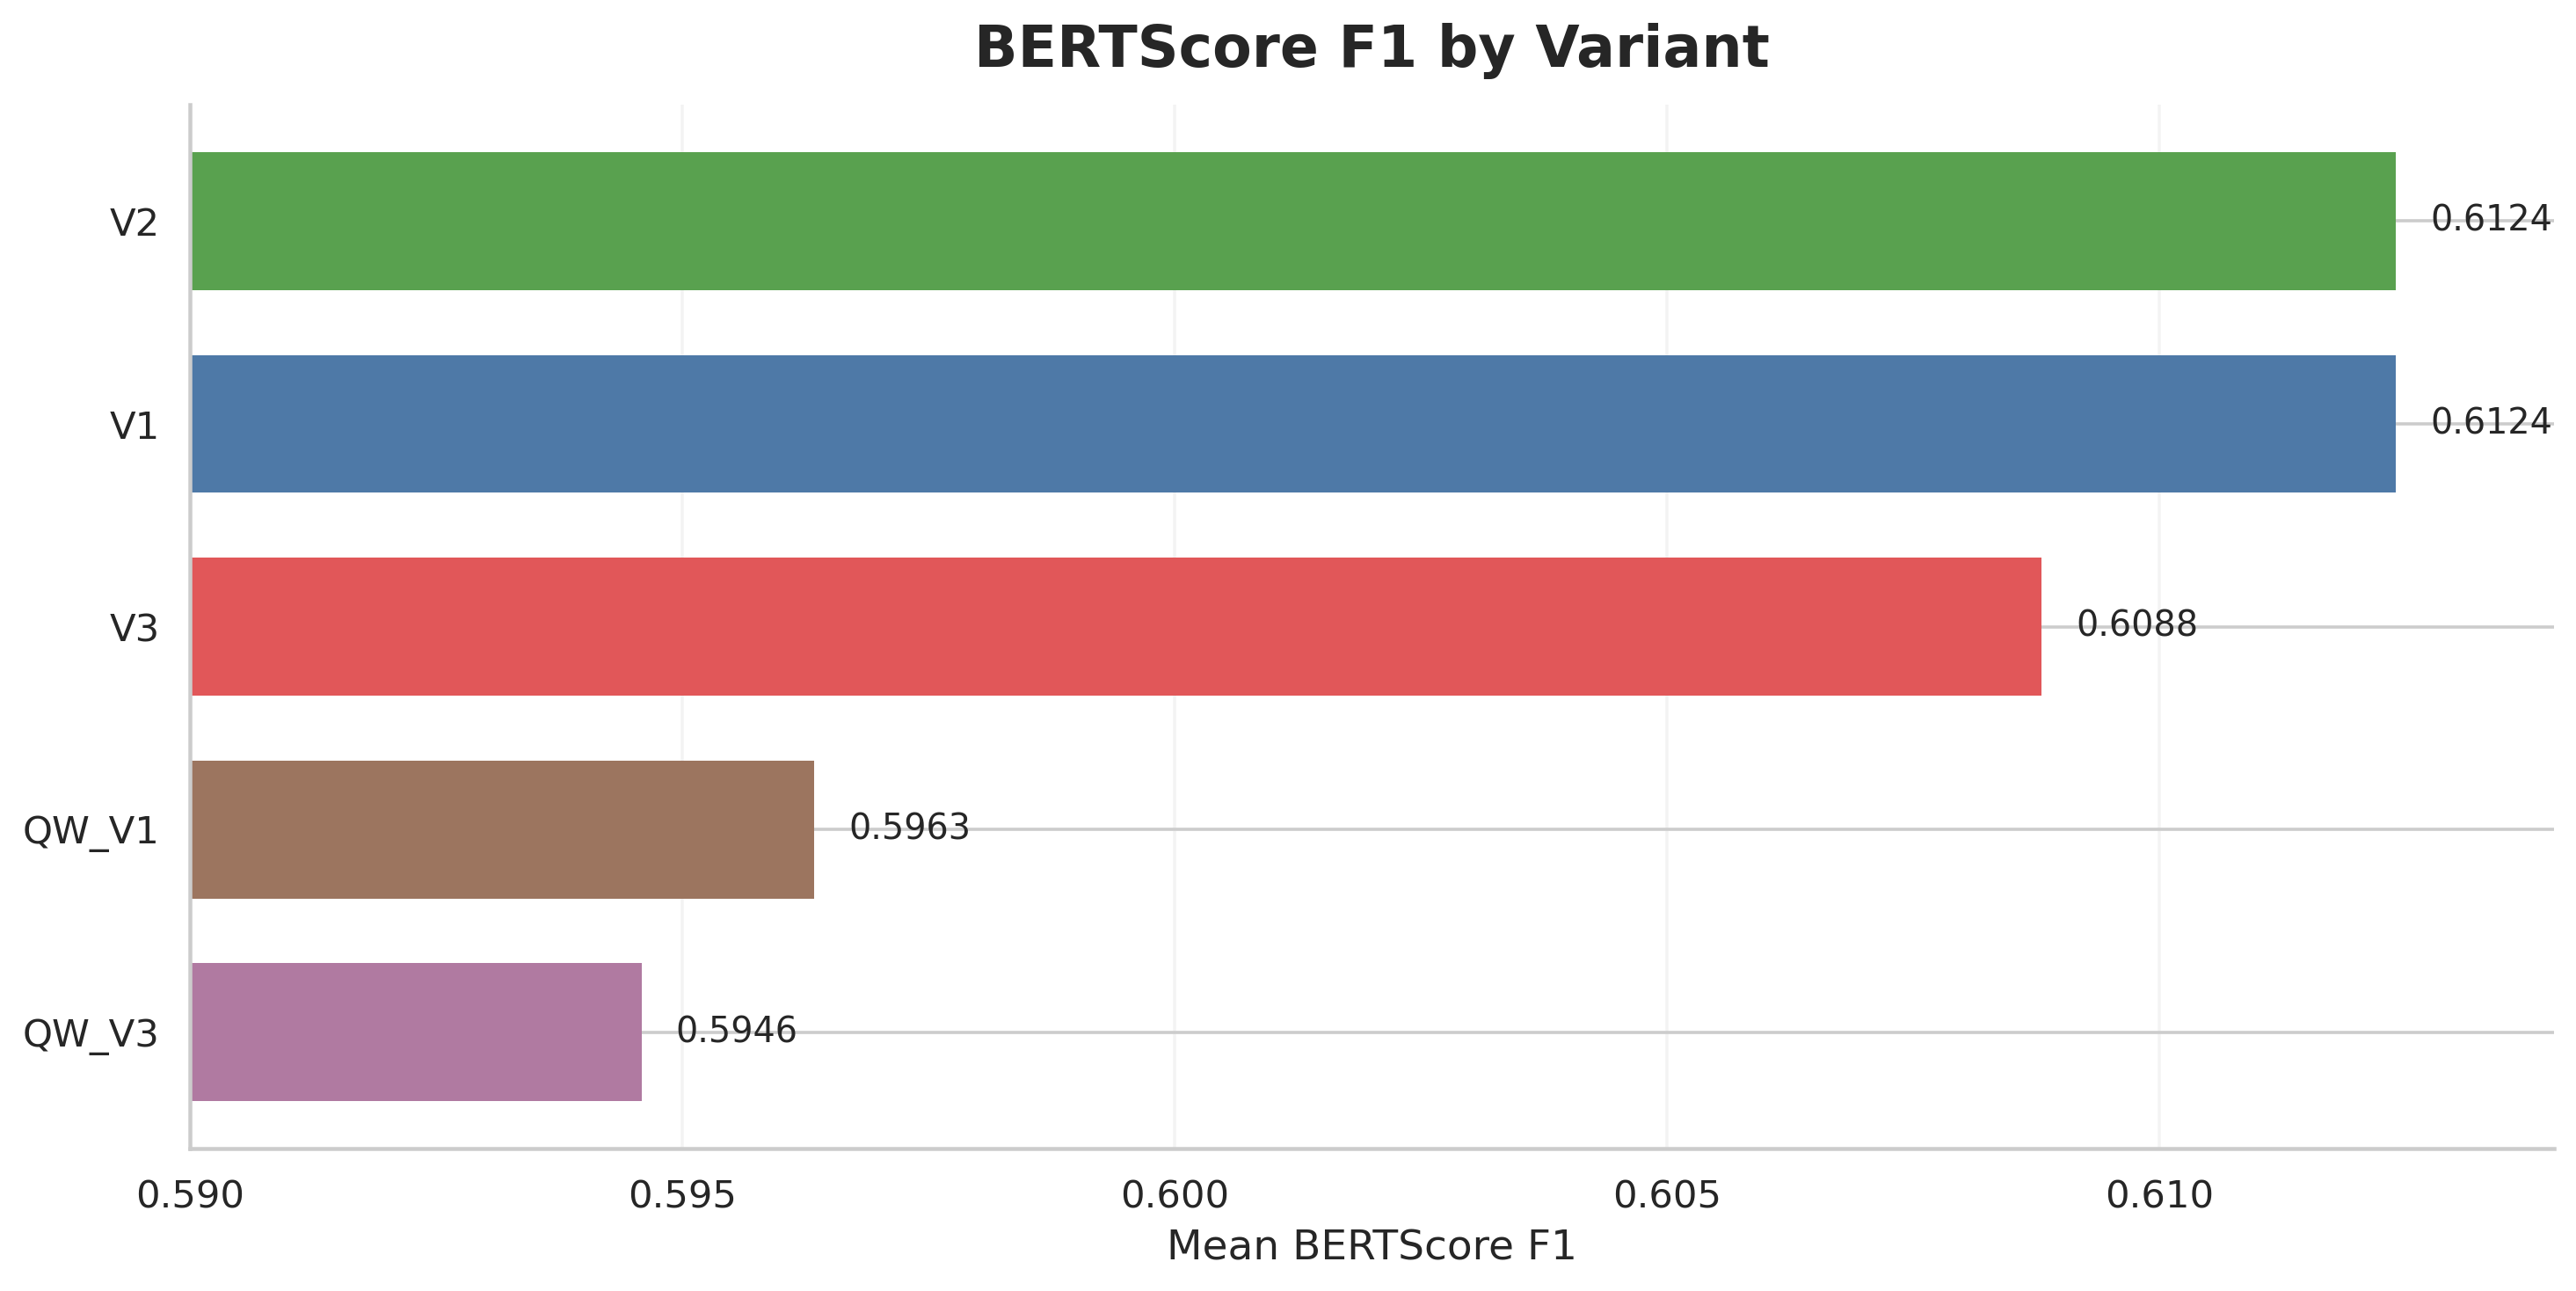

In [10]:
show_saved_figure('bertscore_f1_by_variant_clean.png', width=1400)


*What this tells me.* BERTScore shows that the strongest automated systems are very close together. `V2` scores `0.612398` and `V1` scores `0.612395`, which is basically a tie, while `V3` drops slightly to `0.608797`. The Qwen variants are lower at `0.596336` and `0.594583`. So BERTScore helps me see that `V1` and `V2` are the main automated leaders, but it does not tell me which one is safer for security guidance.


### 8.2 Proxy-Based RAGAS Evaluation

This figure uses the full `500`-row proxy run across all five systems. The main automated ranking variable is the **core composite**, which is the mean of context relevance and answer relevance. Faithfulness was also computed, but it stayed high for almost all systems, and citation validity was not useful for separating systems because all cited chunk IDs were constrained to the retrieved set.


### 7.3 Proxy Core Composite by Variant

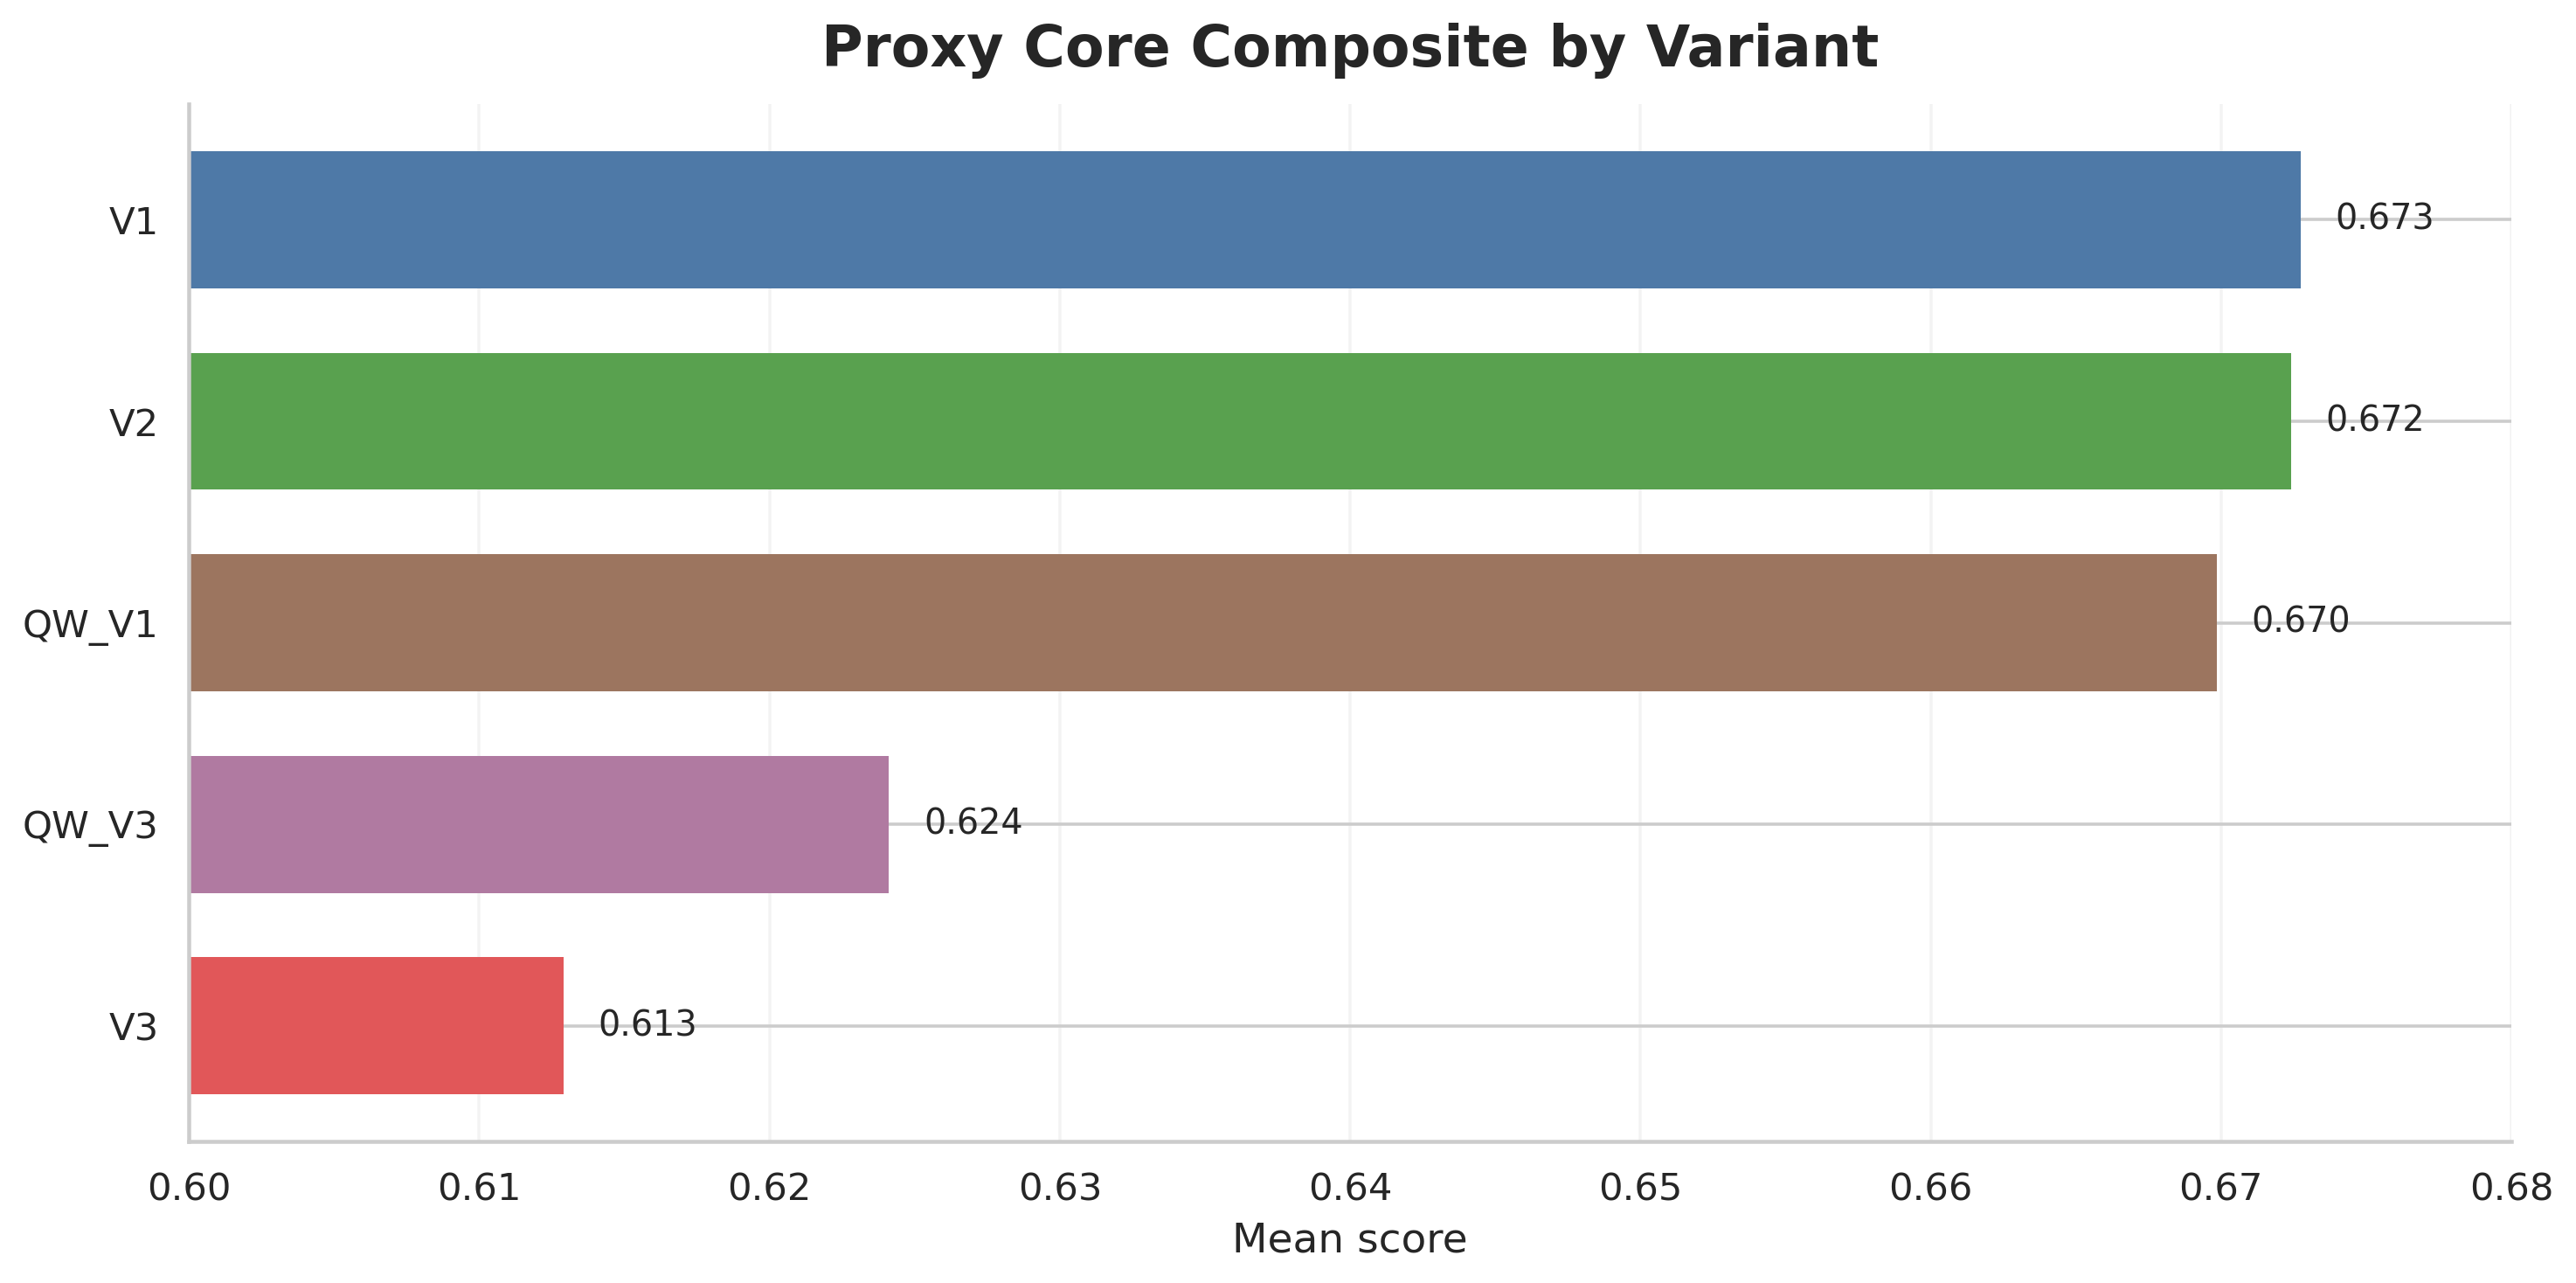

In [11]:
show_saved_figure('proxy_core_composite_by_variant_clean.png', width=1400)


*What this tells me.* The proxy core figure is more useful than BERTScore because it responds to both retrieval quality and answer focus. The top three systems are still close: `V1 = 0.672741`, `V2 = 0.672399`, and `QW_V1 = 0.669850`. The main detail is that `V2` has the strongest context relevance at `0.536847`, while `V1` is slightly stronger on answer relevance at `0.812343`. So the automated evidence suggests that `V2` retrieves slightly better context, but it still does not fully settle the final winner without the manual trustworthiness layer.


### 8.3 Manual Audit Summary

The manual audit looks at practical answer quality rather than semantic overlap alone. In the current audited sample, actionability and usefulness collapse to the same aggregate score across variants, so the main visual summarises a single manual quality score per system. Other trustworthiness signals are kept in the final comparison table and appendix.


### 7.4 Manual Quality Score by Variant

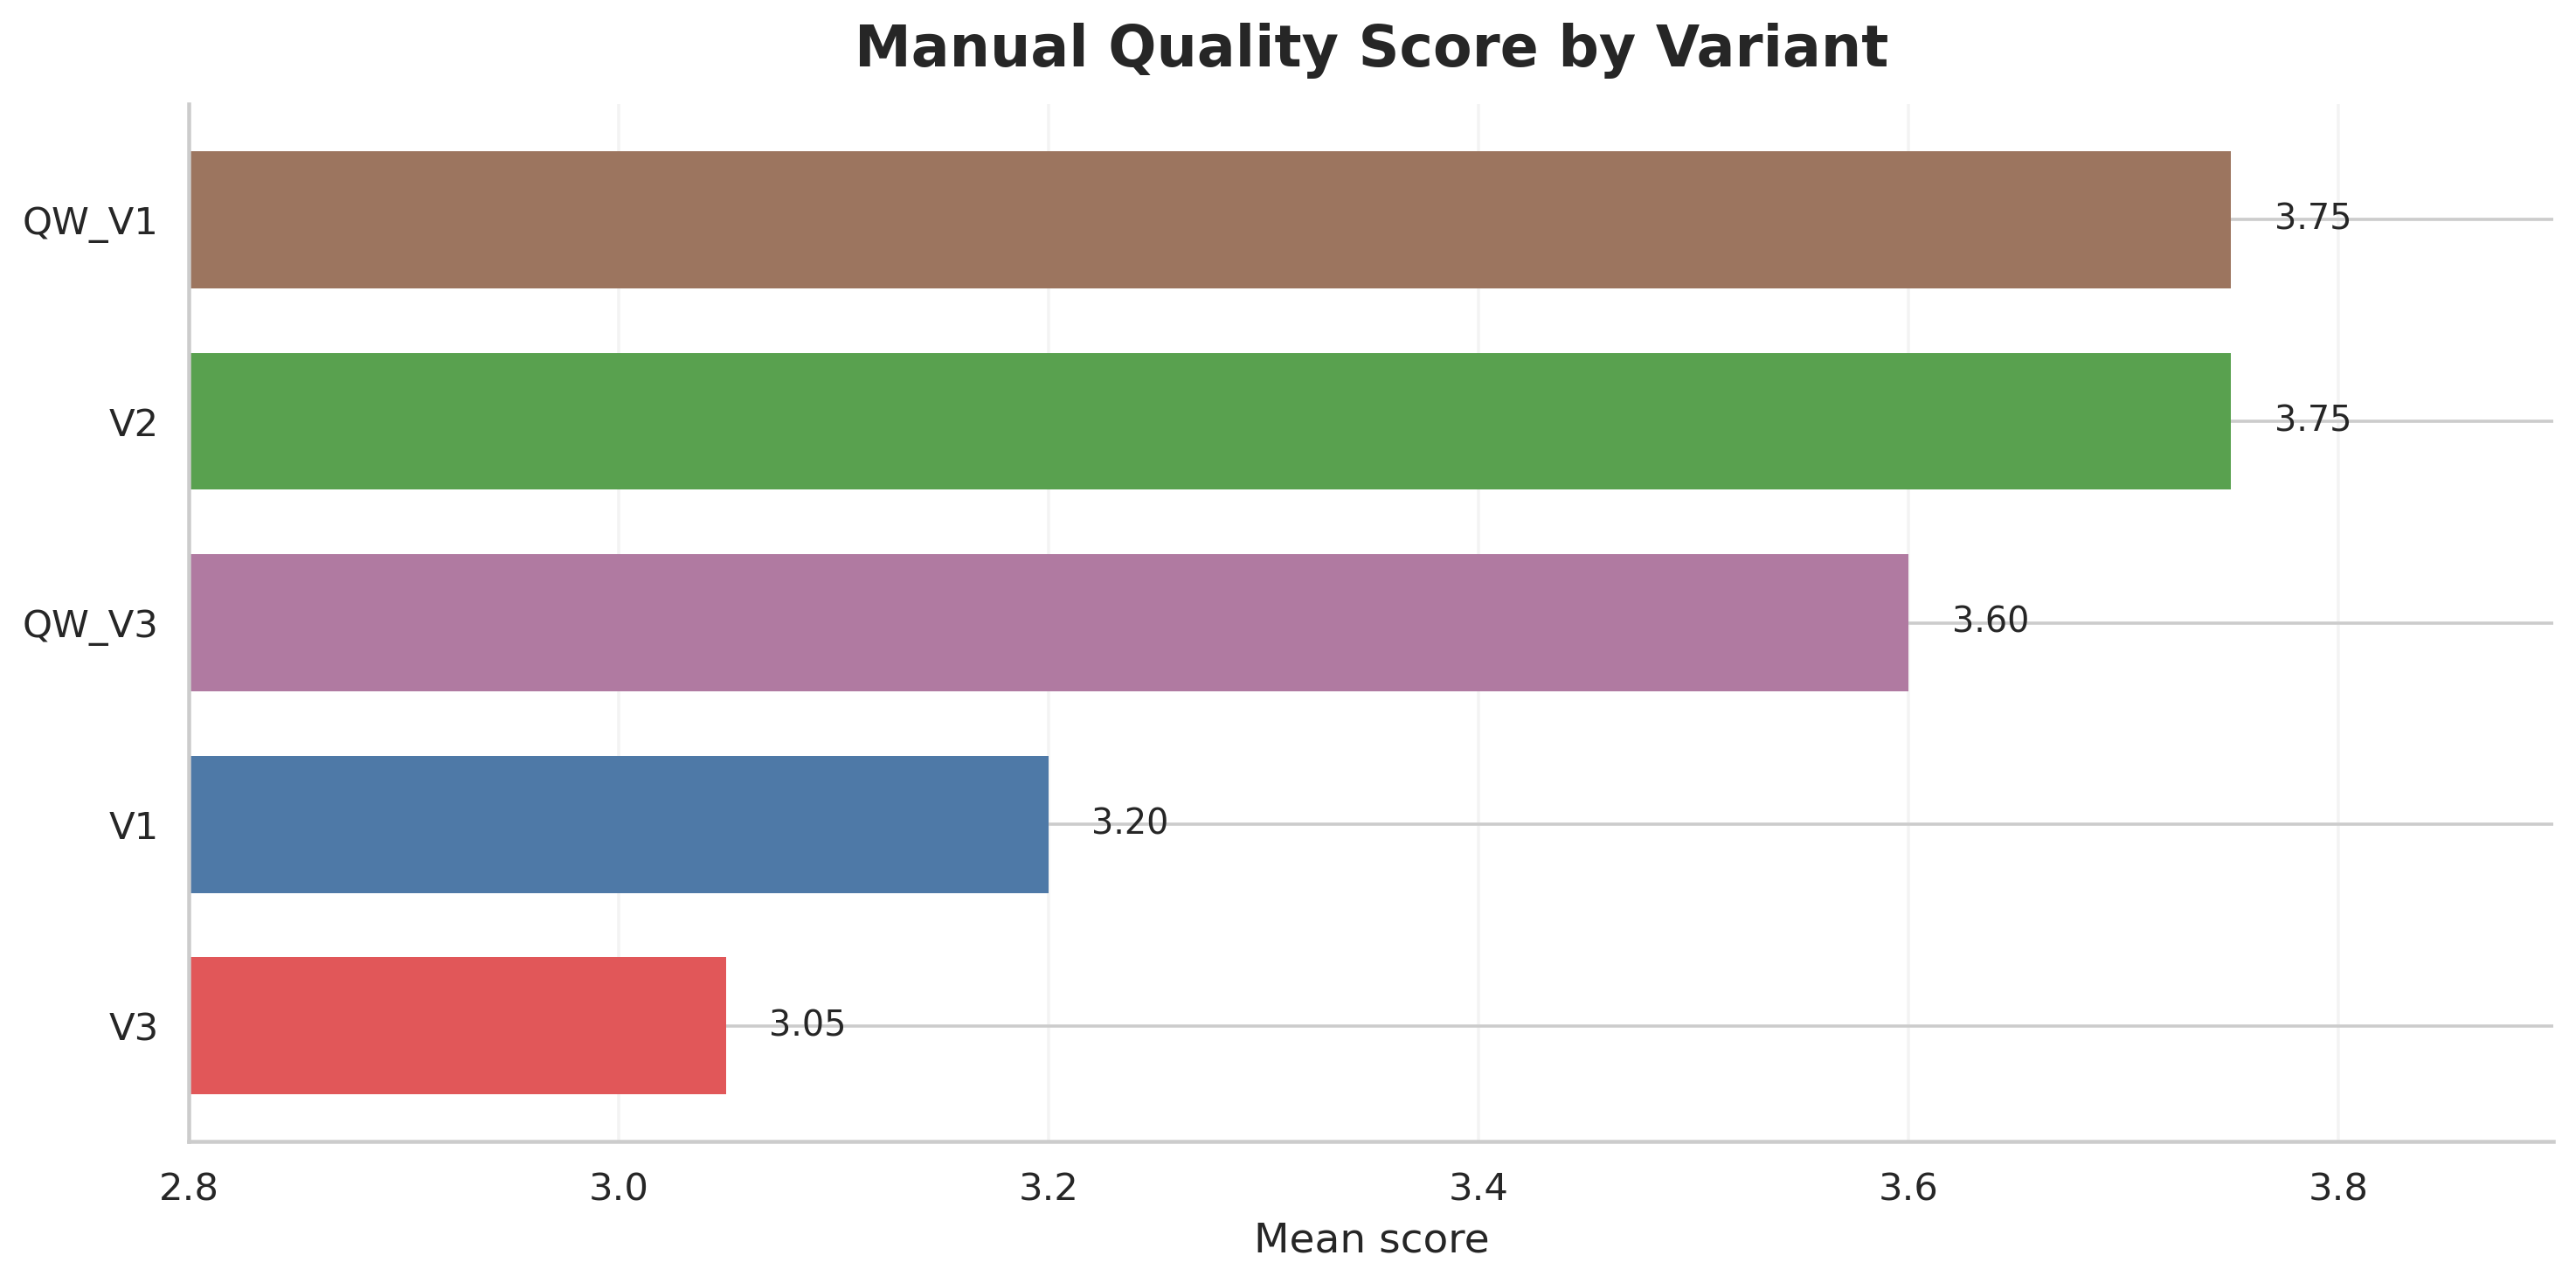

In [13]:
manual_quality_figure = find_first([
    FIGURES_DIR / 'manual_quality_score_by_variant_clean.png',
    FIGURES_DIR / 'manual_quality_scores_by_variant_clean.png',
])

display(Image(filename=str(manual_quality_figure), width=1400))


*What this tells me.* Manual quality changes the question from “which answer is closest to the reference” to “which answer would actually help a practitioner”. `V2` and `QW_V1` both reach `3.75`, `QW_V3` reaches `3.60`, `V1` drops to `3.20`, and `V3` falls to `3.05`. This means better fluency can partly make up for weaker retrieval, but it also means usefulness alone cannot choose the final system because `V2` and `QW_V1` still look tied here.


### 8.4 Failure Taxonomy

The failure taxonomy explains **how** systems fail, not just whether they score well on average. It is built from `100` manually coded audit rows and should be read as a manual error-analysis layer rather than an automatic classifier output. This matters in cybersecurity, where unsupported or fragmented advice can be more harmful than a small drop in similarity metrics.


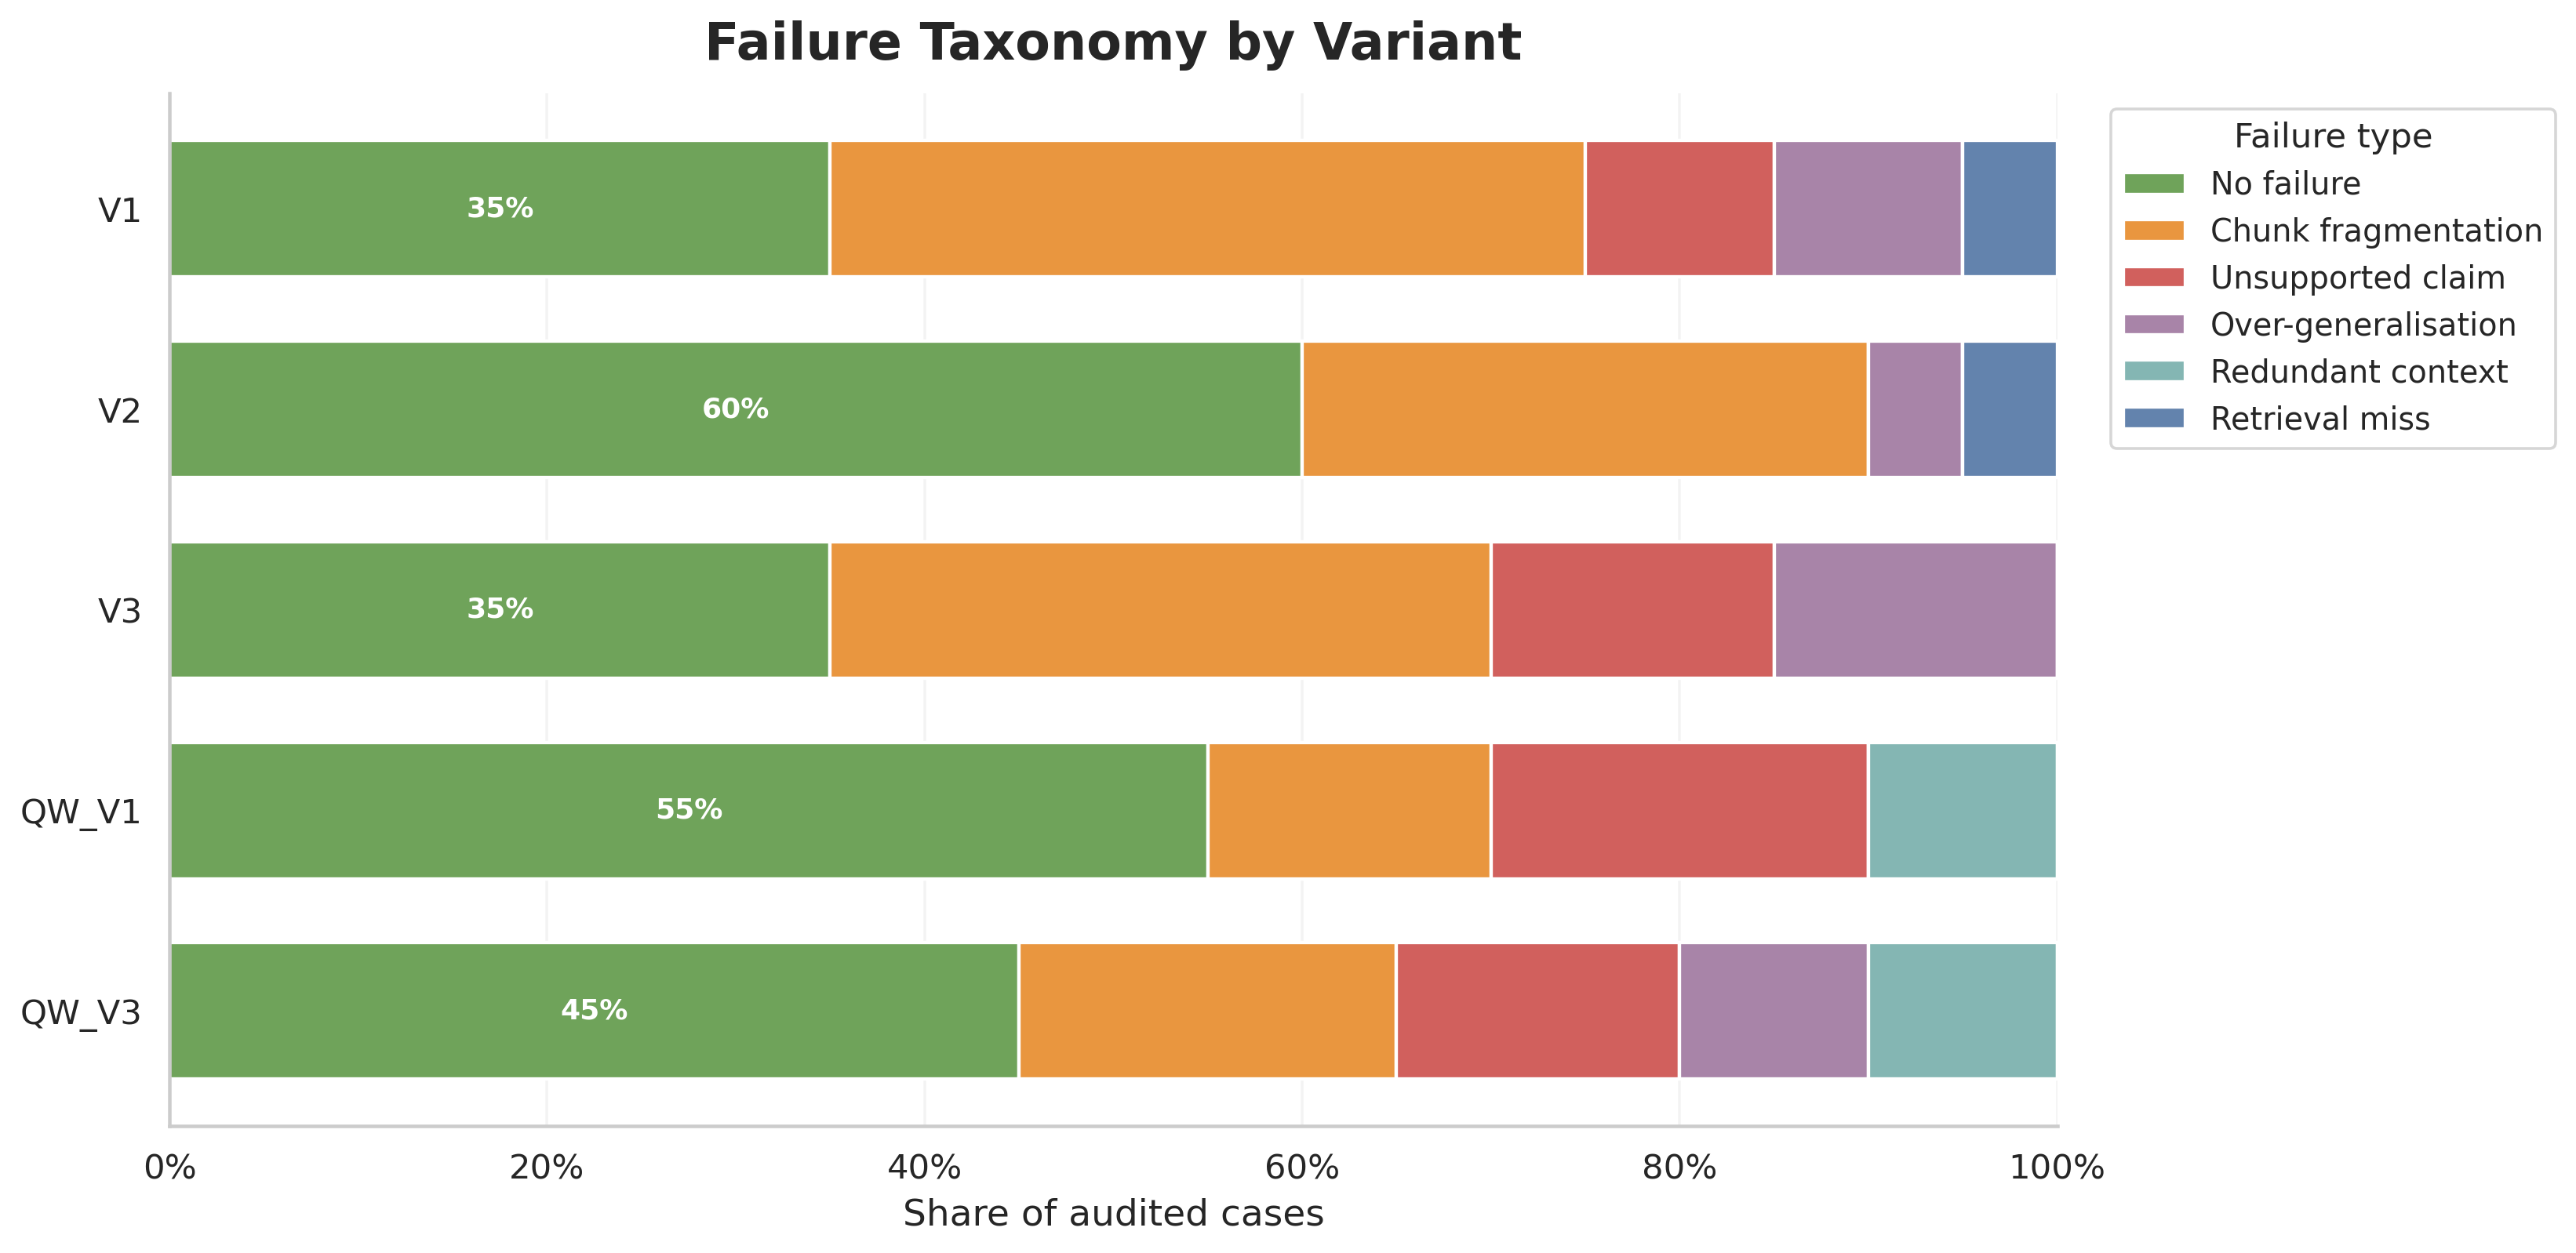

In [16]:
show_saved_figure('failure_taxonomy_by_variant_clean.png', width=1450)


*What this tells me.* The taxonomy is where the safety difference becomes much clearer. `V2` has the highest `no_failure` share at `60%`, while `V1` and `V3` both sit at `35%`. `V1` is mainly hurt by chunk fragmentation (`40%`), `V3` combines chunk fragmentation (`35%`) with over-generalisation (`15%`), and `QW_V1` has the clearest unsupported-claim problem (`20%` in the taxonomy). So `V2` is not perfect, but its failures are less likely to turn into unsupported operational advice.


### 8.5 Overall System Comparison

This table brings the strongest automated and manual signals into one place: BERTScore, core composite, manual quality, unsupported-claim rate, redundancy rate, and no-failure rate. It is the main decision table used to justify the final selection of `V2`.


In [24]:
from IPython.display import display, Markdown

overall_table_path = find_first([
    PHASE2_DIR / 'tables' / 'overall_system_comparison_table.csv',
])

overall_table = pd.read_csv(overall_table_path).copy()

overall_md = overall_table.copy()
overall_md['BERTScore F1'] = overall_md['BERTScore F1'].map(lambda x: f'{x:.4f}')
overall_md['Proxy Core Composite'] = overall_md['Proxy Core Composite'].map(lambda x: f'{x:.3f}')
overall_md['Manual Quality Score'] = overall_md['Manual Quality Score'].map(lambda x: f'{x:.2f}')
overall_md['Unsupported Claim Rate'] = overall_md['Unsupported Claim Rate'].map(lambda x: f'{x:.2%}')
overall_md['Redundancy Rate'] = overall_md['Redundancy Rate'].map(lambda x: f'{x:.2%}')
overall_md['No-Failure Rate'] = overall_md['No-Failure Rate'].map(lambda x: f'{x:.2%}')

display(Markdown(
    "Table X. Overall comparison across automated semantic similarity, "
    "proxy-based RAGAS evaluation, manual quality scoring, and failure analysis."
))
display(Markdown(overall_md.to_markdown(index=False)))


### 7.6 Overall System Comparison

Variant,BERTScore F1,Proxy Core Composite,Manual Quality Score,Unsupported Claim Rate,Redundancy Rate,No-Failure Rate,Interpretation
V1,0.6124,0.673,3.20,10.00%,0.00%,35.00%,Strong automated baseline; weaker manual trustworthiness.
V2,0.6124,0.672,3.75,0.00%,0.00%,60.00%,Best-balanced final system.
V3,0.6088,0.613,3.05,15.00%,0.00%,35.00%,Lower overall quality; intent enrichment not consistently beneficial.
QW_V1,0.5963,0.670,3.75,30.00%,10.00%,55.00%,"High usefulness, but highest unsupported-claim risk."
QW_V3,0.5946,0.624,3.60,15.00%,10.00%,45.00%,Moderate quality; safer than QW_V1 but still weaker than V2.


*What this tells me.* This table is where the final decision becomes clear. The automated metrics leave `V1` and `V2` almost tied (`0.612395` vs `0.612398` on BERTScore, `0.672741` vs `0.672399` on the proxy core), but the trustworthiness evidence breaks that tie. `V2` reaches a manual quality score of `3.75`, an unsupported-claim rate of `0.00`, and a `60%` no-failure rate. `V1` is weaker at `3.20`, `10%`, and `35%`, while `QW_V1` looks strong on quality (`3.75`) but is too risky on unsupported claims (`30%`).


### 8.6 Quantitative and Qualitative Synthesis

This table puts the strongest numbers and the qualitative reading together in one place before the cross-paper comparison. The goal is to make the final system logic explicit before moving into the broader discussion.


Table X. Quantitative and qualitative synthesis across the five evaluated systems.

| Variant | Key numbers | Qualitative reading | Final role |
|---|---|---|---|
| `V2` | BERTScore `0.6124`; Core proxy `0.6724`; Manual `3.75`; Unsupported `0%`; No-failure `60%` | Most balanced system. Retrieval stays focused, answers stay useful, and trust risk stays lowest. | **Selected final system** |
| `V1` | BERTScore `0.6124`; Core proxy `0.6727`; Manual `3.20`; Unsupported `10%`; No-failure `35%` | Strong automated baseline, but answers are more fragmented and less dependable in manual review. | Closest automated baseline |
| `QW_V1` | BERTScore `0.5963`; Core proxy `0.6699`; Manual `3.75`; Unsupported `30%`; No-failure `55%` | Very fluent and helpful, but too willing to go beyond retrieved evidence. | High-quality but riskier alternative |
| `QW_V3` | BERTScore `0.5946`; Core proxy `0.6241`; Manual `3.60`; Unsupported `15%`; No-failure `45%` | Safer than `QW_V1`, but still loses too much ground on average quality and retrieval focus. | Mid-tier alternative |
| `V3` | BERTScore `0.6088`; Core proxy `0.6129`; Manual `3.05`; Unsupported `15%`; No-failure `35%` | Can help on hidden-intent questions, but average performance is weaker and failures are less controlled. | Niche variant, not final choice |


*What this tells me.* This synthesis table turns the whole notebook into one decision view. `V1` is the strongest automated baseline, `QW_V1` is the most fluent alternative, and `V3` shows why niche wins do not automatically translate into good average performance. The key point is that only `V2` stays near the top on every major layer at once, which is why it survives the final comparison.


### 8.7 Comparison with Prior Work

This table is **not** a leaderboard because the four papers solve different tasks and use different datasets. I use it instead to compare design choices, trustworthiness mechanisms, and the kinds of evaluation evidence each project reports.


Table X. Comparison between this notebook and the four main prior-work references. The numbers below are reported as published in each paper and are not treated as directly comparable leaderboard scores.

| Study | Task and Domain | Method Summary | Key Reported Results | What I Would Adapt |
|---|---|---|---|---|
| This notebook | Kubernetes security hardening QA | Fixed local corpus, dense retrieval variants, top-3 prompt context, manual audit, failure taxonomy | V2: BERTScore 0.6124; Proxy 0.6724; Manual 3.75; Unsupported 0.00; No-failure 60% | Current baseline for comparison |
| [1] Web-scraped RAG | Educational assistance from scraped web content | Web scraping, preprocessing, FAISS retrieval, LLM generation, proxy-based RAGAS evaluation | Best model accuracy 86.67%; strong context recall and precision; weaker answer correctness | Scheduled source refresh and clearer hyperparameter sweeps |
| [2] RAGAS | Reference-free RAG evaluation toolkit | Separates faithfulness, answer relevance, and context relevance; stresses structured judge outputs | Faithfulness and answer relevance align well with human judgments; context relevance is hardest | More stable repeated judge runs and JSON-structured scoring |
| [3] CyberBOT | Cybersecurity education QA | Intent interpretation, top-3 retrieval, 512-token chunks, BGE embeddings, ontology verifier, live deployment | Avg. BERTScore 0.933; Context Recall 0.994; deployed to more than 100 students; 77-student quasi experiment | A lightweight validator and a user-facing evaluation study |
| [4] CyberRAG | Cyber-attack classification and reporting | Agentic controller, specialist classifiers, iterative retrieval, robustness testing, GPT-4 judge | Accuracy 94.92%; BERTScore 0.94; GPT-4 judge 4.9/5; RAG lifts accuracy 84.75 -> 94.92 | Second-pass retrieval, robustness tests, and stronger verifier stages |


*What this tells me.* This comparison is useful for design, not for claiming that my notebook beats every prior system. [1] shows how to keep web-derived content fresh, [2] shows why decomposed evaluation matters, [3] shows the value of explicit validation and user-facing evaluation, and [4] shows when extra architectural complexity is worth the cost. My notebook sits at the simpler end of this design space, so the most realistic next upgrades are a validation layer, stronger judge reproducibility, and a second retrieval pass for hard cases.


## 9. Deep-Dive Case Analysis

The quantitative results are supported by three qualitative case studies built from `3` selected questions, `15` generated answers, and `45` retrieved chunks. These cases were chosen to show one clear `V2` success (`Q052`), one clear `V3` success (`Q048`), and one failure case where no system solves the problem cleanly (`Q050`).


In [27]:
from pathlib import Path
import json
import ast
import pandas as pd
from IPython.display import display, Markdown

if 'PROJECT_ROOT' not in globals():
    raise RuntimeError('Run Section 4.2 Runtime Setup before this cell.')

from src.project_paths import build_notebook_paths
NOTEBOOK_PATHS = build_notebook_paths(PROJECT_ROOT)
PHASE2_DIR = NOTEBOOK_PATHS.phase2_dir
TABLES_DIR = NOTEBOOK_PATHS.phase2_tables_dir
TABLES_DIR.mkdir(parents=True, exist_ok=True)

proxy_path = TABLES_DIR / 'proxy_eval_scores_all_systems.csv'
if not proxy_path.exists():
    raise FileNotFoundError(proxy_path)

proxy_df = pd.read_csv(proxy_path).copy()

selected_cases = {
    'Q052': 'Clear V2 win: improved retrieval focus and best balanced answer on etcd encryption-at-rest.',
    'Q048': 'Clear V3 win: intent-enriched retrieval better surfaces the hostNetwork / NetworkPolicy interaction.',
    'Q050': 'Failure case: retrieval is moderately relevant, but answers still under-specify the requested extra controls beyond NetworkPolicy.',
}

def parse_listish(value):
    if isinstance(value, list):
        return [str(x) for x in value]
    if pd.isna(value):
        return []
    text = str(value).strip()
    if not text:
        return []

    for parser in (json.loads, ast.literal_eval):
        try:
            parsed = parser(text)
            if isinstance(parsed, list):
                return [str(x) for x in parsed]
        except Exception:
            pass

    return [text]

rows = []

for case_id, rationale in selected_cases.items():
    group = proxy_df[proxy_df['query_id'] == case_id].copy()

    if group.empty:
        raise ValueError(f'No rows found for deep-dive case {case_id}')

    group = group.sort_values('proxy_composite', ascending=False).reset_index(drop=True)

    for _, row in group.iterrows():
        contexts = parse_listish(row.get('contexts'))
        sources = parse_listish(row.get('retrieved_source_ids'))

        out = {
            'deep_dive_group': case_id,
            'deep_dive_rationale': rationale,
            'query_id': row['query_id'],
            'variant': row['variant'],
            'retrieval_variant': row['retrieval_variant'],
            'model_name': row['model_name'],
            'topic': row['topic'],
            'difficulty': row['difficulty'],
            'question': row['question'],
            'proxy_composite': row['proxy_composite'],
            'context_relevance_proxy': row['context_relevance_proxy'],
            'answer_relevance_proxy': row['answer_relevance_proxy'],
            'faithfulness_proxy': row['faithfulness_proxy'],
            'answer_text_plain': row['answer'],
            'answer_text': row['answer_with_citations'],
        }

        for i in range(3):
            out[f'context_{i+1}'] = contexts[i] if i < len(contexts) else ''
            out[f'source_{i+1}'] = sources[i] if i < len(sources) else ''

        rows.append(out)

deep_df = pd.DataFrame(rows)

csv_out = TABLES_DIR / 'deep_dive_cases.csv'
deep_df.to_csv(csv_out, index=False)

# Optional markdown companion
def unique_sources(row):
    vals = []
    for col in ['source_1', 'source_2', 'source_3']:
        val = str(row.get(col, '')).strip()
        if val and val not in vals:
            vals.append(val)
    return ', '.join(vals)

md_lines = ['# Deep-Dive Cases', '']

for case_id, group in deep_df.groupby('deep_dive_group', sort=False):
    group = group.sort_values('proxy_composite', ascending=False).reset_index(drop=True)

    md_lines.append(f'## {case_id}')
    md_lines.append(f"**Question:** {group['question'].iloc[0]}")
    md_lines.append(f"**Rationale:** {group['deep_dive_rationale'].iloc[0]}")
    md_lines.append('')
    md_lines.append('| Variant | Retrieval | Proxy Composite | Context Relevance | Answer Relevance | Faithfulness | Top Sources |')
    md_lines.append('|---|---|---:|---:|---:|---:|---|')

    for _, row in group.iterrows():
        md_lines.append(
            f"| {row['variant']} | {row['retrieval_variant']} | "
            f"{row['proxy_composite']:.3f} | {row['context_relevance_proxy']:.3f} | "
            f"{row['answer_relevance_proxy']:.3f} | {row['faithfulness_proxy']:.3f} | "
            f"{unique_sources(row)} |"
        )

    md_lines.append('')

md_out = TABLES_DIR / 'deep_dive_cases.md'
md_out.write_text('\n'.join(md_lines), encoding='utf-8')

preview_cols = [
    'deep_dive_group',
    'variant',
    'retrieval_variant',
    'proxy_composite',
    'context_relevance_proxy',
    'answer_relevance_proxy',
    'faithfulness_proxy',
]




### Deep-Dive Cases Regenerated

,deep_dive_group,variant,retrieval_variant,proxy_composite,context_relevance_proxy,answer_relevance_proxy,faithfulness_proxy
0,Q052,V2,V2,0.8941,0.8182,0.8641,1.00
1,Q052,QW_V1,V1,0.7852,0.5333,0.8223,1.00
2,Q052,V1,V1,0.7742,0.5333,0.7892,1.00
3,Q052,QW_V3,V3,0.7347,0.4706,0.7335,1.00
4,Q052,V3,V3,0.7157,0.4706,0.6764,1.00
5,Q048,V3,V3,0.9131,0.8462,0.8931,1.00
6,Q048,QW_V3,V3,0.8145,0.8462,0.8474,0.75
7,Q048,V1,V1,0.7888,0.4783,0.8882,1.00
8,Q048,V2,V2,0.7888,0.4783,0.8882,1.00
9,Q048,QW_V1,V1,0.7428,0.4783,0.7500,1.00


Saved:
/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/output/phase2/tables/deep_dive_cases.csv
/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3/output/phase2/tables/deep_dive_cases.md


### 9.1 Case Comparison Overview

Before looking at the full answer traces, I summarise the three selected cases numerically.

| Case | Strongest variant | Proxy composite | Runner-up | Margin | What the case shows |
|---|---|---:|---|---:|---|
| `Q052` | `V2` | `0.8941` | `QW_V1` (`0.7852`) | `+0.1089` | Focused retrieval around encryption-at-rest gives `V2` a clear lead. |
| `Q048` | `V3` | `0.9131` | `QW_V3` (`0.8145`) | `+0.0986` | Query enrichment helps when the question depends on an implicit relation. |
| `Q050` | `QW_V1` | `0.7248` | `QW_V3` (`0.7037`) | `+0.0211` | No system solves the question cleanly; the small margin reflects a shared failure case. |

These margins matter because they show that the deep-dive section is not just anecdotal. Two cases show genuine variant-specific strengths, while the third shows a failure mode that remains hard for everyone.


In [29]:
from IPython.display import display, Markdown
import pandas as pd

deep_dive_path = glob_first([
    'deep_dive_cases.csv',
    '*deep_dive*cases*.csv',
])

if deep_dive_path is None:
    raise FileNotFoundError(
        "No deep_dive_cases.csv found in Drive tables folder."
    )

deep_df = pd.read_csv(deep_dive_path).copy()

def clean_topic(text):
    return str(text).replace('_', ' ').title()

def compact_sources(row):
    vals = []
    for col in ['source_1', 'source_2', 'source_3']:
        val = str(row.get(col, '')).strip()
        if val and val != 'nan' and val not in vals:
            vals.append(val)
    return ', '.join(vals)

def short_answer(text, limit=420):
    text = str(text).replace('\n', ' ').strip()
    text = ' '.join(text.split())
    if len(text) <= limit:
        return text
    return text[:limit].rsplit(' ', 1)[0] + ' ...'


for case_id, group in deep_df.groupby('deep_dive_group', sort=False):
    group = group.sort_values('proxy_composite', ascending=False).reset_index(drop=True)

    question = group.loc[0, 'question']
    rationale = group.loc[0, 'deep_dive_rationale']
    topic = clean_topic(group.loc[0, 'topic'])
    difficulty = str(group.loc[0, 'difficulty']).title()

    summary_df = group[[
        'variant',
        'retrieval_variant',
        'proxy_composite',
        'context_relevance_proxy',
        'answer_relevance_proxy',
        'faithfulness_proxy',
    ]].copy()

    summary_df['Top Sources'] = group.apply(compact_sources, axis=1).values

    summary_df = summary_df.rename(columns={
        'variant': 'Variant',
        'retrieval_variant': 'Retrieval',
        'proxy_composite': 'Proxy Composite',
        'context_relevance_proxy': 'Context Relevance',
        'answer_relevance_proxy': 'Answer Relevance',
        'faithfulness_proxy': 'Faithfulness',
    })

    for col in ['Proxy Composite', 'Context Relevance', 'Answer Relevance', 'Faithfulness']:
        summary_df[col] = summary_df[col].map(lambda x: f'{x:.3f}')

    display(Markdown(f"#### Case {case_id}"))
    display(Markdown(
        f"**Question:** {question}  \n"
        f"**Topic:** {topic}  \n"
        f"**Difficulty:** {difficulty}  \n"
        f"**Why this case matters:** {rationale}"
    ))

    display(summary_df)

    for _, row in group.iterrows():
        sources = compact_sources(row)
        excerpt = short_answer(row['answer_text_plain'], limit=420)

        display(Markdown(
            f"**{row['variant']}**  \n"
            f"Retrieval: `{row['retrieval_variant']}`  \n"
            f"Proxy composite: `{row['proxy_composite']:.3f}`  \n"
            f"Top sources: `{sources}`"
        ))
        display(Markdown(f"> {excerpt}"))

    display(Markdown("---"))

### 7.7 Deep-Dive Case Analysis

#### Case Q052

**Question:** Why should confidential Kubernetes data be encrypted at rest?  
**Topic:** Etcd And Data Protection  
**Difficulty:** Basic  
**Why this case matters:** Clear V2 win: improved retrieval focus and best balanced answer on etcd encryption-at-rest.

,Variant,Retrieval,Proxy Composite,Context Relevance,Answer Relevance,Faithfulness,Top Sources
0,V2,V2,0.894,0.818,0.864,1.000,"k8s_operational_security_docs, k8s_security_ob..."
1,QW_V1,V1,0.785,0.533,0.822,1.000,k8s_operational_security_docs
2,V1,V1,0.774,0.533,0.789,1.000,k8s_operational_security_docs
3,QW_V3,V3,0.735,0.471,0.734,1.000,"owasp_k8s_cheatsheet, k8s_security_docs, k8s_s..."
4,V3,V3,0.716,0.471,0.676,1.000,"owasp_k8s_cheatsheet, k8s_security_docs, k8s_s..."


**V2**  
Retrieval: `V2`  
Proxy composite: `0.894`  
Top sources: `k8s_operational_security_docs, k8s_security_observability_book`

...

**V1**  
Retrieval: `V1`  
Proxy composite: `0.634`  
Top sources: `k8s_operational_security_docs`

> NetworkPolicy alone may not be sufficient for comprehensive security. You may need additional controls, such as: * **Network Segmentation:** Isolate sensitive workloads and services from the rest of the network. * **Traffic Inspection:** Implement additional security tools like firewalls or intrusion detection systems to analyze and control traffic flow. * **Access Control Lists (ACLs):** Define granular access ...

**V2**  
Retrieval: `V2`  
Proxy composite: `0.634`  
Top sources: `k8s_operational_security_docs`

> NetworkPolicy alone may not be sufficient for comprehensive security. You may need additional controls, such as: * **Network Segmentation:** Isolate sensitive workloads and services from the rest of the network. * **Traffic Inspection:** Implement additional security tools like firewalls or intrusion detection systems to analyze and control traffic flow. * **Access Control Lists (ACLs):** Define granular access ...

---

*What this tells me.* The deep-dive section explains the average results in a more concrete way.

- **Q052** is the clearest `V2` success. `V2` reaches `0.8941`, which is `0.1089` above the runner-up and driven mainly by its much higher context relevance (`0.8182`).
- **Q048** is the best example of why I did not reject `V3` completely. Here `V3` reaches `0.9131`, which is `0.0986` above the runner-up and shows that query enrichment can help when the security relationship is implicit rather than obvious.
- **Q050** is the reality check. The winning margin is only `0.0211`, and even the best score stays at `0.7248`. That tells me the benchmark contains genuinely hard questions where partly relevant retrieval is still not enough to produce complete security guidance.

So the deep-dive cases support the broader result: `V2` is the best average system, `V3` has niche value, and retrieval alone does not remove the need for human review.


### 9.2 Generated Answers and Retrieved Evidence

This section shows the actual evidence chain for the three selected questions: the benchmark query, all `5` system answers, and the top-`3` chunks inserted into the prompt for each answer. In total, that means `15` answer traces and `45` retrieved chunks. This is the most concrete inspection layer in the notebook because it lets me check whether a system is really using the retrieved evidence or only sounding plausible.


In [32]:
from IPython.display import display, Markdown
import pandas as pd

deep_dive_path = glob_first([
    'deep_dive_cases.csv',
    '*deep_dive*cases*.csv',
])

if deep_dive_path is None:
    raise FileNotFoundError("No deep_dive_cases.csv found.")

deep_df = pd.read_csv(deep_dive_path).copy()

VARIANT_ORDER = ['V1', 'V2', 'V3', 'QW_V1', 'QW_V3']

def clean_topic(text):
    return str(text).replace('_', ' ').title()

def short_text(text, limit=550):
    text = str(text).replace('\n', ' ').strip()
    text = ' '.join(text.split())
    if len(text) <= limit:
        return text
    return text[:limit].rsplit(' ', 1)[0] + ' ...'


for case_id, group in deep_df.groupby('deep_dive_group', sort=False):
    group = group.copy()
    group['variant'] = pd.Categorical(group['variant'], categories=VARIANT_ORDER, ordered=True)
    group = group.sort_values('variant').reset_index(drop=True)

    question = str(group.loc[0, 'question']).strip()
    rationale = str(group.loc[0, 'deep_dive_rationale']).strip()
    topic = clean_topic(group.loc[0, 'topic'])
    difficulty = str(group.loc[0, 'difficulty']).title()

    display(Markdown(
        f"## Case {case_id}\n\n"
        f"**Query:** {question}\n\n"
        f"**Topic:** {topic}  \n"
        f"**Difficulty:** {difficulty}  \n"
        f"**Why selected:** {rationale}"
    ))

    for _, row in group.iterrows():
        display(Markdown(
            f"### {row['variant']}\n\n"
            f"**Model:** `{row['model_name']}`  \n"
            f"**Retrieval variant:** `{row['retrieval_variant']}`  \n"
            f"**Proxy composite:** `{row['proxy_composite']:.3f}`  \n"
            f"**Context relevance:** `{row['context_relevance_proxy']:.3f}`  \n"
            f"**Answer relevance:** `{row['answer_relevance_proxy']:.3f}`  \n"
            f"**Faithfulness:** `{row['faithfulness_proxy']:.3f}`"
        ))

        answer_text = str(row['answer_text_plain']).strip()
        display(Markdown("**Generated answer**"))
        display(Markdown(f"```text\n{answer_text}\n```"))

        display(Markdown("**Top 3 retrieved chunks**"))

        for i in range(1, 4):
            source = str(row.get(f'source_{i}', '')).strip()
            chunk = short_text(row.get(f'context_{i}', ''), limit=550)

            if source and source != 'nan' and chunk and chunk != 'nan':
                display(Markdown(
                    f"**Chunk {i}**  \n"
                    f"Source: `{source}`"
                ))
                display(Markdown(f"> {chunk}"))

        display(Markdown("---"))

### 7.7 Deep-Dive Query Results Across All Systems

## Case Q052

**Query:** Why should confidential Kubernetes data be encrypted at rest?

**Topic:** Etcd And Data Protection  
**Difficulty:** Basic  
**Why selected:** Clear V2 win: improved retrieval focus and best balanced answer on etcd encryption-at-rest.

### V1

**Model:** `Gemma-2-2B-IT`  
**Retrieval variant:** `V1`  
**Proxy composite:** `0.774`  
**Context relevance:** `0.533`  
**Answer relevance:** `0.789`  
**Faithfulness:** `1.000`

**Generated answer**

```text
Confidential Kubernetes data should be encrypted at rest to protect it from unauthorized access. This is in addition to any system-level encryption already in place. You can encrypt Secrets, ConfigMaps, and other resources.
```

...

**Chunk 2**  
Source: `k8s_security_observability_book`

> CHAPTER 7 Network Policy In this chapter, we will describe network policy and discuss its importance in securing a Kubernetes cluster. We will review various network policy implementations and tooling to support network policy implementations. We will also cover network pol‐ icy best practices with examples. What Is Network Policy? Network policy is the primary tool for securing a Kubernetes network. It allows you to easily restrict the network traffic in your cluster so only the traffic that you want to flow is allowed. To understand the ...

**Chunk 3**  
Source: `k8s_security_observability_book`

> As a result, if no other network policy applies that explicitly allows the traffic, then the traffic will be denied: apiVersion: networking.k8s.io/v1 kind: NetworkPolicy metadata: name: default-deny Namespace: my-namespace spec: podSelector: {} policyTypes: - Ingress - Egress Since Kubernetes network policy is namespaced, the network policy mentioned pre‐ viously needs repeating for each namespace and ideally needs to be built into the standard operating procedure for provisioning new namespaces in the cluster. Alter‐ natively, some network ...

---

*What this tells me.* The deep-dive section explains the average results in concrete terms.

- **Q052** is the clearest `V2` success. `V2` reaches a proxy composite of `0.8941`, well above `QW_V1` (`0.7852`) and `V1` (`0.7742`). The main gain is retrieval focus: `V2` lifts context relevance to `0.8182`, while the next systems stay at `0.5333` or lower.
- **Q048** is the best example of why I did not dismiss `V3` completely. Here `V3` reaches `0.9131`, far ahead of `V1` and `V2` (both `0.7888`). This supports the idea that query enrichment can help when the question depends on an implicit security relationship rather than a simple keyword match.
- **Q050** is the reality check. No system exceeds `0.7248`, and `V1` and `V2` both stay at `0.6337`. This tells me the benchmark contains genuinely hard questions where partially relevant retrieval is still not enough to produce complete security guidance. So the deep-dive cases support the broader result: `V2` is the best average system, `V3` has niche value, and retrieval alone does not remove the need for human review.


## 10. Discussion

The main numerical pattern in this notebook is simple: the top systems are very close on the broad automated metrics. `V1` and `V2` are almost identical on BERTScore F1 (`0.612395` vs `0.612398`) and also very close on the proxy core composite (`0.672741` vs `0.672399`). That is exactly the kind of situation where a single similarity metric becomes too weak as a final decision tool. The tie only breaks once trustworthiness evidence is added. `V2` keeps the top manual quality score (`3.75`), removes unsupported claims in the audited sample (`0.00`), and raises the no-failure rate to `60%`, while `V1` stays at `3.20`, `10%`, and `35%`. So the real conclusion is not “`V2` wins every metric.” It is “`V2` stays competitive everywhere and is clearly safer where it matters most.”

`V3` is the most interesting mixed case. Its average results are clearly weaker than `V2`: `0.608797` BERTScore, `0.612897` proxy core, `3.05` manual quality, and `15%` unsupported claims. But the deep-dive analysis shows why it should not simply be ignored. In `Q048`, `V3` reaches `0.9131` and clearly beats `V1` and `V2` (both `0.7888`) because the rewritten query better surfaces the `hostNetwork` and NetworkPolicy relationship. The problem is consistency. The retrieval summary already showed that `V3` concentrated its outputs into only `7` unique sources, compared with `12` for `V1` and `V2`, and the taxonomy shows more over-generalisation. In simple terms, the rewritten query sometimes helps `V3` find the hidden security idea, but on average it narrows the evidence too much. That is why `V3` uses fewer sources, gets lower context relevance (`0.4414`), and ends up with more fragmented or over-generalised answers.

`QW_V1` is the clearest caution case in the notebook. On the surface, it looks strong because it reaches the same manual quality score as `V2` (`3.75`) and stays close on the core proxy metric (`0.669850` versus `0.672399`). But the manual audit shows that this fluency comes with a much higher trustworthiness cost: `QW_V1` records an unsupported-claim rate of `30%`, compared with `0%` for `V2`. The failure taxonomy points in the same direction, with `QW_V1` showing the clearest unsupported-claim problem there as well (`20%`). My reading is that this model often produces answers that sound useful and complete, but are more willing to go beyond the retrieved evidence. In a cybersecurity setting, that is a serious weakness because confident unsupported advice can be more dangerous than a shorter but better-grounded answer.

The paper comparison also helps explain where this notebook sits in the broader design space. Compared with the web-grounded RAG system of Kanataria et al. [1], my notebook is less live and more reproducible because I snapshot the corpus instead of retrieving directly from a continuously updated web pipeline. Their paper also reports a pattern that matches my own findings: strong retrieval-related scores can coexist with weaker answer correctness, which is why they report very strong context scores but a weaker answer-correctness dimension [1]. Compared with RAGAS [2], my notebook follows the same split between faithfulness, answer relevance, and context relevance, but the full API-judge path would have required stable OpenAI API access and sufficient paid credits to run at report scale. That is why the final automated comparison stays proxy-based while still following the same core dimensions. Compared with CyberBOT [3], my pipeline is much simpler. CyberBOT uses a rule-based intent interpreter, top-3 retrieval, `512`-token chunks, `bge-large-1.5` embeddings, and an ontology verifier, then evaluates both offline metrics and classroom use. I do not have that validation layer, which is probably the most valuable idea I could borrow next. Compared with CyberRAG [4], I am also deliberately simpler: CyberRAG uses iterative retrieval, specialist models, robustness tests, and a stronger external judge setup, which helps push its task-specific accuracy from `84.75%` to `94.92%`. Those numbers are not directly comparable because the task is attack classification and reporting rather than hardening QA, but the methodological lesson is still useful: in high-risk cybersecurity tasks, extra verification stages are often worth the added complexity.

Taken together, the results point to a practical design lesson. A small RAG system can already provide useful Kubernetes hardening guidance if the corpus is controlled, retrieval is kept simple, and the final choice is based on trustworthiness rather than fluency alone. In this notebook, that is exactly why `V2` is the best final system.


## 11. Limitations, Ethics, and Future Work

### 11.1 Limitations

1. **The final automated evaluation is proxy-based rather than the full API-judge RAGAS pipeline.** I did explore the judge-based RAGAS workflow on a frozen `40`-row subset, but completing it properly at report scale would have required stable OpenAI API access and sufficient paid credits. The final automated comparison therefore relies on proxy-based RAGAS evaluation rather than the full API-judge framework [2]. I am being explicit about this because the assignment expects RAGAS-style evaluation, and my notebook follows the same core dimensions even though the final evidence layer is proxy-based.
2. **The manual trustworthiness evidence is still sample-based.** The manual scoring and failure taxonomy each cover `100` outputs, which is `20%` of the full `500`-output generation set. That means `400` outputs are still unreviewed by hand. The sample is balanced at `20` cases per system, so I think the conclusions are strong enough for ranking, but they should still be read as credible sample-based evidence rather than as a complete review of every answer.
3. **The benchmark is broad for one notebook, but still narrow compared with real deployment.** I evaluate `100` Kubernetes hardening questions across `10` topics, which is enough to test different retrieval and generation behaviours. However, the conclusions should still be treated as domain-specific rather than as general claims about all cybersecurity RAG systems.
4. **The corpus is frozen, which improves auditability but weakens freshness.** Snapshotting the sources makes the experiment reproducible and much easier to inspect than a live web pipeline [1]. At the same time, it also means the system can become outdated if the corpus is not refreshed when Kubernetes guidance changes.
5. **The generation setup is intentionally conservative.** Responses were capped at `180` tokens, and the final runs avoided more aggressive memory-saving options such as `4-bit` quantisation. This made the notebook easier to run and easier to compare fairly across systems, but it may also have limited answer completeness and reduced how much detail some systems could provide on harder questions.
6. **Context relevance stays fairly modest even for the best system.** The strongest context relevance mean is only `0.536847` for `V2`. I think this happens for three main reasons: the benchmark questions often require explanation rather than direct fact extraction, only `3` chunks are passed into the prompt, and the score is averaged over `100` mixed-difficulty questions. In other words, the retrieved context is often useful, but not always tightly aligned enough to produce very high context-relevance averages.
7. **The architecture is intentionally simple.** Unlike CyberBOT [3], I do not use ontology-based validation. Unlike CyberRAG [4], I do not use iterative retrieval, specialist agents, or explicit robustness testing. This simplicity is useful for a compact assignment pipeline, but it also limits how far trustworthiness can be pushed automatically.
8. **Some automated metrics are not very useful for separating top systems.** Faithfulness stays high for almost all variants, and citation validity is `1.00` for every system because citations are constrained to retrieved chunk IDs. So even though those metrics are still worth reporting, they contribute less to the final ranking than the manual trustworthiness evidence.
9. **The deep-dive analysis is selective rather than exhaustive.** The three chosen cases are useful because they show one clear `V2` win, one clear `V3` win, and one shared failure case. However, they are still only `3` questions out of the full benchmark, so they should be read as representative examples rather than complete coverage of every failure mode.

### 11.2 Ethics

1. **Unsupported security advice can cause real harm.** In this domain, an answer that sounds fluent but is not properly grounded can lead to weak hardening decisions, incomplete mitigations, or false confidence. That is why I treat unsupported-claim rates and the manual failure taxonomy as core evidence, not as optional extra analysis.
2. **The corpus needs active governance.** The corpus is not open-ended or user-generated. It is built from a controlled set of trusted sources selected during Phase 1, then downloaded and snapshotted into a fixed local collection before retrieval begins. This gives the system a clearer audit trail than a live web pipeline, because the retrieved evidence can be traced back to stored source documents and chunk IDs. At the same time, this control creates responsibility: the quality of the guidance depends on which sources are included, how often the corpus is refreshed, and whether outdated or incomplete material is removed.
3. **Source bias and deployment-context bias are real.** The corpus is dominated by official Kubernetes, standards, and enterprise-style guidance. That improves authority, but it can also favour better-resourced environments and managed-service assumptions more than smaller or less mature operational settings.
4. **User queries may contain sensitive operational details.** In a real deployment, administrators could ask about cluster layout, misconfigurations, incident response, or weak internal controls. That means query logging would need privacy controls, minimal retention, and clear access boundaries.
5. **Automation bias is a practical risk.** Users may trust a polished answer too quickly, especially when it includes citations. This notebook shows why that is dangerous: `QW_V1` reaches a strong manual quality score of `3.75`, but it also records the highest unsupported-claim rate at `30%`. So an answer can look helpful while still being riskier than a better-grounded alternative.
6. **Practical data governance depends on traceability.** In this notebook, governance depends on three things: source selection, versioned local snapshots, and traceable retrieval outputs. The system is easier to inspect than a live retrieval pipeline, but it still requires active maintenance to keep the corpus current and trustworthy.
7. **Dual-use and misuse remain possible.** A security assistant can accidentally expose unsafe shortcuts, incomplete mitigations, or cluster weak points if it is used carelessly. Retrieval and citations reduce this risk, but they do not remove it.
8. **The right deployment posture is decision support, not autonomous control.** The system should preserve citations, expose the retrieved chunks, refresh the corpus over time, and keep a human reviewer in the loop before any production action is taken.

### 11.3 Future Work

1. **Add a lightweight validation layer.** The most realistic next step is to adapt the idea behind CyberBOT [3] by adding a constraint checker or ontology-style verifier that can reject answers that conflict with known security concepts.
2. **Add second-pass retrieval for hard questions.** CyberRAG [4] shows the value of re-querying when the first evidence pass is not strong enough. In this notebook, a simpler version of that idea could be a clarification step or a second retrieval pass for ambiguous questions.
3. **Refresh and version the corpus more systematically.** The web-grounded RAG paper [1] is useful here because it treats source freshness as a first-class issue. A stronger production pipeline would schedule periodic snapshots and keep clear changelogs for what entered or left the corpus.
4. **Make judge-based evaluation more reproducible.** The RAGAS paper [2] highlights the value of structured outputs and repeated consistency checks. A future version of this notebook should use a more stable judge setup, record repeated runs, and compare variance explicitly.
5. **Expand the manual review.** A larger audit, more failure-coded cases, and a second annotator would make the trustworthiness findings stronger and reduce the risk that the current sample misses less common failure patterns.
6. **Explore the `QW_V1` failure pattern more directly.** One of the clearest findings in this notebook is that `QW_V1` can look useful while still producing many unsupported claims. A future version should analyse these cases more systematically to understand when fluency starts to outrun evidence.
7. **Add a user-facing evaluation layer.** CyberBOT [3] goes beyond offline metrics by observing how real students use the system. A future version of this project could test whether practitioners actually find the answers clearer, safer, and more actionable in practice.


## 12. Conclusion

This notebook compared `5` RAG variants on `100` practitioner-style Kubernetes hardening questions, which produced `500` generated answers, `100` manual scoring rows, `100` manual failure-taxonomy rows, and `3` deep-dive cases. The automated layers narrow the field but do not produce a clear single winner. `V2` and `V1` are effectively tied on BERTScore F1 (`0.612398` vs `0.612395`) and almost tied on the core proxy composite (`0.672399` vs `0.672741`). That means the final decision has to come from the trustworthiness evidence rather than from broad answer-similarity scores alone.

Once the manual layer is added, the logic becomes much clearer. `V2` reaches a manual quality score of `3.75`, an unsupported-claim rate of `0.00`, and the highest no-failure rate at `60%`. `V1` stays close on the automated side but falls to `3.20` manual quality and `35%` no-failure. `QW_V1` matches `V2` on manual quality (`3.75`) but is too risky, with `30%` unsupported claims. That `QW_V1` result is one of the clearest lessons in the notebook: fluency can make a system look stronger than it really is if trustworthiness is not checked separately. `V3` shows real niche value on `Q048` (`0.9131`), but its average profile is still weaker (`0.612897` core proxy, `3.05` manual quality, `15%` unsupported claims). So the overall result is not that `V2` wins every single metric. The result is that `V2` is the only system that stays near the top on automated quality while also staying clearly safer in manual review.

These results answer the research questions directly. Diversified dense retrieval is the better default in this notebook because it improves trustworthiness without giving up average quality. Intent-oriented query enrichment can help on selected hidden-intent questions, but it is not reliable enough to be the main strategy. Generator choice matters, but fluency alone is not enough for a security-facing assistant. If I had to deploy one configuration from this notebook, I would choose `V2` with `Gemma-2-2B-IT` as a decision-support system built on a frozen trusted corpus, with human review still kept in the loop for operational use.


## Appendix / Replication Notes

The notebook is designed to run from either a local project folder or a synced Colab Drive copy without rewriting every later path cell by hand. The setup logic checks `A3_PROJECT_ROOT` first, then nearby local folders such as the current working directory, and finally the default Colab path `/content/drive/MyDrive/Advance-AI-Assign-3/a1974524_a3`. So there are `3` path-resolution steps before any manual change is needed.

To reproduce the final report presentation only, the project copy needs `5` core saved figures in `output/figures` (`rag_pipeline_final.png`, `bertscore_f1_by_variant_clean.png`, `proxy_core_composite_by_variant_clean.png`, `manual_quality_score_by_variant_clean.png`, and `failure_taxonomy_by_variant_clean.png`), `2` main summary tables in `output/phase2/tables` (`overall_system_comparison_table.csv` and `manual_summary_table_clean.csv`), and `3` qualitative input files (`manual_scoring_100_filled.csv`, `failure_taxonomy_100_filled.csv`, and `deep_dive_cases.csv`). That means the report display can be reproduced from saved artifacts without rerunning the full ingestion, embedding, retrieval, and generation pipeline.

GitHub repository target: `https://github.com/alienblack/Advance-Ai---assign-3`. This is the repository intended to hold the final replication package and notebook report.

### Project File Structure

```text
project-root/
├── a1974524_A3.ipynb
├── src/
│   ├── phase1_pipeline.py
│   ├── project_paths.py
│   └── phase2/
├── data/
├── output/
│   ├── figures/
│   └── phase2/tables/
├── requirements_colab.txt
└── README.md
```

In simple terms, the notebook report lives at the top level, the reusable helper code lives under `src/`, the raw and processed artifacts sit under `data/` and `output/`, and the saved report figures and tables are loaded from `output/` during the final presentation sections.

### Minimal Reproduction Steps

1. Download or clone the full project folder.
2. If path detection does not work automatically, set `A3_PROJECT_ROOT` to the absolute project root.
3. Run **Section 4.2 Runtime Setup** once so the notebook can resolve folders and imports.
4. Run the notebook from top to bottom, or jump directly to **Section 8** if the saved figures and tables are already present.
5. Rerun **Sections 5-7** only if you want to rebuild the corpus, generation outputs, or evaluation artifacts from scratch.

Supporting appendix outputs below are kept for transparency and replication, but they are not part of the main argument used to select the final system.


### A.1 Supporting Proxy Dimension Breakdown

This supporting figure expands the automated evaluation into its main dimensions. It is retained for transparency, but the main report flow focuses on the core composite because faithfulness stayed high for almost all systems and citation validity was not useful for separating systems.



### Supporting Figure: RAGAS-Style Proxy Dimensions

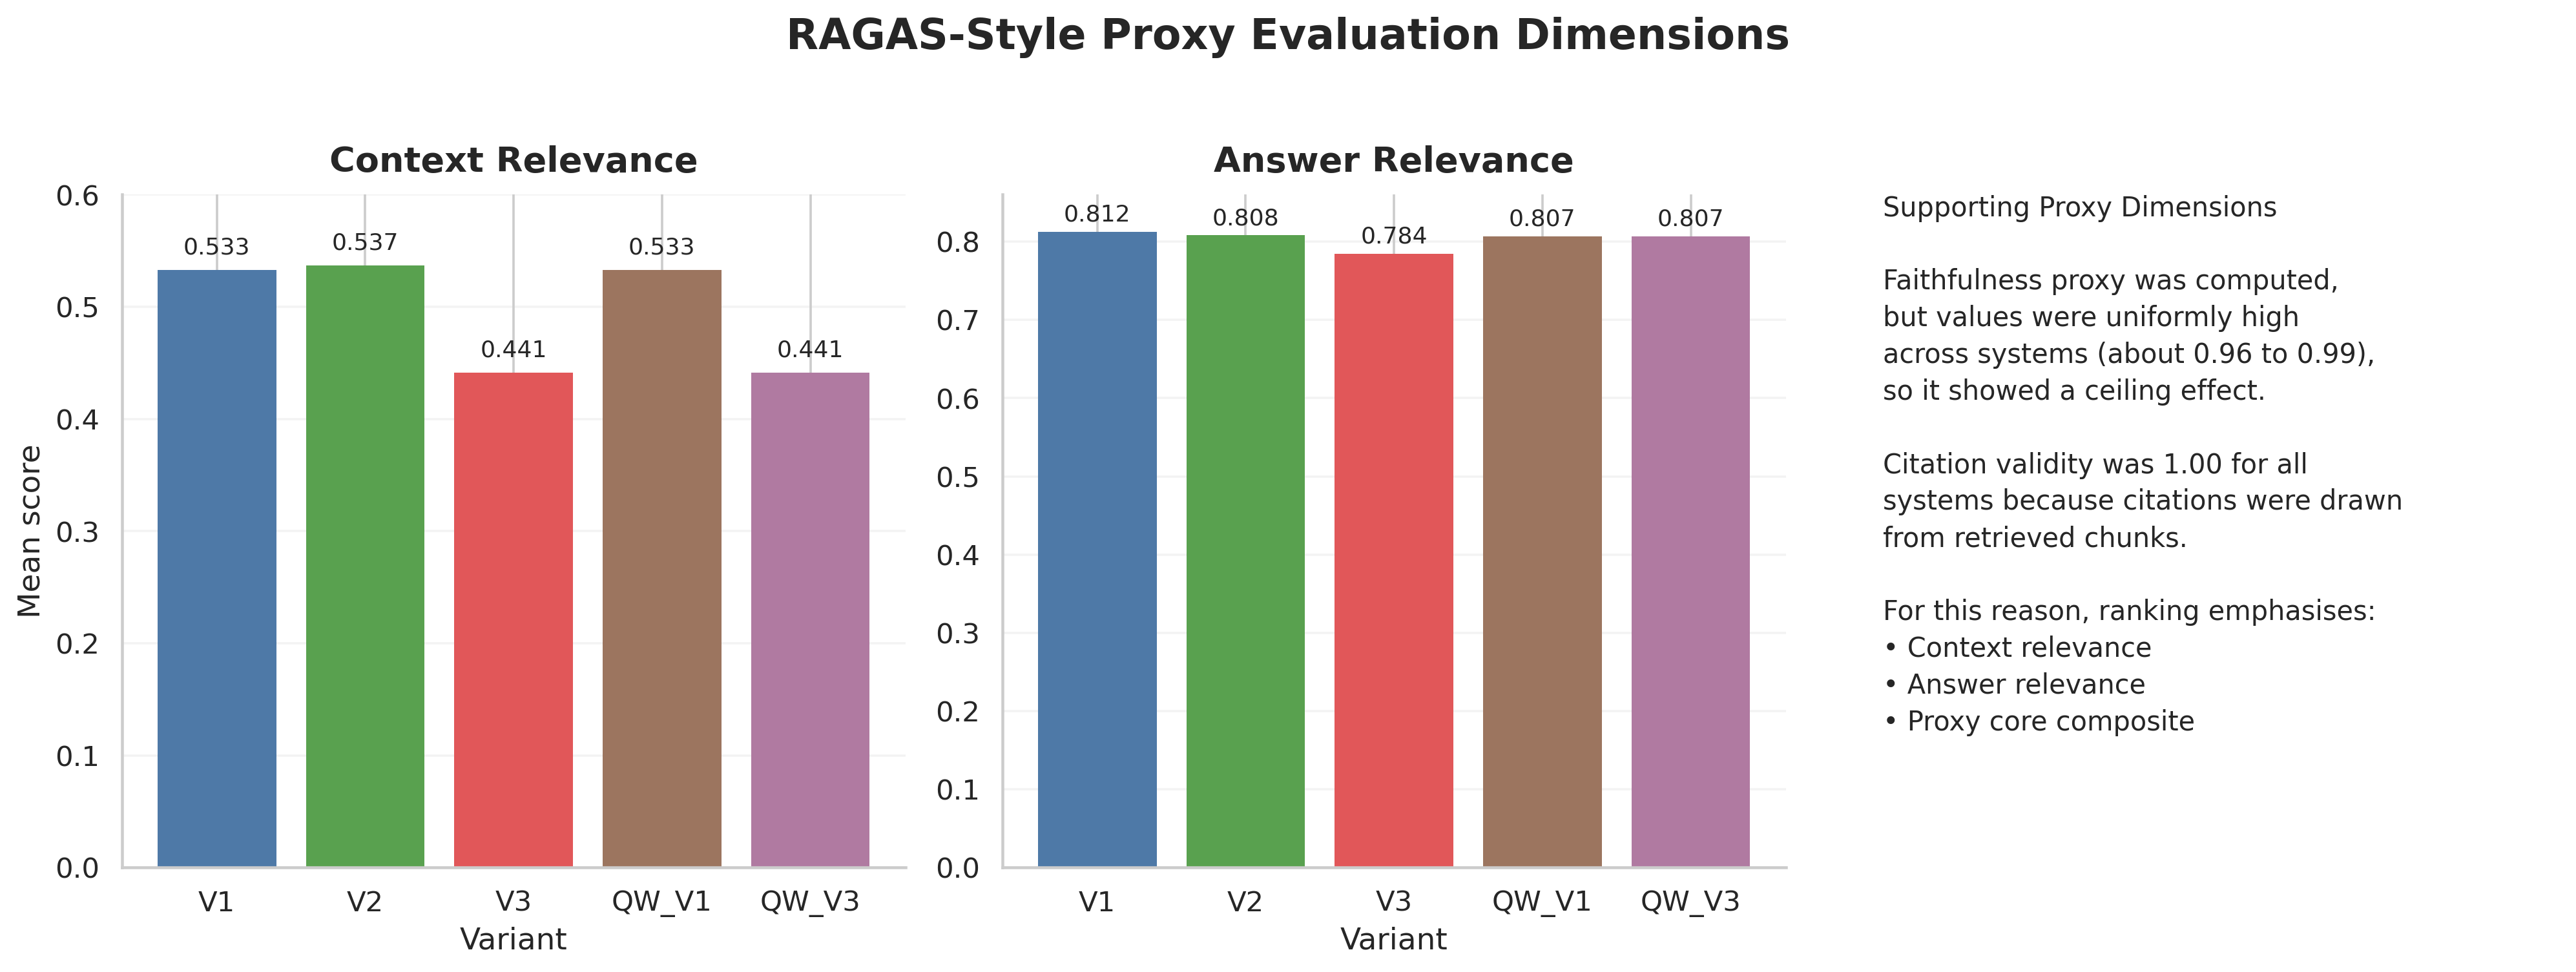

In [19]:
show_saved_figure('ragas_style_proxy_dimensions.png', width=1500)


*Interpretation.* This appendix figure explains why only part of the proxy evaluation becomes a headline result. Context relevance ranges from `0.4414` to `0.5368` and answer relevance from `0.7844` to `0.8123`, so those dimensions still separate systems a little. By contrast, faithfulness stays in a narrow `0.9636` to `0.9850` band and citation validity is `1.00` for every variant. That is why the main report focuses on the core composite instead of giving equal weight to every automated proxy dimension.


### A.2 Manual Risk Summary Table

This appendix table preserves the manual risk breakdown alongside the main manual quality figure. It is also useful for reading the `100/500` manual sample more concretely, because it keeps the trustworthiness summary for all `5` systems in one place: manual quality, unsupported claims, redundancy, and no-failure.



In [15]:
from IPython.display import display, Markdown

manual_summary_table_path = find_first([
    PHASE2_DIR / 'tables' / 'manual_summary_table_clean.csv',
])

summary_table = pd.read_csv(manual_summary_table_path).copy()
summary_md = summary_table.copy()
summary_md['Manual Quality Score'] = summary_md['Manual Quality Score'].map(lambda x: f'{x:.2f}')
summary_md['Unsupported Claim Rate'] = summary_md['Unsupported Claim Rate'].map(lambda x: f'{x:.2%}')
summary_md['Redundancy Rate'] = summary_md['Redundancy Rate'].map(lambda x: f'{x:.2%}')
summary_md['No-Failure Rate'] = summary_md['No-Failure Rate'].map(lambda x: f'{x:.2%}')

display(Markdown(
    "Table X. Manual audit summary across the five evaluated systems. "
    "Quality score is the mean of actionability and usefulness."
))
display(Markdown(summary_md.to_markdown(index=False)))


### 7.6 Manual Risk Summary Table

Variant,Manual Quality Score,Unsupported Claim Rate,Redundancy Rate,No-Failure Rate
V1,3.20,10.00%,0.00%,35.00%
V2,3.75,0.00%,0.00%,60.00%
V3,3.05,15.00%,0.00%,35.00%
QW_V1,3.75,30.00%,10.00%,55.00%
QW_V3,3.60,15.00%,10.00%,45.00%


*Interpretation.* This appendix table makes the sample-based trustworthiness story easier to inspect. The manual review covers `100/500` outputs (`20%`), with `20` cases per system. The clearest contrast is between `V2` and `QW_V1`: both reach `3.75` manual quality, but `V2` stays at `0%` unsupported claims and `60%` no-failure, while `QW_V1` rises to `30%` unsupported claims and `55%` no-failure. `V1` and `V3` both sit at `35%` no-failure, which is why they do not survive the final trustworthiness comparison even when some automated scores look competitive.


### A.3 References

[1] Nikunj Kanataria, Parth Goel, Kunj Pareshbhai Patel, Krishna Patel, Hetul Niteshbhai Patel, and Dweepna Garg, *RAG-Enhanced Large Language Model for Intelligent Assistance from Web-Scraped Data*, Proceedings of the 9th International Conference on Communication and Electronics Systems (ICCES), 2024.

[2] Shahul Es, Jithin James, Luis Espinosa-Anke, and Steven Schockaert, *RAGAS: Automated Evaluation of Retrieval Augmented Generation*, Proceedings of the 18th Conference of the European Chapter of the Association for Computational Linguistics: System Demonstrations, 2024, pp. 150-158.

[3] Chengshuai Zhao, Riccardo De Maria, Tharindu Kumarage, Kumar Satvik Chaudhary, Garima Agrawal, Yiwen Li, Jongchan Park, Yuli Deng, Ying-Chih Chen, and Huan Liu, *CyberBOT: Towards Reliable Cybersecurity Education via Ontology-Grounded Retrieval Augmented Generation*, arXiv:2504.00389v2, 2025.

[4] Francesco Blefari, Cristian Cosentino, Francesco Aurelio Pironti, Angelo Furfaro, and Fabrizio Marozzo, *CyberRAG: An Agentic RAG Cyber Attack Classification and Reporting Tool*, arXiv:2507.02424v2, 2025.




### AI Use Statement

For this assignment, I used AI-assisted tools, specifically GitHub Copilot and/or ChatGPT, to support code-completion tasks such as writing helper functions, debugging pipeline code, and generating boilerplate structures. I critically reviewed, tested, and evaluated all AI-assisted code outputs to make sure they were correct and suitable for the assignment objectives. I take full responsibility for understanding the submitted work and for being able to explain all code included in this notebook.
